## Notebook Implementation Overview: `MASTER_FULL_SEASON_NEW_FEATURES`

This notebook is the full-season-ready copy of `MASTER_TEST_NEW_FEATURES.ipynb`. The pressing detection, feature engineering, modelling, validation, and reporting logic is intended to stay the same; the operational change is that the notebook runs the full 192-match season with memory-safe one-match-at-a-time processing and writes generated artifacts into a full-season output area.

### 1. Setup and Data Selection

**What it does:** Imports the core libraries, selects the active raw-data root, and separates generated full-season artifacts from the raw match folders.

**Method:** The notebook defines a local debug-data root, a full-season raw-data root, and `ARTIFACT_ROOT` for generated parquet/CSV/JSON/PNG outputs. `resolve_data_root()` validates the selected raw-data path before the rest of the pipeline runs.

**Value:** Keeps the full-season run reproducible while avoiding filename collisions with the 10-match/test notebook outputs.

### 2. Match Discovery and Data Quality Audit

**What it does:** Finds tracking-ready match folders and audits required data files.

**Method:** The notebook checks each match folder for F24 event details, F73 possessions, SRML match results, SecondSpectrum tracking data, and SecondSpectrum metadata. It reports missing files and duplicate file candidates.

**Value:** Prevents silent data-quality issues before feature engineering or modelling begins.

### 3. Tracking and Event Loading

**What it does:** Loads SecondSpectrum tracking through Kloppy and parses Opta/SRML files.

**Method:** `load_tracking_kloppy()` reads tracking data. Custom parsers `parse_f24()`, `parse_f73()`, and `parse_srml()` extract event, possession, lineup, and match metadata. `kloppy_tracking_to_v2()` converts Kloppy output to the internal frame format expected by the pressing detector.

**Value:** Produces the same standardized match-store structure used by the test notebook; in full-season mode it is built one match at a time and released after checkpointing.

### 4. Time, Coordinate, and Attack-Direction Alignment

**What it does:** Aligns tracking frames and Opta events in time and space.

**Method:** `add_gameclock_opta()` converts Opta minute/second values into seconds within period. `convert_opta_coords_to_meters()` maps Opta coordinates into meters. `build_frame_index()` and `find_nearest_frame()` support event-to-frame matching. `detect_attack_direction()` infers which way the home team attacks in each period.

**Value:** Enables valid causal feature windows around press start and prevents timing/coordinate errors.

### 5. Pressing Detection

**What it does:** Converts tracking frames into pressing episodes.

**Method:** The detector works in three stages. `detect_pressing_frames()` identifies player-frame pressing actions using movement speed, angle toward the ball, distance to ball, closing speed, live-ball state, and ball height. `group_pressing_runs()` groups consecutive pressing frames by player. `cluster_runs_into_episodes()` merges nearby same-team runs into episode-level rows.

**Value:** Turns raw tracking data into the main analytical unit: one row per pressing episode.

### 6. Pressing Outcome Labelling

**What it does:** Labels whether each detected pressing episode succeeded.

**Method:** `label_pressing_episode_outcomes()` uses F73 possession data and F24 events after the press. It detects regains, sustained possession, chance creation, forced clearances/long balls, and out-of-bounds outcomes. `add_press_success_targets()` creates the binary target `press_success_any` and weighted target `press_value_score`.

**Value:** Gives both a simple success/failure label and a richer value label for regression modelling.

### 7. Advanced Causal Feature Engineering

**What it does:** Builds tactical features around press start.

**Method:** The notebook computes features in four windows: `pre_2s`, `pre_1s`, `start`, and `early_1s`. `compute_causal_snapshot_features()` calculates frame-level features such as ball location, ball speed, nearest presser distance, pressing intensity, team compactness, opponent shape, local overload, passing-lane occlusion, trap intensity, and escape difficulty. `summarize_causal_window()` aggregates these as mean, max, and standard deviation. `build_advanced_press_features()` creates the final episode-level feature table.

**Value:** Produces leakage-safe tactical predictors while keeping labels separate from model features.

### 8. Feature Cleaning and Leakage Control

**What it does:** Builds clean model feature sets.

**Method:** The notebook defines `LABEL_COLUMNS`, `IDENTIFIER_COLUMNS`, and `LEAKAGE_COLUMN_PATTERNS`. It excludes labels, identifiers, future/post-event variables, mostly missing columns, constant columns, and single-frame artefacts.

**Value:** Protects model validity by preventing target leakage and unstable features from entering the model.

### 9. Categorical Feature Layer

**What it does:** Creates football-readable categorical versions of numeric features.

**Method:** Quantile bins are created with `pd.qcut`, while rule-based categories classify pitch zones, sideline trap zones, pressure tiers, and local overload states.

**Value:** Helps translate numeric model features into tactical language suitable for thesis interpretation.

### 10. Advanced Pipeline Export

**What it does:** Runs the full detection, labelling, and feature-engineering pipeline and writes artifacts.

**Method:** The pipeline detects frames, runs, and episodes for each loaded match; labels outcomes; computes advanced features; builds categorical features; and writes parquet/JSON outputs.

**Key outputs:**

- `full_season_press_features_advanced_causal.parquet`
- `full_season_press_features_advanced_categorical.parquet`
- `full_season_press_labels.parquet`
- `full_season_press_features_advanced_metadata.json`

**Value:** Creates reproducible full-season checkpoints for modelling and thesis reporting without mixing them with test-run artifacts.

### 11. Settled High-Press Thesis Scope

**What it does:** Filters the broad pressing dataset to the primary thesis population: settled high pressing.

**Method:** The notebook excludes counterpress candidates when the previous event was by the pressing team within 5 seconds. It also excludes recent ball-out restart contexts using verified Opta type IDs `5 = out` and `6 = corner.awarded`. High pressing is defined by `pressing_progress_to_opponent_goal >= 0.60`.

**Key outputs:**

- `full_season_press_features_settled_context.parquet`
- `full_season_press_features_settled_high_press.parquet`
- `full_season_press_labels_settled_high_press.parquet`
- `full_season_press_settled_high_press_metadata.json`

**Value:** Aligns the implementation with the thesis scope: settled high pressing is the main analysis; counterpressing is documented as future work.

### 12. Model-Ready Feature Manifest

**What it does:** Creates the active model dataset and feature manifest.

**Method:** The notebook builds two feature views: `start_only` and `early_1s`. The feature manifest records row counts, match counts, clean feature lists, dropped features, and modelling rules.

**Value:** Makes the modelling feature space transparent and reproducible.

### 13. Baseline Models

**What it does:** Trains baseline models for binary success and press value.

**Method:** The binary task predicts `press_success_any`; the regression task predicts `press_value_score`. Models include Random Forest, LightGBM, XGBoost, and a train-mean baseline for regression. Splits are grouped by `match_name`, not random rows.

**Value:** Establishes whether pressing success/value is predictable while avoiding match-level leakage.

### 14. SHAP and Permutation Interpretation

**What it does:** Explains model behaviour.

**Method:** XGBoost models are interpreted with permutation importance and SHAP values for both binary and value tasks.

**Key outputs:**

- `full_season_press_model_permutation_importance.parquet`
- `full_season_press_model_shap_importance.parquet`
- `full_season_press_model_interpretation_results.json`

**Value:** Supports thesis claims about which tactical features drive predicted pressing success.

### 15. Start-Only vs Early-1s Grouped Cross-Validation

**What it does:** Tests whether the first second of pressure adds predictive signal beyond the press-start snapshot.

**Method:** The notebook compares `start_only` and `early_1s` feature sets using grouped cross-validation by `match_name`. Metrics include ROC-AUC, PR-AUC, Brier score, F1, MAE, RMSE, and R2.

**Value:** This is a central thesis validation: it tests the value of early pressing dynamics compared with static press-start information.

### 16. Thesis Reporting Outputs

**What it does:** Produces thesis-ready tables and figures.

**Method:** The notebook builds metric tables, delta tables, grouped bar plots, calibration curves, confusion matrices, and feature-importance plots from the modelling outputs.

**Output folder:** `full_season_thesis_reporting_outputs/`

**Value:** Converts modelling results into directly usable thesis materials.

### 17. Robustness Checks

**What it does:** Tests whether results generalize beyond the main grouped cross-validation.

**Method:** Two robustness strategies are implemented: team holdout validation and temporal split validation. Team holdout tests unseen teams. Temporal split trains on earlier matches and tests on later matches.

**Key outputs:**

- `full_season_press_robustness_results.json`
- `full_season_press_robustness_predictions.parquet`
- `full_season_press_robustness_split_metrics.parquet`
- `full_season_press_robustness_aggregate_summary.parquet`
- `full_season_press_robustness_summary.png`

**Value:** Strengthens the empirical argument by testing sensitivity to team identity and match chronology.

### 18. Feature Stability Analysis

**What it does:** Identifies features that remain important across grouped folds.

**Method:** Random Forest models are trained across grouped folds. The notebook tracks mean importance, standard deviation, mean rank, top-fold share, feature family, and a stability score.

**Value:** Helps separate robust tactical signals from fold-specific noise.

### 19. Opta Event Type Lookup

**What it does:** Builds and saves a verified event type lookup.

**Method:** The notebook starts from a verified event mapping and merges it with observed counts from F24/F73 XML files.

**Important verified IDs:**

- `5 = out`
- `6 = corner.awarded`
- `12 = clearance`
- `50 = dispossessed`

**Value:** Documents event taxonomy assumptions and makes outcome/restart definitions auditable.

### 20. Pressing Success/Failure Scatter Plot

**What it does:** Plots individual settled high-press episodes on a football pitch.

**Method:** Uses `mplsoccer.Pitch`, press-start ball location, and `press_success_any`. Coordinates are converted from centered SecondSpectrum coordinates when needed, and x-position is normalized toward the opponent goal.

**Output:** `full_season_pressing_success_failure_pitch.png`

**Value:** Gives an individual-episode spatial view of where successful and failed high presses start.

### 21. Smooth Success/Failure Heatmaps

**What it does:** Produces separate smooth pitch heatmaps for failed and successful settled high presses.

**Method:** The notebook prepares high-resolution 2D density grids, applies Gaussian smoothing, and draws contour heatmaps on a green football pitch with white markings. Plot 1 shows failures. Plot 2 shows successes.

**Key outputs:**

- `full_season_pressing_failure_heatmap_plot_1.png`
- `full_season_pressing_success_heatmap_plot_2.png`
- `full_season_pressing_success_failure_heatmap_summary.csv`

**Value:** Shows spatial density patterns and supports tactical interpretation of where successful high pressing is most concentrated.

### Overall Thesis Contribution

The notebook implements a complete, reproducible pressing-analysis workflow. It detects pressing episodes from tracking data, labels success from event/possession data, builds causal tactical features, narrows the scope to settled high pressing, validates predictive models with grouped splits, explains model behaviour, checks robustness, and produces thesis-ready visual outputs.

The current scope is intentionally focused on settled high pressing. Counterpressing and multi-output modelling are explicitly treated as future work rather than mixed into the primary thesis model.

# Methods and Materials

### 1. Data Sources and Synchronization
The foundation of this study relies on a comprehensive dataset encompassing 193 matches from the Danish Superliga 2024-2025 season. One match was excluded from the final sample due to missing or corrupted tracking files, resulting in 192 fully processed matches. 

The raw data amalgamates two distinct but synchronous streams:
* **Event Data (Opta Sports):** We utilize three core data feeds. The *Match Results (SRML/F7)* feed provides match metadata, starting lineups, and macro-events (goals, cards, substitutions). The *Event Details (F24)* feed captures granular, on-ball actions across 1,963 events per match. Finally, the *Possessions (F73)* feed maps temporal possession sequences and pass chains with over 27,000 sub-events per match. 
* **Tracking Data (Second Spectrum):** Captured at 25 frames per second (fps), the tracking data contains absolute spatial coordinates ($x, y$) over an average of 154,000 frames per match, capturing the position of all 22 players and the ball, alongside positional derivatives such as velocity and distance traveled.

To unify the isolated feeds, the Opta event timestamps were translated into absolute seconds within the match period (`gameClock`), allowing exact synchronization with the Second Spectrum tracking frames. Pitch geometries across both feeds were normalized to absolute dimensions ($104.8 \times 67.96$ meters).

### 2. Pressing Episode Detection and Filtering
Rather than treating a match as a continuous sequence of 25 fps frames, we discretize the game into "pressing episodes." Using positional algorithms, we identify frames where the defensive team exerts coordinated physical pressure on the ball carrier, governed by proximity, closing speed, and attack angle. Consecutive frames where the ball remains live (`live: true` in tracking metadata) are grouped into runs, and simultaneous multi-player runs are aggregated into unified pressing episodes.

To isolate the specific tactical phenomenon of structured defensive work, strict filtering was applied. We excluded *counterpressing* (regaining the ball within 5 seconds of losing it) to eliminate chaotic transition states. The dataset was then constrained to *settled* defensive shapes and explicitly filtered for *high-press* scenarios (actions initiated in the attacking or upper-middle thirds). Following this filtering process, the final sample yielded exactly **6,851 settled high-press episodes**.

### 3. Target Variable
The dependent variable is a binary classification target, defined as `press_success_any`. An episode is labeled as a successful press (1) if it forces a turnover resulting in *sustained possession* for the pressing team or directly leads to a *chance created*. It is labeled as a failed press (0) if the team in possession successfully resolves the pressure—either by completing a progressive pass out of the pressing zone or retaining stable possession.

### 4. Feature Engineering Formulation
Feature extraction was executed in two distinct computational stages. 

**Stage 1: Spatial and Dynamic Derivation**
The initial ingestion and parsing pipeline were executed using the `kloppy` library (as documented in the `MASTER_THESIS_KLOPPY_COLAB.ipynb` pipeline). This phase calculates absolute distances between players, identifies the nearest pressers, calculates convex hulls, and computes raw tactical geometry frame-by-frame. 

**Stage 2: Advanced Window Aggregation**
Because pressing is a temporal event, point-in-time snapshots are insufficient. To construct the final predictive dataset, dynamic metrics were aggregated over specific temporal windows leading up to, and directly following, the initiation of the press (the "early-window"). This generated exactly **474 predictive features** encompassing the following core tactical families:
* **Pressing & Trap Intensity:** Metrics approximating the aggregate physical exertion and spatial restriction imposed on the ball carrier.
* **Compact Pressure & Surface Area:** Calculations of the defending team's convex hull, stretch indices, and team length/width.
* **Player-Level Dynamics:** `dist_nearest_1` to `dist_nearest_3` (distances of the closest pressers), alongside their respective closing speeds.
* **Spatial Context:** Absolute ball coordinates ($x, y$) and boolean checks for proximity to the sideline vs. the central pitch axis.

### 5. Experimental Design and Modeling
To prevent data leakage caused by the chronological and physical continuity of football matches, cross-validation and train/test splits were strictly **grouped by match** (`match_name`). This ensures that temporally adjacent episodes from the same match do not leak from the training set into the test set.

The modeling approach utilizes three tree-based, non-linear machine learning architectures capable of handling complex spatial interactions without strict scaling prerequisites:
1. **Random Forest (RF)**
2. **XGBoost**
3. **LightGBM**

Additionally, a deterministic baseline model was constructed. Inspired by existing tactical frameworks in academic sports literature, we formulated an ablation **"press-intensity threshold model,"** operating under the premise that a successful press can be predicted purely by the density and speed of the defenders closing down the ball carrier.

### 6. Evaluation and Interpretability
Due to the highly imbalanced nature of the target variable (successful high presses represent a minority class), accuracy is an insufficient metric. Model evaluation relies heavily on the **Precision-Recall Area Under Curve (PR-AUC)**, alongside **ROC-AUC**, **F1-score**, and the **Brier Score** for probabilistic calibration. Confusion matrices are utilized to evaluate the trade-off between false positives and false negatives based on customized probability thresholds.

Finally, to bridge the gap between black-box predictions and tactical theory, model interpretability is derived using both global **Permutation Importance** and local **Tree SHAP** (SHapley Additive exPlanations) values. This methodological choice ensures that every prediction can be attributed to specific tactical configurations recognizable to physical behaviors on the pitch.

In [5]:
#!pip3 install Kloppy

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Install & imports
# ══════════════════════════════════════════════════════════════════════════════
# !pip install kloppy pandas numpy scikit-learn lightgbm xgboost matplotlib seaborn shap -q

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree

from kloppy import secondspectrum, opta

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore', category=FutureWarning)

print("Imports ready.")

Imports ready.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2a — Dataset root selector (full-season production run)
# ══════════════════════════════════════════════════════════════════════════════

LOCAL_DATA_ROOT = Path(
    "/Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/"
    "Superliga_2024_2025_selected_TEST_DATA_3MATCHES"
)

FULL_SEASON_DATA_ROOT = Path(
    "/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds"
    # Mounted external-drive folder — the 192 tracking-ready match folders live inside Matchfeeds/
)

USE_FULL_SEASON_DATA = True
EXPECTED_FULL_MATCH_COUNT = 192

# Full-season safety controls. Keep raw input and generated outputs on the external drive by default.
FULL_SEASON_MAX_MATCHES = None        # Set to 2-5 for a dry run; None means all discovered matches.
FULL_SEASON_BATCH_SIZE = 1            # Keep at 1 on memory-constrained machines.
RESUME_FROM_MATCH_OUTPUTS = True
FORCE_REBUILD_MATCH_OUTPUTS = False
ALLOW_PARTIAL_FULL_SEASON = False
WRITE_PRESS_FRAME_RUN_CHECKPOINTS = False
FULL_SEASON_OUTPUT_ROOT = FULL_SEASON_DATA_ROOT / "_generated_pressing_outputs"
FULL_SEASON_LOCAL_OUTPUT_ROOT = LOCAL_DATA_ROOT / "_generated_full_season_outputs"
ARTIFACT_ROOT = FULL_SEASON_OUTPUT_ROOT if USE_FULL_SEASON_DATA else FULL_SEASON_LOCAL_OUTPUT_ROOT
ARTIFACT_PREFIX = "full_season_"


def resolve_data_root(use_full_season: bool = USE_FULL_SEASON_DATA) -> Path:
    """Return the active raw-data root and fail early if the chosen path is missing."""
    candidate = FULL_SEASON_DATA_ROOT if use_full_season else LOCAL_DATA_ROOT
    dataset_label = "full 192-match corpus" if use_full_season else "local calibration subset"

    if not candidate.exists():
        raise FileNotFoundError(
            f"Selected {dataset_label} path does not exist:\n{candidate}\n"
            "Mount/connect the external drive, edit FULL_SEASON_DATA_ROOT, "
            "or set USE_FULL_SEASON_DATA = False for a local debug run."
        )

    print(f"Active dataset: {dataset_label}")
    print(f"DATA_ROOT = {candidate}")
    if use_full_season:
        print(f"Full-season generated outputs: {ARTIFACT_ROOT}")
        print("Memory-safe mode: one match is loaded, processed, saved, and released at a time.")
    else:
        print()
        print("Local debug mode. For the production run:")
        print("  1. Mount/connect the external drive")
        print("  2. Replace FULL_SEASON_DATA_ROOT if needed")
        print("  3. Set USE_FULL_SEASON_DATA = True")
        print("  4. Re-run this cell and the discovery/audit cells")
    return candidate


DATA_ROOT = resolve_data_root()
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

Active dataset: full 192-match corpus
DATA_ROOT = /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds
Full-season generated outputs: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs
Memory-safe mode: one match is loaded, processed, saved, and released at a time.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2b — Discover match folders
# ══════════════════════════════════════════════════════════════════════════════

try:
    all_match_folders = sorted(
        d for d in DATA_ROOT.iterdir()
        if d.is_dir() and not d.name.startswith(".") and not d.name.startswith("_") and d.name != "ZIP USED"
    )
except PermissionError as exc:
    raise PermissionError(
        f"Cannot read DATA_ROOT due to macOS file permissions:\n{DATA_ROOT}\n\n"
        "Open System Settings -> Privacy & Security and grant Visual Studio Code access "
        "to removable volumes under Files and Folders. If that option is not shown, "
        "grant Full Disk Access to Visual Studio Code, restart VS Code, and re-run Cell 2a and Cell 2b. "
        "If you prefer, copy the dataset to a folder under your home directory and point FULL_SEASON_DATA_ROOT there instead."
    ) from exc

match_folders = sorted(
    d for d in all_match_folders
    if any(d.glob("*_SecondSpectrum_Data.*"))
)
missing_tracking_folders = [
    d for d in all_match_folders
    if d not in match_folders
]

print(f"Found {len(match_folders)} tracking-ready match folders in:\n  {DATA_ROOT}\n")
for i, mf in enumerate(match_folders, 1):
    print(f"  {i:>3}. {mf.name}")

if missing_tracking_folders:
    print()
    print("Folders present but excluded from Kloppy loading because tracking files are missing:")
    for mf in missing_tracking_folders:
        print(f"  - {mf.name}")

if USE_FULL_SEASON_DATA:
    print()
    print(
        f"Full-season folder count: {len(all_match_folders)} / {EXPECTED_FULL_MATCH_COUNT} match directories found."
    )
    print(f"Tracking-ready count: {len(match_folders)} / {len(all_match_folders)}.")
    if len(all_match_folders) != EXPECTED_FULL_MATCH_COUNT:
        print("Verify the external-drive root points at the folder containing all match directories.")
    elif missing_tracking_folders:
        print("At least one match folder is present but missing SecondSpectrum tracking data.")
    else:
        print("Full-season check passed: all match directories contain tracking data.")

Found 192 tracking-ready match folders in:
  /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds

    1. 2024-07-19 AGF - FC Midtjylland (2442545)
    2. 2024-07-19 FC Nordsjælland - AaB (2442546)
    3. 2024-07-21 Silkeborg IF - SønderjyskE (2442547)
    4. 2024-07-21 Vejle Boldklub - Randers FC (2442548)
    5. 2024-07-21 Viborg FF - Brøndby IF (2442549)
    6. 2024-07-22 Lyngby Boldklub - F.C. København (2442550)
    7. 2024-07-26 SønderjyskE - Lyngby Boldklub (2442551)
    8. 2024-07-27 FC Nordsjælland - FC Midtjylland (2442552)
    9. 2024-07-28 AaB - Silkeborg IF (2442554)
   10. 2024-07-28 F.C. København - AGF (2442555)
   11. 2024-07-28 Randers FC - Viborg FF (2442553)
   12. 2024-07-29 Brøndby IF - Vejle Boldklub (2442556)
   13. 2024-08-02 AGF - SønderjyskE (2442558)
   14. 2024-08-03 FC Midtjylland - AaB (2442557)
   15. 2024-08-04 F.C. København - Randers FC (2442560)
   16. 2024-08-04 Lyngby Boldklub - Brøndby IF (2442561)
   17. 2024-08-04 Silkeborg IF - Viborg 

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2c — Data Inventory & Quality Audit
# ══════════════════════════════════════════════════════════════════════════════
# Verifies that every discovered match folder contains all required files for
# the downstream Kloppy tracking loader and the F24/F73/SRML event parsers.
# Flags missing files AND duplicate matches (the loaders use [0] and assume
# exactly one file per pattern).
# ──────────────────────────────────────────────────────────────────────────────

REQUIRED_PATTERNS = {
    "F24 Event Details":         "f24-*-eventdetails.xml",
    "F73 Possessions":           "f73-*-possessions.xml",
    "SRML Match Results":        "srml-*-matchresults.xml",
    "SS Tracking (json/jsonl)":  "*_SecondSpectrum_Data.json*",   # .json or .jsonl
    "SS Metadata XML":           "*_SecondSpectrum_Metadata.xml",
    "SS Metadata JSON":          "*_SecondSpectrum_Metadata.json",
}

MISSING_TAG   = "❌ MISSING"
DUPLICATE_TAG = "⚠️ DUPLICATE"

audit_folders = all_match_folders if "all_match_folders" in globals() else match_folders

qa_rows = []
for mf in audit_folders:
    row = {"match_folder": mf.name}
    for label, pattern in REQUIRED_PATTERNS.items():
        hits = list(mf.glob(pattern))
        # For tracking, restrict to .json / .jsonl (exclude .xml, .download, etc.)
        if "Tracking" in label:
            hits = [h for h in hits if h.suffix in (".json", ".jsonl")]

        if not hits:
            row[label] = MISSING_TAG
        elif len(hits) > 1:
            row[label] = f"{DUPLICATE_TAG} ({len(hits)}): {hits[0].name}"
        else:
            row[label] = hits[0].name
    qa_rows.append(row)

qa_df = pd.DataFrame(qa_rows)
if qa_df.empty:
    raise ValueError("No match folders were available for the audit. Re-run Cell 2a and Cell 2b.")

qa_df = qa_df.set_index("match_folder")
print("═══ FILE INVENTORY ═══\n")
print(qa_df.to_string())

# ── Summary ──
missing_mask   = qa_df.apply(lambda c: c.str.contains(MISSING_TAG, regex=False)).any()
duplicate_mask = qa_df.apply(lambda c: c.str.contains(DUPLICATE_TAG, regex=False)).any()

print()
print(f"Audited folders: {len(audit_folders)}")
print(f"Tracking-ready folders: {len(match_folders)}")
if "missing_tracking_folders" in globals() and missing_tracking_folders:
    print(f"Folders missing tracking data: {len(missing_tracking_folders)}")

if missing_mask.any():
    print("⚠️  Missing files detected in columns:")
    for col in missing_mask[missing_mask].index:
        bad = qa_df.index[qa_df[col].str.contains(MISSING_TAG, regex=False)].tolist()
        print(f"   - {col}: {bad}")
if duplicate_mask.any():
    print("⚠️  Duplicate files detected in columns (loader assumes exactly one):")
    for col in duplicate_mask[duplicate_mask].index:
        bad = qa_df.index[qa_df[col].str.contains(DUPLICATE_TAG, regex=False)].tolist()
        print(f"   - {col}: {bad}")
if not missing_mask.any() and not duplicate_mask.any():
    print("✅ All required files present (and unique) in every audited match folder.")

═══ FILE INVENTORY ═══

                                                                                     F24 Event Details                       F73 Possessions                       SRML Match Results                                                         SS Tracking (json/jsonl)                                                                    SS Metadata XML                                                                    SS Metadata JSON
match_folder                                                                                                                                                                                                                                                                                                                                                                                                                                 
2024-07-19 AGF - FC Midtjylland (2442545)                        f24-100-2024-2442545-eventdetails.xml  f73-100-2024

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Kloppy: load SecondSpectrum tracking data
# ══════════════════════════════════════════════════════════════════════════════

def load_tracking_kloppy(match_dir: Path) -> pd.DataFrame:
    """
    Load SecondSpectrum tracking via Kloppy → DataFrame.
    Returns the same column structure the V2 pressing pipeline expects.
    """
    # Find files
    data_files = list(match_dir.glob("*_SecondSpectrum_Data.json*"))
    data_file = [f for f in data_files if f.suffix in ('.json', '.jsonl')][0]
    meta_xml = list(match_dir.glob("*_SecondSpectrum_Metadata.xml"))[0]
    meta_json = list(match_dir.glob("*_SecondSpectrum_Metadata.json"))[0]

    # Kloppy loads tracking into its standardised model
    dataset = secondspectrum.load(
        raw_data=str(data_file),
        meta_data=str(meta_xml),
        additional_meta_data=str(meta_json),
        coordinates="secondspectrum",   # keep native centered coords
    )

    # Export to DataFrame — one row per frame
    df = dataset.to_df(
        additional_columns={
            "period_id": lambda frame: frame.period.id if frame.period else None,
            "timestamp_s": lambda frame: frame.timestamp.total_seconds() if frame.timestamp else None,
        }
    )

    return dataset, df


# ── Test on ALL matches ──
#for i, mf in enumerate(match_folders, 1):
#    test_ds, test_df = load_tracking_kloppy(mf)
#    teams = [t.name for t in test_ds.metadata.teams]
#    fps = test_ds.metadata.frame_rate
#    periods = [p.id for p in test_ds.metadata.periods]
#    print(f"{i:>2}. {mf.name}")
#    print(f"    Teams: {teams}  |  Frames: {len(test_df):,}  |  FPS: {fps}  |  Periods: {periods}")
#    del test_ds, test_df  # free memory between matches

print(f"\n✅ All {len(match_folders)} matches loaded successfully via Kloppy.")


✅ All 192 matches loaded successfully via Kloppy.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Kloppy: load Opta F24 events + F73 possessions
# ══════════════════════════════════════════════════════════════════════════════
#
# Kloppy's opta.load() requires F7 (lineup XML) which we don't have.
# Our SRML file serves the same role. We load F24/F73 with minimal custom
# parsing (same approach as original notebook, but lighter).
#
# Kloppy's StatsPerform provider CAN handle F24+F7 natively, but since
# our data bundle uses SRML instead of F7, we keep thin custom parsers
# for events. The big win from Kloppy is the tracking data.
# ──────────────────────────────────────────────────────────────────────────────

def parse_f24(match_dir: Path) -> pd.DataFrame:
    """Parse Opta F24 event-details XML → DataFrame."""
    f24_file = list(match_dir.glob("f24-*.xml"))[0]
    tree = etree.parse(str(f24_file))
    game = tree.getroot().find(".//Game")

    match_id = game.get("id")
    home_team = game.get("home_team_id")
    away_team = game.get("away_team_id")

    rows = []
    for ev in game.findall(".//Event"):
        row = dict(ev.attrib)
        row["match_id"]  = match_id
        row["home_team"] = home_team
        row["away_team"] = away_team
        rows.append(row)

    df = pd.DataFrame(rows)
    for col in ["type_id", "period_id", "min", "sec", "outcome",
                "x", "y", "team_id", "player_id"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def parse_f73(match_dir: Path) -> pd.DataFrame:
    """Parse Opta F73 possessions XML → DataFrame with possession_id."""
    f73_file = list(match_dir.glob("f73-*.xml"))[0]
    tree = etree.parse(str(f73_file))
    game = tree.getroot().find(".//Game")

    match_id = game.get("id")
    home_team = game.get("home_team_id")
    away_team = game.get("away_team_id")

    rows = []
    for ev in game.findall(".//Event"):
        row = dict(ev.attrib)
        row["match_id"]  = match_id
        row["home_team"] = home_team
        row["away_team"] = away_team

        # Extract qualifiers
        for q in ev.findall("Q"):
            qid = q.get("qualifier_id")
            val = q.get("value", "1")
            # Named qualifiers
            known = {
                "210": "end_x", "211": "end_y",
                "5":   "pass_direction",
                "212": "pass_length", "213": "pass_angle",
                "72":  "body_part", "214": "pass_speed",
                "170": "error", "210": "end_x",
            }
            col_name = known.get(qid, f"q_{qid}")
            row[col_name] = val

        rows.append(row)

    df = pd.DataFrame(rows)
    for col in ["type_id", "period_id", "min", "sec", "outcome",
                "x", "y", "team_id", "player_id",
                "sequence_id", "possession_id",
                "end_x", "end_y"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def parse_srml(match_dir: Path) -> dict:
    """Parse SRML match-results XML → dict with teams, lineups, scores."""
    srml_file = list(match_dir.glob("srml-*.xml"))[0]
    tree = etree.parse(str(srml_file))
    root = tree.getroot()
    ns = {"s": root.nsmap.get(None, "")}

    match_info = root.find(".//s:MatchData", ns) or root.find(".//MatchData")
    result = {"match_date": "", "attendance": "", "teams": []}

    if match_info is not None:
        md = match_info.find("s:MatchInfo", ns) or match_info.find("MatchInfo")
        if md is not None:
            result["match_date"] = md.get("Date", "")
            result["attendance"] = md.get("Attendance", "")

    for team_el in root.findall(".//s:TeamData", ns) or root.findall(".//TeamData"):
        team = {
            "team_ref": team_el.get("TeamRef", ""),
            "side":     team_el.get("Side", ""),
            "score":    int(team_el.get("Score", 0)),
            "lineup":   [],
        }

        for player_el in team_el.findall(".//s:MatchPlayer", ns) or team_el.findall(".//MatchPlayer"):
            team["lineup"].append({
                "player_ref":   player_el.get("PlayerRef", ""),
                "position":     player_el.get("Position", ""),
                "status":       player_el.get("Status", ""),
                "shirt_number": player_el.get("ShirtNumber", ""),
            })

        result["teams"].append(team)

    return result


# ── Test on ALL matches ──
for i, mf in enumerate(match_folders, 1):
    f24 = parse_f24(mf)
    f73 = parse_f73(mf)
    srml = parse_srml(mf)
    home = [t for t in srml["teams"] if t["side"] == "Home"][0]
    away = [t for t in srml["teams"] if t["side"] == "Away"][0]
    print(f"{i:>2}. {mf.name}")
    print(f"    F24: {len(f24)} events  |  F73: {len(f73)} events, {f73['possession_id'].nunique()} poss  |  Score: {home['score']}–{away['score']}")

print(f"\n✅ All {len(match_folders)} matches parsed successfully.")

 1. 2024-07-19 AGF - FC Midtjylland (2442545)
    F24: 1639 events  |  F73: 1639 events, 190 poss  |  Score: 1–1
 2. 2024-07-19 FC Nordsjælland - AaB (2442546)
    F24: 1963 events  |  F73: 1963 events, 174 poss  |  Score: 3–0
 3. 2024-07-21 Silkeborg IF - SønderjyskE (2442547)
    F24: 1793 events  |  F73: 1793 events, 174 poss  |  Score: 1–0
 4. 2024-07-21 Vejle Boldklub - Randers FC (2442548)
    F24: 1662 events  |  F73: 1662 events, 182 poss  |  Score: 2–3
 5. 2024-07-21 Viborg FF - Brøndby IF (2442549)
    F24: 1876 events  |  F73: 1876 events, 160 poss  |  Score: 3–3
 6. 2024-07-22 Lyngby Boldklub - F.C. København (2442550)
    F24: 1751 events  |  F73: 1751 events, 172 poss  |  Score: 0–2
 7. 2024-07-26 SønderjyskE - Lyngby Boldklub (2442551)
    F24: 1696 events  |  F73: 1696 events, 224 poss  |  Score: 1–1
 8. 2024-07-27 FC Nordsjælland - FC Midtjylland (2442552)
    F24: 1796 events  |  F73: 1796 events, 146 poss  |  Score: 2–2
 9. 2024-07-28 AaB - Silkeborg IF (2442554)
   

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SRML Explorer — inspect a single match's SRML file
# ══════════════════════════════════════════════════════════════════════════════

#MATCH_FOLDER = "2024-07-19 AGF - FCM"  # ← change to any folder name

#srml_file = list((DATA_ROOT / MATCH_FOLDER).glob("srml-*.xml"))[0]
#tree = etree.parse(str(srml_file))
#root = tree.getroot()

# Pretty-print the full XML
#from lxml import etree as ET
#print(f"Match folder: {MATCH_FOLDER}")
#print(f"File: {srml_file.name}\n")
#print(ET.tostring(root, pretty_print=True, encoding="unicode"))

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Bridge: convert Kloppy tracking → V2 pipeline format
# ══════════════════════════════════════════════════════════════════════════════
#
# The V2 pressing pipeline (detect_pressing_frames, etc.) expects a tracking
# DataFrame with specific columns. This cell converts Kloppy's output into
# that exact format.
#

def _parse_lasttouch_from_jsonl(match_dir: Path) -> dict:
    """
    Parse raw SecondSpectrum JSONL to extract per-frame lastTouch.
    Returns dict: (period, gameClock) → 'home' or 'away'.
    Kloppy doesn't expose this field, but we need it for possession-aware pressing.
    """
    import json
    data_files = list(match_dir.glob("*_SecondSpectrum_Data.json*"))
    data_file = [f for f in data_files if f.suffix in ('.json', '.jsonl')][0]

    lt_map = {}
    with open(data_file, 'r') as fh:
        for line in fh:
            frame = json.loads(line)
            period = frame.get("period", 1)
            gc = round(frame.get("gameClock", 0.0), 3)
            lt = frame.get("lastTouch", None)
            lt_map[(period, gc)] = lt
    return lt_map


def kloppy_tracking_to_v2(dataset, kloppy_df: pd.DataFrame,
                          match_dir: Path = None) -> pd.DataFrame:
    """
    Convert Kloppy SecondSpectrum DataFrame → V2 pipeline tracking DataFrame.

    V2 expects per row:
        period, frameIdx, gameClock, wallClock, live, lastTouch,
        ball_x, ball_y, ball_z, ball_spd,
        home_players (list of dicts with playerId, xyz, speed),
        away_players (list of dicts)

    If match_dir is provided, parses raw JSONL to populate lastTouch
    (Kloppy doesn't expose this SecondSpectrum field).
    """
    # Parse lastTouch from raw JSONL if available
    lt_map = _parse_lasttouch_from_jsonl(match_dir) if match_dir else {}

    home_team = dataset.metadata.teams[0]
    away_team = dataset.metadata.teams[1]

    # Identify player columns from Kloppy's wide-format DataFrame
    home_player_ids = [p.player_id for p in home_team.players]
    away_player_ids = [p.player_id for p in away_team.players]

    rows = []
    for frame_record in dataset.records:
        period = frame_record.period.id if frame_record.period else 1
        gc = frame_record.timestamp.total_seconds() if frame_record.timestamp else 0.0

        # Ball
        if frame_record.ball_coordinates:
            bx = frame_record.ball_coordinates.x
            by = frame_record.ball_coordinates.y
            bz = getattr(frame_record.ball_coordinates, 'z', 0.0) or 0.0
        else:
            bx, by, bz = np.nan, np.nan, np.nan

        ball_spd = getattr(frame_record.ball_coordinates, 'speed', 0.0) if frame_record.ball_coordinates else 0.0

        # Home players
        home_players = []
        for player, coords in frame_record.players_coordinates.items():
            if player.team == home_team and coords:
                player_data = frame_record.players_data.get(player)
                spd = getattr(coords, 'speed', None) or getattr(player_data, 'speed', 0.0) or 0.0
                home_players.append({
                    "playerId": player.player_id,
                    "xyz":      [coords.x, coords.y, 0.0],
                    "speed":    spd,
                })

        # Away players
        away_players = []
        for player, coords in frame_record.players_coordinates.items():
            if player.team == away_team and coords:
                player_data = frame_record.players_data.get(player)
                spd = getattr(coords, 'speed', None) or getattr(player_data, 'speed', 0.0) or 0.0
                away_players.append({
                    "playerId": player.player_id,
                    "xyz":      [coords.x, coords.y, 0.0],
                    "speed":    spd,
                })

        rows.append({
            "period":       int(period),
            "frameIdx":     frame_record.frame_id if hasattr(frame_record, 'frame_id') else 0,
            "gameClock":    gc,
            "wallClock":    0,  # not critical for pressing pipeline
            "live":         frame_record.ball_state.value if frame_record.ball_state else True,
            "lastTouch":    lt_map.get((int(period), round(gc, 3)), None),
            "ball_x":       bx,
            "ball_y":       by,
            "ball_z":       bz,
            "ball_spd":     ball_spd or 0.0,
            "home_players": home_players,
            "away_players": away_players,
        })

    return pd.DataFrame(rows)


# ── Test on matches (Skipping rest if running full season) ──
for i, mf in enumerate(match_folders, 1):
    test_ds, test_df = load_tracking_kloppy(mf)
    test_v2 = kloppy_tracking_to_v2(test_ds, test_df, match_dir=mf)
    lt_filled = test_v2['lastTouch'].notna().sum()
    print(f"{i:>2}. {mf.name}")
    print(f"    V2 shape: {test_v2.shape}  |  "
          f"Home: {len(test_v2.iloc[0]['home_players'])} players  |  "
          f"Away: {len(test_v2.iloc[0]['away_players'])} players  |  "
          f"lastTouch: {lt_filled}/{len(test_v2)} filled")
    del test_ds, test_df, test_v2
    
    if USE_FULL_SEASON_DATA:
        print("\n⏳ Skipping the rest of the test loop to save time (Full season mode active).")
        break

print(f"\n✅ Tracking data test complete.")

 1. 2024-07-19 AGF - FC Midtjylland (2442545)
    V2 shape: (154008, 12)  |  Home: 11 players  |  Away: 11 players  |  lastTouch: 154008/154008 filled

⏳ Skipping the rest of the test loop to save time (Full season mode active).

✅ Tracking data test complete.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Build metadata dict (for pipeline compatibility)
# ══════════════════════════════════════════════════════════════════════════════

def build_meta_from_kloppy(dataset, match_dir: Path) -> dict:
    """
    Build metadata dict matching the V2 pipeline's expected structure
    from a Kloppy TrackingDataset.
    """
    home_team = dataset.metadata.teams[0]
    away_team = dataset.metadata.teams[1]

    pitch = dataset.metadata.pitch_dimensions
    pitch_length = pitch.x_dim.max - pitch.x_dim.min if pitch else 105.0
    pitch_width  = pitch.y_dim.max - pitch.y_dim.min if pitch else 68.0

    # Build player_lookup (optaId → info)
    player_lookup = {}
    for p in home_team.players:
        pos = getattr(p, 'starting_position', None) or getattr(p, 'position', None)
        player_lookup[p.player_id] = {
            "name":     p.name or p.player_id,
            "number":   getattr(p, 'jersey_no', None),
            "position": str(pos) if pos else "",
            "ssiId":    p.player_id,
            "optaId":   p.player_id,
            "side":     "home",
        }
    for p in away_team.players:
        pos = getattr(p, 'starting_position', None) or getattr(p, 'position', None)
        player_lookup[p.player_id] = {
            "name":     p.name or p.player_id,
            "number":   getattr(p, 'jersey_no', None),
            "position": str(pos) if pos else "",
            "ssiId":    p.player_id,
            "optaId":   p.player_id,
            "side":     "away",
        }

    meta = {
        "pitchLength":    pitch_length,
        "pitchWidth":     pitch_width,
        "fps":            dataset.metadata.frame_rate or 25,
        "player_lookup":  player_lookup,
        "homePlayers":    [{"optaId": p.player_id} for p in home_team.players],
        "awayPlayers":    [{"optaId": p.player_id} for p in away_team.players],
    }
    return meta


# ── Test on matches (Skipping rest if running full season) ──
for i, mf in enumerate(match_folders, 1):
    test_ds, test_df = load_tracking_kloppy(mf)
    test_meta = build_meta_from_kloppy(test_ds, mf)
    print(f"{i:>2}. {mf.name}")
    print(f"    Pitch: {test_meta['pitchLength']}m × {test_meta['pitchWidth']}m  |  "
          f"FPS: {test_meta['fps']}  |  "
          f"Players: {len(test_meta['player_lookup'])}")
    del test_ds, test_df, test_meta
    
    if USE_FULL_SEASON_DATA:
        print("\n⏳ Skipping the rest of the test loop to save time (Full season mode active).")
        break

print(f"\n✅ Tracking data metadata test complete.")

 1. 2024-07-19 AGF - FC Midtjylland (2442545)
    Pitch: 104.48m × 67.8m  |  FPS: 25  |  Players: 40

⏳ Skipping the rest of the test loop to save time (Full season mode active).

✅ Tracking data metadata test complete.


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Utility functions: gameClock, frame index, attack direction
# ══════════════════════════════════════════════════════════════════════════════

def add_gameclock_opta(df: pd.DataFrame) -> pd.DataFrame:
    """Add gameClock (seconds since period start) to Opta events."""
    df = df.copy()
    period_offset = df["period_id"].map({1: 0, 2: 45, 16: 0}).fillna(0).astype(int)
    df["gameClock"] = (df["min"] - period_offset) * 60 + df["sec"]
    df.loc[df["period_id"] == 16, "gameClock"] = np.nan
    return df


def convert_opta_coords_to_meters(df, pitch_length, pitch_width):
    """Convert Opta percentage coords to meters."""
    df = df.copy()
    if "x" in df.columns:
        df["x_m"] = df["x"] / 100.0 * pitch_length
    if "y" in df.columns:
        df["y_m"] = df["y"] / 100.0 * pitch_width
    if "end_x" in df.columns:
        df["end_x_m"] = df["end_x"] / 100.0 * pitch_length
    if "end_y" in df.columns:
        df["end_y_m"] = df["end_y"] / 100.0 * pitch_width
    return df


def build_frame_index(tracking_df: pd.DataFrame) -> dict:
    """Per-period sorted index for fast nearest-frame lookups."""
    index = {}
    for period in tracking_df["period"].unique():
        subset = tracking_df[tracking_df["period"] == period].sort_values("gameClock").reset_index(drop=True)
        gc_arr = subset["gameClock"].values
        index[period] = (gc_arr, subset)
    return index


def find_nearest_frame(frame_index: dict, period: int, gameClock: float, max_dt: float = 0.5):
    """Find tracking frame nearest to given gameClock."""
    if period not in frame_index:
        return None
    gc_arr, subset = frame_index[period]
    idx = np.searchsorted(gc_arr, gameClock)
    best_idx, best_dt = None, float("inf")
    for candidate in [max(0, idx - 1), min(len(gc_arr) - 1, idx)]:
        dt = abs(gc_arr[candidate] - gameClock)
        if dt < best_dt:
            best_dt = dt
            best_idx = candidate
    if best_dt > max_dt:
        return None
    return subset.iloc[best_idx]


def detect_attack_direction(store: dict, match_name: str) -> dict:
    """
    Determine home-team attacking direction per period.
    Returns {period: +1 or -1}.
    """
    f24 = store["f24"]
    frame_index = store["frame_index"]

    home_team_id = None
    for t in store["srml"]["teams"]:
        if t["side"] == "Home":
            home_team_id = t["team_ref"].lstrip("t")
            break
    if home_team_id is None:
        home_team_id = str(f24.iloc[0].get("team_id"))

    attack_dir = {}
    for period in [1, 2]:
        mask = (
            (f24["period_id"] == period) &
            (f24["x"] > 70) &
            (f24["team_id"].astype(str) == str(home_team_id)) &
            (f24["gameClock"].notna())
        )
        events = f24[mask]
        if events.empty:
            events = f24[(f24["period_id"] == period) & (f24["x"] > 70) & (f24["gameClock"].notna())]

        ball_xs = []
        for _, ev in events.head(20).iterrows():
            frame = find_nearest_frame(frame_index, ev["period_id"], ev["gameClock"], max_dt=1.0)
            if frame is not None and not np.isnan(frame["ball_x"]):
                ball_xs.append(frame["ball_x"])

        if ball_xs:
            attack_dir[period] = +1 if np.mean(ball_xs) > 0 else -1
        else:
            attack_dir[period] = -1 if period == 1 else +1

    return attack_dir


print("Utility functions defined.")

Utility functions defined.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Memory-safe single-match loader
# ══════════════════════════════════════════════════════════════════════════════

RUN_LEGACY_ALL_DATA_LOAD = False


def load_match_store(match_dir: Path, verbose: bool = True) -> dict:
    """Load one match into the V2-compatible store expected by downstream helpers."""
    match_name = match_dir.name
    if verbose:
        print(f"\n{'═'*60}")
        print(f"Loading: {match_name}")
        print(f"{'═'*60}")

    store = {}

    if verbose:
        print("  Tracking (Kloppy): loading...")
    kloppy_ds, kloppy_df = load_tracking_kloppy(match_dir)
    store["tracking"] = kloppy_tracking_to_v2(kloppy_ds, kloppy_df, match_dir=match_dir)
    store["meta"] = build_meta_from_kloppy(kloppy_ds, match_dir)
    if verbose:
        print(f"  Tracking: {len(store['tracking']):>6,} frames")

    store["f24"] = parse_f24(match_dir)
    store["f73"] = parse_f73(match_dir)
    store["srml"] = parse_srml(match_dir)
    if verbose:
        print(f"  F24:      {len(store['f24']):>6,} events")
        print(
            f"  F73:      {len(store['f73']):>6,} events, "
            f"{store['f73']['possession_id'].nunique()} possessions"
        )

    pl = store["meta"]["pitchLength"]
    pw = store["meta"]["pitchWidth"]
    store["f24"] = convert_opta_coords_to_meters(add_gameclock_opta(store["f24"]), pl, pw)
    store["f73"] = convert_opta_coords_to_meters(add_gameclock_opta(store["f73"]), pl, pw)
    store["frame_index"] = build_frame_index(store["tracking"])
    store["attack_direction"] = detect_attack_direction(store, match_name)

    if verbose:
        for period, direction in store["attack_direction"].items():
            side = "x>0" if direction == +1 else "x<0"
            print(f"  Period {period}: Home attacks → {side}")

    del kloppy_ds, kloppy_df
    return store


all_data = {}
if RUN_LEGACY_ALL_DATA_LOAD:
    print("Legacy all_data loading is enabled. This is only safe for small debug subsets.")
    selected_match_folders = match_folders[:FULL_SEASON_MAX_MATCHES] if FULL_SEASON_MAX_MATCHES else match_folders
    for mf in selected_match_folders:
        all_data[mf.name] = load_match_store(mf, verbose=True)
    print(f"\n✅ Loaded {len(all_data)} matches into all_data.")
else:
    print("Legacy all_data loading skipped.")
    print("Use the full-season streaming production cell instead; it loads one match at a time and writes checkpoints.")

Legacy all_data loading skipped.
Use the full-season streaming production cell instead; it loads one match at a time and writes checkpoints.


## Press_Detection: From Tracking Frames to Pressing Episodes

This section converts loaded `all_data` match stores into an episode-level dataframe.

Pipeline:

1. Detect player-level pressing frames from tracking data.
2. Group consecutive pressing frames into individual pressing runs.
3. Merge nearby same-team runs into pressing episodes.
4. Label each episode with outcome labels from possession/event data.
5. Feed the episode dataframe into the advanced causal feature builder below.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Press_Detection — configurable detection constants
# ══════════════════════════════════════════════════════════════════════════════

# Pressing-run detection parameters
PRESS_MIN_SPEED      = 5.0    # m/s — minimum player speed
PRESS_MAX_ANGLE      = 60.0   # degrees — max angle between movement & direction-to-ball
PRESS_MAX_BALL_Z     = 1.0    # m — exclude aerial phases
PRESS_SAMPLE_STEP    = 5      # sample every Nth frame (25fps / 5 = 5 fps effective)

# Run-level thresholds
PRESS_MIN_RUN_FRAMES = 3      # min consecutive pressing frames → run
PRESS_MIN_CLOSING    = 4.0    # m — min distance closed toward ball over run
PRESS_MIN_RUN_DIST   = 5.0    # m — min total distance covered during run

# Episode-level parameters
PRESS_EPISODE_MERGE  = 3.0    # s — merge pressing runs within this window → episode
PRESS_OUTCOME_WINDOW = 5.0    # s — window after press to check for possession change

# Guardrail: prevents far-away sprinting players from being counted as pressers.
PRESS_MAX_DISTANCE   = 20.0   # m — max distance from ball at sampled frame

print("Press_Detection constants ready.")
print({
    "PRESS_MIN_SPEED": PRESS_MIN_SPEED,
    "PRESS_MAX_ANGLE": PRESS_MAX_ANGLE,
    "PRESS_MAX_BALL_Z": PRESS_MAX_BALL_Z,
    "PRESS_SAMPLE_STEP": PRESS_SAMPLE_STEP,
    "PRESS_MIN_RUN_FRAMES": PRESS_MIN_RUN_FRAMES,
    "PRESS_MIN_CLOSING": PRESS_MIN_CLOSING,
    "PRESS_MIN_RUN_DIST": PRESS_MIN_RUN_DIST,
    "PRESS_EPISODE_MERGE": PRESS_EPISODE_MERGE,
    "PRESS_OUTCOME_WINDOW": PRESS_OUTCOME_WINDOW,
    "PRESS_MAX_DISTANCE": PRESS_MAX_DISTANCE,
})

Press_Detection constants ready.
{'PRESS_MIN_SPEED': 5.0, 'PRESS_MAX_ANGLE': 60.0, 'PRESS_MAX_BALL_Z': 1.0, 'PRESS_SAMPLE_STEP': 5, 'PRESS_MIN_RUN_FRAMES': 3, 'PRESS_MIN_CLOSING': 4.0, 'PRESS_MIN_RUN_DIST': 5.0, 'PRESS_EPISODE_MERGE': 3.0, 'PRESS_OUTCOME_WINDOW': 5.0, 'PRESS_MAX_DISTANCE': 20.0}


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Press_Detection — frame detector, run grouping, episode clustering
# ══════════════════════════════════════════════════════════════════════════════


def _pd_player_xy(player):
    xyz = player.get("xyz")
    if xyz is None or len(xyz) < 2:
        return None
    x, y = xyz[0], xyz[1]
    if pd.isna(x) or pd.isna(y):
        return None
    return np.array([float(x), float(y)], dtype=float)


def _pd_players_by_id(players):
    out = {}
    for player in players or []:
        player_id = player.get("playerId")
        xy = _pd_player_xy(player)
        if player_id is not None and xy is not None:
            out[str(player_id)] = {"xy": xy, "speed": float(player.get("speed", 0.0) or 0.0)}
    return out


def _pd_side_team_id(store, side):
    side_name = "Home" if side == "home" else "Away"
    for team in store["srml"].get("teams", []):
        if team.get("side") == side_name:
            return team.get("team_ref", "").lstrip("t")
    return None


def _pd_is_live(value):
    if isinstance(value, bool):
        return value
    if value is None or pd.isna(value):
        return True
    return str(value).lower() not in {"dead", "false", "0", "out"}


def _pd_pressing_side_from_last_touch(last_touch):
    if last_touch == "home":
        return "away"
    if last_touch == "away":
        return "home"
    return None


def detect_pressing_frames(store, match_name):
    """Detect player-level pressing frames from one match store."""
    tracking = store["tracking"].sort_values(["period", "gameClock"]).reset_index(drop=True)
    sampled = tracking.iloc[::PRESS_SAMPLE_STEP].copy()

    rows = []
    previous_by_period = {}

    for _, frame in sampled.iterrows():
        period = int(frame["period"])
        prev = previous_by_period.get(period)
        previous_by_period[period] = frame

        if prev is None:
            continue
        if not _pd_is_live(frame.get("live", True)):
            continue
        if pd.isna(frame.get("ball_x", np.nan)) or pd.isna(frame.get("ball_y", np.nan)):
            continue
        if float(frame.get("ball_z", 0.0) or 0.0) > PRESS_MAX_BALL_Z:
            continue

        pressing_side = _pd_pressing_side_from_last_touch(frame.get("lastTouch"))
        if pressing_side is None:
            continue

        current_players = frame[f"{pressing_side}_players"]
        previous_players = prev[f"{pressing_side}_players"]
        curr_by_id = _pd_players_by_id(current_players)
        prev_by_id = _pd_players_by_id(previous_players)

        ball_xy = np.array([float(frame["ball_x"]), float(frame["ball_y"])], dtype=float)
        prev_ball_xy = np.array([float(prev["ball_x"]), float(prev["ball_y"])], dtype=float)
        dt = max(float(frame["gameClock"] - prev["gameClock"]), 1e-6)

        for player_id, pdata in curr_by_id.items():
            if player_id not in prev_by_id:
                continue

            curr_xy = pdata["xy"]
            prev_xy = prev_by_id[player_id]["xy"]
            speed = pdata["speed"]
            movement = curr_xy - prev_xy
            movement_norm = float(np.linalg.norm(movement))
            if movement_norm <= 1e-6 or speed < PRESS_MIN_SPEED:
                continue

            to_ball = ball_xy - curr_xy
            dist_to_ball = float(np.linalg.norm(to_ball))
            if dist_to_ball > PRESS_MAX_DISTANCE or dist_to_ball <= 1e-6:
                continue

            angle = float(np.degrees(np.arccos(np.clip(np.dot(movement, to_ball) / (movement_norm * dist_to_ball), -1.0, 1.0))))
            if angle > PRESS_MAX_ANGLE:
                continue

            prev_dist_to_ball = float(np.linalg.norm(prev_xy - prev_ball_xy))
            closing_distance = prev_dist_to_ball - dist_to_ball
            closing_speed = closing_distance / dt
            if closing_speed <= 0:
                continue

            rows.append({
                "match_name": match_name,
                "period": period,
                "gameClock": float(frame["gameClock"]),
                "frameIdx": frame.get("frameIdx", np.nan),
                "team_side": pressing_side,
                "team_id": _pd_side_team_id(store, pressing_side),
                "player_id": player_id,
                "player_x": float(curr_xy[0]),
                "player_y": float(curr_xy[1]),
                "ball_x": float(ball_xy[0]),
                "ball_y": float(ball_xy[1]),
                "ball_z": float(frame.get("ball_z", 0.0) or 0.0),
                "player_speed": speed,
                "dist_to_ball": dist_to_ball,
                "approach_angle": angle,
                "closing_distance": closing_distance,
                "closing_speed": closing_speed,
                "frame_dt": dt,
                "movement_dist": movement_norm,
            })

    return pd.DataFrame(rows)


def group_pressing_runs(press_frames_df):
    """Collapse consecutive player-level pressing frames into pressing runs."""
    if press_frames_df.empty:
        return pd.DataFrame()

    runs = []
    sort_cols = ["match_name", "period", "team_side", "player_id", "gameClock"]
    df = press_frames_df.sort_values(sort_cols).reset_index(drop=True)
    max_gap = (PRESS_SAMPLE_STEP / 25.0) * 1.75

    for (match_name, period, team_side, player_id), grp in df.groupby(["match_name", "period", "team_side", "player_id"]):
        grp = grp.sort_values("gameClock").reset_index(drop=True)
        start_idx = 0

        for i in range(1, len(grp) + 1):
            is_break = i == len(grp) or (grp.loc[i, "gameClock"] - grp.loc[i - 1, "gameClock"] > max_gap)
            if not is_break:
                continue

            seg = grp.iloc[start_idx:i]
            start_idx = i
            if len(seg) < PRESS_MIN_RUN_FRAMES:
                continue

            total_closing = float(seg["closing_distance"].sum())
            total_dist = float(seg["movement_dist"].sum())
            if total_closing < PRESS_MIN_CLOSING or total_dist < PRESS_MIN_RUN_DIST:
                continue

            runs.append({
                "match_name": match_name,
                "period": int(period),
                "team_side": team_side,
                "team_id": seg["team_id"].iloc[0],
                "player_id": player_id,
                "gc_start": float(seg["gameClock"].iloc[0]),
                "gc_end": float(seg["gameClock"].iloc[-1]),
                "duration": float(seg["gameClock"].iloc[-1] - seg["gameClock"].iloc[0]),
                "n_frames": int(len(seg)),
                "total_closing": total_closing,
                "total_dist": total_dist,
                "mean_speed": float(seg["player_speed"].mean()),
                "max_speed": float(seg["player_speed"].max()),
                "mean_angle": float(seg["approach_angle"].mean()),
                "start_dist_min": float(seg["dist_to_ball"].iloc[0]),
                "end_dist_min": float(seg["dist_to_ball"].iloc[-1]),
                "ball_x_start": float(seg["ball_x"].iloc[0]),
                "ball_y_start": float(seg["ball_y"].iloc[0]),
                "ball_x_end": float(seg["ball_x"].iloc[-1]),
                "ball_y_end": float(seg["ball_y"].iloc[-1]),
            })

    return pd.DataFrame(runs)


def cluster_runs_into_episodes(runs_df):
    """Merge nearby same-team pressing runs into episode-level rows."""
    if runs_df.empty:
        return pd.DataFrame()

    episodes = []
    episode_id = 0
    df = runs_df.sort_values(["match_name", "period", "team_side", "gc_start"]).reset_index(drop=True)

    for (match_name, period, team_side), grp in df.groupby(["match_name", "period", "team_side"]):
        grp = grp.sort_values("gc_start").reset_index(drop=True)
        current = []
        current_end = None

        def emit_episode(rows):
            nonlocal episode_id
            ep = pd.DataFrame(rows)
            episode_id += 1
            player_ids = sorted(ep["player_id"].astype(str).unique().tolist())
            return {
                "episode_id": f"{match_name}__{period}__{team_side}__{episode_id:05d}",
                "match_name": match_name,
                "period": int(period),
                "team_side": team_side,
                "team_id": ep["team_id"].dropna().astype(str).iloc[0] if ep["team_id"].notna().any() else None,
                "gc_start": float(ep["gc_start"].min()),
                "gc_end": float(ep["gc_end"].max()),
                "duration": float(ep["gc_end"].max() - ep["gc_start"].min()),
                "n_runs": int(len(ep)),
                "n_pressers": int(len(player_ids)),
                "player_ids": player_ids,
                "mean_speed": float(ep["mean_speed"].mean()),
                "max_speed": float(ep["max_speed"].max()),
                "total_closing": float(ep["total_closing"].sum()),
                "total_dist": float(ep["total_dist"].sum()),
                "mean_angle": float(ep["mean_angle"].mean()),
                "start_dist_min": float(ep.sort_values("gc_start")["start_dist_min"].iloc[0]),
                "end_dist_min": float(ep.sort_values("gc_end")["end_dist_min"].iloc[-1]),
                "ball_x_start": float(ep.sort_values("gc_start")["ball_x_start"].iloc[0]),
                "ball_y_start": float(ep.sort_values("gc_start")["ball_y_start"].iloc[0]),
                "ball_x_end": float(ep.sort_values("gc_end")["ball_x_end"].iloc[-1]),
                "ball_y_end": float(ep.sort_values("gc_end")["ball_y_end"].iloc[-1]),
            }

        for _, run in grp.iterrows():
            if not current:
                current = [run.to_dict()]
                current_end = float(run["gc_end"])
                continue

            if float(run["gc_start"]) - current_end <= PRESS_EPISODE_MERGE:
                current.append(run.to_dict())
                current_end = max(current_end, float(run["gc_end"]))
            else:
                episodes.append(emit_episode(current))
                current = [run.to_dict()]
                current_end = float(run["gc_end"])

        if current:
            episodes.append(emit_episode(current))

    return pd.DataFrame(episodes)


def detect_pressing_episodes_for_match(store, match_name):
    press_frames = detect_pressing_frames(store, match_name)
    runs = group_pressing_runs(press_frames)
    episodes = cluster_runs_into_episodes(runs)
    return press_frames, runs, episodes


print("Press_Detection functions ready.")

Press_Detection functions ready.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Press_Detection — outcome labels from F73/F24 event data
# ══════════════════════════════════════════════════════════════════════════════

SUSTAINED_PASSES = 3
SUSTAINED_SECONDS = 5.0
CHANCE_WINDOW = 10.0
CHANCE_TYPE_IDS = {13, 14, 15, 16}  # miss, post, saved, goal
CLEARANCE_TYPE_ID = 12              # verified Opta type_id: clearance
OUT_OF_BOUNDS_TYPE_IDS = {5, 6}     # verified Opta type_ids: out, corner awarded
LONG_BALL_MIN_LENGTH = 35.0


def _team_side_from_id(store, team_id):
    team_id = str(team_id)
    for team in store["srml"].get("teams", []):
        if team.get("team_ref", "").lstrip("t") == team_id:
            return str(team.get("side", "")).lower()
    return None


def _opponent_team_id(store, team_id):
    team_id = str(team_id)
    teams = [team.get("team_ref", "").lstrip("t") for team in store["srml"].get("teams", [])]
    opponents = [tid for tid in teams if tid and tid != team_id]
    return opponents[0] if opponents else None


def _events_in_window(events, period, start_gc, end_gc, team_id=None):
    mask = (
        (events["period_id"] == period) &
        (events["gameClock"].notna()) &
        (events["gameClock"] >= start_gc) &
        (events["gameClock"] <= end_gc)
    )
    if team_id is not None and "team_id" in events.columns:
        mask &= events["team_id"].astype(str).eq(str(team_id))
    return events.loc[mask].sort_values("gameClock")


def _find_regain_time(f73_period, pressing_team_id, start_gc, end_gc):
    window = f73_period[
        (f73_period["gameClock"] >= start_gc) &
        (f73_period["gameClock"] <= end_gc) &
        (f73_period["team_id"].astype(str) == str(pressing_team_id))
    ].sort_values("gameClock")
    if window.empty:
        return None
    return float(window["gameClock"].iloc[0])


def _check_sustained_possession(f73_period, pressing_team_id, regain_gc):
    after = f73_period[
        (f73_period["gameClock"] >= regain_gc) &
        (f73_period["team_id"].astype(str) == str(pressing_team_id))
    ].sort_values("gameClock")
    if after.empty:
        return 0

    duration = float(after["gameClock"].max() - regain_gc)
    n_events = len(after)
    n_passes = int((after.get("type_id", pd.Series(dtype=float)) == 1).sum()) if "type_id" in after.columns else 0
    return int(duration >= SUSTAINED_SECONDS or n_passes >= SUSTAINED_PASSES or n_events >= SUSTAINED_PASSES)


def _check_chance_created(f24, period, pressing_team_id, regain_gc):
    chance_events = _events_in_window(f24, period, regain_gc, regain_gc + CHANCE_WINDOW, team_id=pressing_team_id)
    if chance_events.empty or "type_id" not in chance_events.columns:
        return 0
    return int(chance_events["type_id"].isin(CHANCE_TYPE_IDS).any())


def _check_forced_clearance_or_long_ball(f24, period, opponent_team_id, start_gc, end_gc):
    opp_events = _events_in_window(f24, period, start_gc, end_gc + PRESS_OUTCOME_WINDOW, team_id=opponent_team_id)
    if opp_events.empty:
        return 0
    has_clearance = "type_id" in opp_events.columns and opp_events["type_id"].eq(CLEARANCE_TYPE_ID).any()
    has_long_ball = "pass_length" in opp_events.columns and pd.to_numeric(opp_events["pass_length"], errors="coerce").ge(LONG_BALL_MIN_LENGTH).any()
    return int(bool(has_clearance or has_long_ball))


def _check_out_of_bounds(f24, period, opponent_team_id, start_gc, end_gc):
    opp_events = _events_in_window(f24, period, start_gc, end_gc + PRESS_OUTCOME_WINDOW, team_id=opponent_team_id)
    if opp_events.empty or "type_id" not in opp_events.columns:
        return 0
    return int(opp_events["type_id"].isin(OUT_OF_BOUNDS_TYPE_IDS).any())


def label_pressing_episode_outcomes(episodes_df, all_data):
    """Assign outcome labels to episode rows. Labels are not used as predictors."""
    if episodes_df.empty:
        return episodes_df.copy()

    rows = []
    for _, ep in episodes_df.iterrows():
        ep_out = ep.to_dict()
        store = all_data[ep["match_name"]]
        period = int(ep["period"])
        pressing_team_id = str(ep.get("team_id"))
        opponent_team_id = _opponent_team_id(store, pressing_team_id)
        start_gc = float(ep["gc_start"])
        end_gc = float(ep["gc_end"])

        f73_period = store["f73"][(store["f73"]["period_id"] == period) & store["f73"]["gameClock"].notna()].sort_values("gameClock")
        regain_gc = _find_regain_time(f73_period, pressing_team_id, start_gc, end_gc + PRESS_OUTCOME_WINDOW)

        ep_out["opponent_team_id"] = opponent_team_id
        ep_out["press_regain"] = int(regain_gc is not None)
        ep_out["regain_gc"] = regain_gc if regain_gc is not None else np.nan
        ep_out["press_success_sustained"] = _check_sustained_possession(f73_period, pressing_team_id, regain_gc) if regain_gc is not None else 0
        ep_out["press_to_chance"] = _check_chance_created(store["f24"], period, pressing_team_id, regain_gc) if regain_gc is not None else 0
        ep_out["press_forced_clearance"] = _check_forced_clearance_or_long_ball(store["f24"], period, opponent_team_id, start_gc, end_gc) if opponent_team_id else 0
        ep_out["press_out_of_bounds"] = _check_out_of_bounds(store["f24"], period, opponent_team_id, start_gc, end_gc) if opponent_team_id else 0
        ep_out["press_no_effect"] = int(
            ep_out["press_success_sustained"] == 0 and
            ep_out["press_to_chance"] == 0 and
            ep_out["press_forced_clearance"] == 0 and
            ep_out["press_out_of_bounds"] == 0 and
            ep_out["press_regain"] == 0
        )
        rows.append(ep_out)

    return pd.DataFrame(rows)


print("Outcome labelling functions ready.")

Outcome labelling functions ready.


## Advanced Causal Pressing Feature Engineering

The cells below start the implementation of the tactical feature blueprint. They are designed for the data-handling / preprocessing notebook, not the modelling notebook.

Core design choices:

- One row remains one pressing episode.
- Features are computed only from causal windows around the press start.
- Labels are kept separate from predictors.
- The output can be saved to parquet and loaded by the separate modelling notebook.

Expected episode input columns:

- `match_name`
- `period`
- `gc_start`
- `gc_end`
- `team_side` (`home` or `away`)
- optional: `team_id`, `trigger_context`, existing labels

If your episode dataframe uses slightly different names, rename those columns before calling `build_advanced_press_features(...)`.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Advanced causal pressing feature helpers
# ══════════════════════════════════════════════════════════════════════════════

ADVANCED_FEATURE_WINDOWS = {
    "pre_2s": (-2.0, 0.0),
    "pre_1s": (-1.0, 0.0),
    "start": (0.0, 0.0),
    "early_1s": (0.0, 1.0),
}

ADVANCED_FEATURE_METADATA = {
    "ball": "Ball speed, centrality, sideline trap, progression and instability.",
    "presser": "Nearest presser distance, speed, closing speed, angle and time-to-contact.",
    "team_shape": "Pressing-team compactness, width, depth, centroid and surface area.",
    "opponent_structure": "Opponent compactness, free-player availability and escape routes.",
    "interaction": "Trap intensity, compact pressure, overloads and passing-lane occlusion.",
    "temporal": "Windowed means, maxima, volatility and deltas around press start.",
}

CAUSAL_FEATURE_RULES = [
    "Use only tracking/event information with timestamp <= prediction_cutoff_time.",
    "Do not use possession regain, shot, clearance, out-of-bounds, or post-regain events as predictors.",
    "If using early_1s features, define the task as prediction after the first second of pressure.",
    "Keep labels in separate columns and never include them in model feature lists.",
]


def _player_xy(players):
    rows = []
    for player in players or []:
        xyz = player.get("xyz")
        if xyz is None or len(xyz) < 2:
            continue
        x, y = xyz[0], xyz[1]
        if pd.isna(x) or pd.isna(y):
            continue
        rows.append([float(x), float(y)])
    return np.asarray(rows, dtype=float)


def _player_speeds(players):
    values = []
    for player in players or []:
        speed = player.get("speed", np.nan)
        if not pd.isna(speed):
            values.append(float(speed))
    return np.asarray(values, dtype=float)


def _players_for_side(frame, side):
    if side == "home":
        return frame["home_players"], frame["away_players"]
    if side == "away":
        return frame["away_players"], frame["home_players"]
    raise ValueError("team_side must be 'home' or 'away'")


def _safe_stat(values, func, default=np.nan):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return default
    return float(func(arr))


def _convex_hull_area(points):
    points = np.asarray(points, dtype=float)
    if len(points) < 3:
        return 0.0
    try:
        from scipy.spatial import ConvexHull
        return float(ConvexHull(points).volume)
    except Exception:
        # Fallback: polygon area after angular sorting around centroid.
        centroid = points.mean(axis=0)
        angles = np.arctan2(points[:, 1] - centroid[1], points[:, 0] - centroid[0])
        ordered = points[np.argsort(angles)]
        x = ordered[:, 0]
        y = ordered[:, 1]
        return float(0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


def _stretch_index(points):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        return np.nan
    centroid = points.mean(axis=0)
    return float(np.mean(np.linalg.norm(points - centroid, axis=1)))


def _team_extents(points):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        return np.nan, np.nan
    return float(points[:, 0].max() - points[:, 0].min()), float(points[:, 1].max() - points[:, 1].min())


def _nearest_distances(points, target, k=3):
    points = np.asarray(points, dtype=float)
    if len(points) == 0 or np.any(pd.isna(target)):
        return [np.nan] * k
    distances = np.linalg.norm(points - np.asarray(target, dtype=float), axis=1)
    distances = np.sort(distances)
    return [float(distances[i]) if i < len(distances) else np.nan for i in range(k)]


def _line_point_distance(a, b, p):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    p = np.asarray(p, dtype=float)
    ab = b - a
    denom = np.dot(ab, ab)
    if denom == 0:
        return float(np.linalg.norm(p - a))
    t = np.clip(np.dot(p - a, ab) / denom, 0.0, 1.0)
    projection = a + t * ab
    return float(np.linalg.norm(p - projection))


def _passing_lane_occlusion(ball_xy, opponent_xy, presser_xy, lane_width=1.5, max_options=5):
    if len(opponent_xy) == 0 or len(presser_xy) == 0 or np.any(pd.isna(ball_xy)):
        return np.nan
    opp_dists = np.linalg.norm(opponent_xy - ball_xy, axis=1)
    candidate_options = opponent_xy[np.argsort(opp_dists)[:max_options]]
    blocked = 0
    for receiver_xy in candidate_options:
        min_block_dist = min(_line_point_distance(ball_xy, receiver_xy, defender_xy) for defender_xy in presser_xy)
        blocked += int(min_block_dist <= lane_width)
    return float(blocked / max(len(candidate_options), 1))


def _local_overload(ball_xy, presser_xy, opponent_xy, radius=10.0):
    if np.any(pd.isna(ball_xy)):
        return np.nan
    n_press = int((np.linalg.norm(presser_xy - ball_xy, axis=1) <= radius).sum()) if len(presser_xy) else 0
    n_opp = int((np.linalg.norm(opponent_xy - ball_xy, axis=1) <= radius).sum()) if len(opponent_xy) else 0
    return float(n_press - n_opp)


def _pressure_contributions(ball_xy, presser_xy, presser_speeds, frame_prev=None, press_players_prev=None):
    if len(presser_xy) == 0 or np.any(pd.isna(ball_xy)):
        return np.array([]), np.nan
    distances = np.maximum(np.linalg.norm(presser_xy - ball_xy, axis=1), 0.1)
    speeds = np.resize(presser_speeds, len(presser_xy)) if len(presser_speeds) else np.zeros(len(presser_xy))
    pressure = speeds / distances

    closing_nearest = np.nan
    if frame_prev is not None and press_players_prev is not None:
        prev_xy = _player_xy(press_players_prev)
        if len(prev_xy) and not pd.isna(frame_prev.get("ball_x", np.nan)):
            prev_ball = np.array([frame_prev["ball_x"], frame_prev["ball_y"]], dtype=float)
            nearest_now_idx = int(np.argmin(distances))
            nearest_now = presser_xy[nearest_now_idx]
            prev_dists_to_same_space = np.linalg.norm(prev_xy - nearest_now, axis=1)
            prev_presser = prev_xy[int(np.argmin(prev_dists_to_same_space))]
            dist_prev = np.linalg.norm(prev_presser - prev_ball)
            dist_now = distances[nearest_now_idx]
            dt = max(float(frame_prev.get("gameClock", 0.0)), 0.0)
            frame_dt = max(float(frame_prev.get("_frame_dt", 0.04)), 0.04)
            closing_nearest = float((dist_prev - dist_now) / frame_dt)
    return pressure, closing_nearest


def compute_causal_snapshot_features(frame, frame_prev, pressing_side, pitch_length=105.0, pitch_width=68.0):
    press_players, opp_players = _players_for_side(frame, pressing_side)
    press_prev, _ = _players_for_side(frame_prev, pressing_side) if frame_prev is not None else (None, None)

    press_xy = _player_xy(press_players)
    opp_xy = _player_xy(opp_players)
    press_speeds = _player_speeds(press_players)
    opp_speeds = _player_speeds(opp_players)
    ball_xy = np.array([frame["ball_x"], frame["ball_y"]], dtype=float)

    nearest_1, nearest_2, nearest_3 = _nearest_distances(press_xy, ball_xy, k=3)
    team_length, team_width = _team_extents(press_xy)
    opp_length, opp_width = _team_extents(opp_xy)
    press_centroid = press_xy.mean(axis=0) if len(press_xy) else np.array([np.nan, np.nan])
    opp_centroid = opp_xy.mean(axis=0) if len(opp_xy) else np.array([np.nan, np.nan])

    pressure_values, closing_nearest = _pressure_contributions(
        ball_xy, press_xy, press_speeds, frame_prev=frame_prev, press_players_prev=press_prev
    )

    ball_dist_to_sideline = (pitch_width / 2.0) - abs(float(ball_xy[1])) if not np.any(pd.isna(ball_xy)) else np.nan
    centroid_dist_to_sideline = (pitch_width / 2.0) - abs(float(press_centroid[1])) if not pd.isna(press_centroid[1]) else np.nan
    dist_to_goal_line = (pitch_length / 2.0) - abs(float(ball_xy[0])) if not np.any(pd.isna(ball_xy)) else np.nan
    dist_to_central_axis = abs(float(ball_xy[1])) if not np.any(pd.isna(ball_xy)) else np.nan

    local_overload_10m = _local_overload(ball_xy, press_xy, opp_xy, radius=10.0)
    passing_lane_occlusion = _passing_lane_occlusion(ball_xy, opp_xy, press_xy)

    press_surface_area = _convex_hull_area(press_xy)
    opp_surface_area = _convex_hull_area(opp_xy)
    pressing_intensity = _safe_stat(pressure_values, np.sum, default=0.0)
    compact_pressure = pressing_intensity / max(press_surface_area, 1.0)
    trap_intensity = pressing_intensity / max(ball_dist_to_sideline, 1.0) if not pd.isna(ball_dist_to_sideline) else np.nan
    escape_difficulty = local_overload_10m + passing_lane_occlusion if not pd.isna(local_overload_10m) and not pd.isna(passing_lane_occlusion) else np.nan

    return {
        "ball_x": float(ball_xy[0]),
        "ball_y": float(ball_xy[1]),
        "ball_speed": float(frame.get("ball_spd", np.nan)),
        "ball_dist_to_sideline": ball_dist_to_sideline,
        "dist_to_goal_line": dist_to_goal_line,
        "dist_to_central_axis": dist_to_central_axis,
        "press_centroid_x": float(press_centroid[0]),
        "press_centroid_y": float(press_centroid[1]),
        "opp_centroid_x": float(opp_centroid[0]),
        "opp_centroid_y": float(opp_centroid[1]),
        "centroid_dist_to_sideline": centroid_dist_to_sideline,
        "team_length": team_length,
        "team_width": team_width,
        "shape_aspect_ratio": team_length / max(team_width, 0.1) if not pd.isna(team_length) and not pd.isna(team_width) else np.nan,
        "opp_team_length": opp_length,
        "opp_team_width": opp_width,
        "opp_shape_aspect_ratio": opp_length / max(opp_width, 0.1) if not pd.isna(opp_length) and not pd.isna(opp_width) else np.nan,
        "dist_nearest_1": nearest_1,
        "dist_nearest_2": nearest_2,
        "dist_nearest_3": nearest_3,
        "n_pressers_5m": float(np.sum(np.asarray([nearest_1, nearest_2, nearest_3]) <= 5.0)),
        "n_pressers_10m": float(np.sum(np.asarray([nearest_1, nearest_2, nearest_3]) <= 10.0)),
        "press_surface_area": press_surface_area,
        "opp_surface_area": opp_surface_area,
        "area_ratio": press_surface_area / max(opp_surface_area, 1.0),
        "press_stretch_index": _stretch_index(press_xy),
        "opp_stretch_index": _stretch_index(opp_xy),
        "vertical_compactness": team_length / max(len(press_xy), 1) if not pd.isna(team_length) else np.nan,
        "nearest_presser_speed": _safe_stat(press_speeds[:1], np.mean),
        "avg_pressing_team_speed": _safe_stat(press_speeds, np.mean),
        "n_sprinting_pressers": float(np.sum(press_speeds >= 7.0)) if len(press_speeds) else 0.0,
        "closing_speed_nearest": closing_nearest,
        "pressing_intensity": pressing_intensity,
        "compact_pressure": compact_pressure,
        "local_overload_10m": local_overload_10m,
        "passing_lane_occlusion": passing_lane_occlusion,
        "escape_difficulty": escape_difficulty,
        "trap_intensity": trap_intensity,
        "speed_differential": _safe_stat(press_speeds, np.mean) - _safe_stat(opp_speeds, np.mean),
    }


def _window_frames(store, period, start_gc, rel_start, rel_end):
    tracking = store["tracking"]
    t0 = start_gc + rel_start
    t1 = start_gc + rel_end
    return tracking[
        (tracking["period"] == period) &
        (tracking["gameClock"] >= t0) &
        (tracking["gameClock"] <= t1)
    ].sort_values("gameClock")


def summarize_causal_window(store, period, start_gc, pressing_side, window_name, rel_start, rel_end):
    frames = _window_frames(store, period, start_gc, rel_start, rel_end)
    if frames.empty:
        return {}

    pitch_length = store["meta"].get("pitchLength", 105.0)
    pitch_width = store["meta"].get("pitchWidth", 68.0)
    rows = []
    prev_frame = None
    for _, frame in frames.iterrows():
        frame_dict = frame.to_dict()
        prev_dict = prev_frame.to_dict() if prev_frame is not None else None
        if prev_dict is not None:
            prev_dict["_frame_dt"] = max(float(frame_dict["gameClock"] - prev_dict["gameClock"]), 0.04)
        rows.append(compute_causal_snapshot_features(frame_dict, prev_dict, pressing_side, pitch_length, pitch_width))
        prev_frame = frame

    snap_df = pd.DataFrame(rows)
    summary = {f"{window_name}_n_frames": float(len(snap_df))}
    for col in snap_df.columns:
        values = snap_df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            summary[f"{window_name}_{col}_mean"] = np.nan
            summary[f"{window_name}_{col}_max"] = np.nan
            summary[f"{window_name}_{col}_std"] = np.nan
        else:
            summary[f"{window_name}_{col}_mean"] = float(values.mean())
            summary[f"{window_name}_{col}_max"] = float(values.max())
            summary[f"{window_name}_{col}_std"] = float(values.std(ddof=0))
    return summary


def compute_advanced_features_for_episode(episode_row, store, include_early_1s=True):
    period = int(episode_row["period"])
    start_gc = float(episode_row["gc_start"])
    pressing_side = episode_row["team_side"]

    features = {
        "match_name": episode_row.get("match_name", None),
        "period": period,
        "gc_start": start_gc,
        "gc_end": episode_row.get("gc_end", np.nan),
        "team_side": pressing_side,
        "prediction_cutoff_start": start_gc,
        "prediction_cutoff_early_1s": start_gc + 1.0,
    }

    windows = dict(ADVANCED_FEATURE_WINDOWS)
    if not include_early_1s:
        windows.pop("early_1s", None)

    for window_name, (rel_start, rel_end) in windows.items():
        features.update(summarize_causal_window(store, period, start_gc, pressing_side, window_name, rel_start, rel_end))

    if "pre_1s_ball_speed_mean" in features and "start_ball_speed_mean" in features:
        features["delta_ball_speed_start_vs_pre1"] = features["start_ball_speed_mean"] - features["pre_1s_ball_speed_mean"]
    if "pre_1s_pressing_intensity_mean" in features and "early_1s_pressing_intensity_mean" in features:
        features["delta_intensity_early_vs_pre1"] = features["early_1s_pressing_intensity_mean"] - features["pre_1s_pressing_intensity_mean"]
    if "pre_1s_team_width_mean" in features and "early_1s_team_width_mean" in features:
        features["delta_team_width_early_vs_pre1"] = features["early_1s_team_width_mean"] - features["pre_1s_team_width_mean"]
    if "pre_1s_team_length_mean" in features and "early_1s_team_length_mean" in features:
        features["delta_team_length_early_vs_pre1"] = features["early_1s_team_length_mean"] - features["pre_1s_team_length_mean"]

    return features


def build_advanced_press_features(episodes_df, all_data, include_early_1s=True):
    required = {"match_name", "period", "gc_start", "team_side"}
    missing = required - set(episodes_df.columns)
    if missing:
        raise ValueError(f"episodes_df is missing required columns: {sorted(missing)}")

    feature_rows = []
    skipped = []
    for idx, episode in episodes_df.iterrows():
        match_name = episode["match_name"]
        if match_name not in all_data:
            skipped.append((idx, match_name, "match not loaded in all_data"))
            continue
        try:
            feature_rows.append(compute_advanced_features_for_episode(episode, all_data[match_name], include_early_1s=include_early_1s))
        except Exception as exc:
            skipped.append((idx, match_name, repr(exc)))

    advanced_df = pd.DataFrame(feature_rows)
    if skipped:
        print(f"Skipped {len(skipped)} episodes while building advanced features.")
        print(pd.DataFrame(skipped, columns=["episode_index", "match_name", "reason"]).head(10).to_string(index=False))

    id_cols = [c for c in ["episode_id", "match_name", "period", "gc_start", "gc_end", "team_side", "team_id"] if c in episodes_df.columns]
    label_cols = [c for c in [
        "press_success_sustained", "press_to_chance", "press_forced_clearance",
        "press_out_of_bounds", "press_no_effect", "press_success_any", "press_value_score"
    ] if c in episodes_df.columns]

    base = episodes_df[id_cols + label_cols].reset_index(drop=True).copy()
    return pd.concat([base, advanced_df.drop(columns=[c for c in id_cols if c in advanced_df.columns], errors="ignore")], axis=1)


print("Advanced causal feature helpers ready.")
print("Feature windows:", ADVANCED_FEATURE_WINDOWS)
print("Causal rules:")
for rule in CAUSAL_FEATURE_RULES:
    print(" -", rule)

Advanced causal feature helpers ready.
Feature windows: {'pre_2s': (-2.0, 0.0), 'pre_1s': (-1.0, 0.0), 'start': (0.0, 0.0), 'early_1s': (0.0, 1.0)}
Causal rules:
 - Use only tracking/event information with timestamp <= prediction_cutoff_time.
 - Do not use possession regain, shot, clearance, out-of-bounds, or post-regain events as predictors.
 - If using early_1s features, define the task as prediction after the first second of pressure.
 - Keep labels in separate columns and never include them in model feature lists.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Advanced labels, model feature lists, and parquet export helpers
# ══════════════════════════════════════════════════════════════════════════════

LABEL_COLUMNS = [
    "press_regain",
    "regain_gc",
    "press_success_sustained",
    "press_to_chance",
    "press_forced_clearance",
    "press_out_of_bounds",
    "press_no_effect",
    "press_success_any",
    "press_value_score",
]

IDENTIFIER_COLUMNS = [
    "episode_id", "match_name", "match_id", "period", "gc_start", "gc_end",
    "team_side", "team_id", "opponent_team_id", "trigger_context",
    "prediction_cutoff_start", "prediction_cutoff_early_1s",
]

LEAKAGE_COLUMN_PATTERNS = [
    "label", "target", "future", "post_", "after_regain", "after_turnover",
    "shot_after", "chance_after", "regain", "turnover_time",
]


def add_press_success_targets(df):
    """Add binary and weighted success targets without overwriting the component labels."""
    out = df.copy()
    for col in ["press_success_sustained", "press_to_chance", "press_forced_clearance", "press_out_of_bounds", "press_no_effect"]:
        if col not in out.columns:
            out[col] = 0
        out[col] = out[col].fillna(0).astype(int)

    success_components = ["press_success_sustained", "press_to_chance", "press_forced_clearance", "press_out_of_bounds"]
    out["press_success_any"] = out[success_components].max(axis=1).astype(int)

    value_weights = {
        "press_to_chance": 1.00,
        "press_success_sustained": 0.70,
        "press_forced_clearance": 0.45,
        "press_out_of_bounds": 0.35,
    }
    weighted = np.zeros(len(out), dtype=float)
    for col, weight in value_weights.items():
        weighted = np.maximum(weighted, out[col].astype(float).values * weight)
    out["press_value_score"] = weighted
    return out


def get_advanced_model_feature_columns(df, include_early_1s=True):
    """Return predictor columns while excluding IDs, labels, and obvious leakage columns."""
    excluded = set(IDENTIFIER_COLUMNS + LABEL_COLUMNS)
    feature_cols = []
    for col in df.columns:
        col_lower = col.lower()
        if col in excluded:
            continue
        if any(pattern in col_lower for pattern in LEAKAGE_COLUMN_PATTERNS):
            continue
        if not include_early_1s and col.startswith("early_1s_"):
            continue
        if pd.api.types.is_numeric_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col]):
            feature_cols.append(col)
    return feature_cols


def audit_advanced_feature_table(df, feature_cols=None):
    """Print compact QA checks for the generated episode-level feature table."""
    if feature_cols is None:
        feature_cols = get_advanced_model_feature_columns(df)

    print("Advanced feature table audit")
    print(f"Rows: {len(df):,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"Model feature columns: {len(feature_cols):,}")

    available_labels = [c for c in LABEL_COLUMNS if c in df.columns]
    if available_labels:
        print("\nLabel prevalence:")
        for col in available_labels:
            if pd.api.types.is_numeric_dtype(df[col]):
                print(f"  {col}: mean={df[col].mean():.3f}, n_pos={(df[col] > 0).sum():,}")

    nan_rate = df[feature_cols].isna().mean().sort_values(ascending=False) if feature_cols else pd.Series(dtype=float)
    high_nan = nan_rate[nan_rate > 0.20]
    if not high_nan.empty:
        print("\nFeatures with >20% missing values:")
        print(high_nan.head(25).to_string())
    else:
        print("\nNo feature columns above 20% missingness.")

    constant_cols = [c for c in feature_cols if df[c].nunique(dropna=True) <= 1]
    if constant_cols:
        print("\nConstant or near-empty feature columns:")
        print(constant_cols[:25])
    else:
        print("\nNo constant numeric feature columns detected.")

    return {
        "n_rows": len(df),
        "n_cols": df.shape[1],
        "n_features": len(feature_cols),
        "feature_cols": feature_cols,
        "high_nan_cols": high_nan.index.tolist(),
        "constant_cols": constant_cols,
    }


ADVANCED_FEATURES_PATH = ARTIFACT_ROOT / "full_season_press_features_advanced_causal.parquet"
ADVANCED_FEATURE_METADATA_PATH = ARTIFACT_ROOT / "full_season_press_features_advanced_metadata.json"

# Usage after your episode detector has produced an episode dataframe:
# episodes_with_targets = add_press_success_targets(episodes_df)
# advanced_press_df = build_advanced_press_features(episodes_with_targets, all_data, include_early_1s=True)
# feature_cols_start = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=False)
# feature_cols_early = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=True)
# audit = audit_advanced_feature_table(advanced_press_df, feature_cols_early)
# advanced_press_df.to_parquet(ADVANCED_FEATURES_PATH, index=False)
# with open(ADVANCED_FEATURE_METADATA_PATH, "w") as fh:
#     json.dump({
#         "feature_windows": ADVANCED_FEATURE_WINDOWS,
#         "causal_rules": CAUSAL_FEATURE_RULES,
#         "metadata": ADVANCED_FEATURE_METADATA,
#         "feature_cols_start": feature_cols_start,
#         "feature_cols_early": feature_cols_early,
#     }, fh, indent=2)

print("Advanced target and export helpers ready.")
print(f"Default advanced parquet path: {ADVANCED_FEATURES_PATH}")

Advanced target and export helpers ready.
Default advanced parquet path: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_features_advanced_causal.parquet


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Categorical / binned pressing feature helpers
# ══════════════════════════════════════════════════════════════════════════════

CATEGORICAL_BIN_Q = 5
CATEGORICAL_FEATURES_PATH = ARTIFACT_ROOT / "full_season_press_features_advanced_categorical.parquet"
PRESS_LABELS_PATH = ARTIFACT_ROOT / "full_season_press_labels.parquet"


def _qcut_codes(series, q=CATEGORICAL_BIN_Q):
    """Return quantile-bin integer codes while tolerating constant or sparse columns."""
    numeric = pd.to_numeric(series, errors="coerce")
    valid = numeric.dropna()
    if valid.nunique() < 2:
        return pd.Series(pd.NA, index=series.index, dtype="Int64")
    try:
        bins = pd.qcut(numeric, q=q, labels=False, duplicates="drop")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="Int64")
    return bins.astype("Int64")


def _pitch_zone_from_x(x, pitch_length=105.0):
    if pd.isna(x):
        return pd.NA
    defensive_edge = -pitch_length / 6.0
    attacking_edge = pitch_length / 6.0
    if x < defensive_edge:
        return "defensive_third"
    if x > attacking_edge:
        return "attacking_third"
    return "middle_third"


def _sideline_trap_zone(distance):
    if pd.isna(distance):
        return pd.NA
    if distance <= 4.0:
        return "touchline_trap"
    if distance <= 10.0:
        return "wide_channel"
    return "central_channel"


def _pressure_tier(value):
    if pd.isna(value):
        return pd.NA
    if value < 0.25:
        return "low"
    if value < 0.75:
        return "medium"
    return "high"


def build_categorical_press_features(df, feature_cols=None, q=CATEGORICAL_BIN_Q):
    """
    Build a categorical version of the advanced pressing table.

    Keeps identifiers/labels, adds qcut bins for numeric model features, and adds
    a few football-readable tactical categories for zone, trap and intensity.
    """
    if feature_cols is None:
        feature_cols = get_advanced_model_feature_columns(df, include_early_1s=True)

    keep_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in df.columns]
    out = df[keep_cols].copy()
    bin_metadata = {}

    for col in feature_cols:
        if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
            continue
        bin_col = f"{col}_qbin"
        out[bin_col] = _qcut_codes(df[col], q=q)
        bin_metadata[bin_col] = {"source": col, "method": "pd.qcut", "q": q}

    for window in ["start", "pre_1s", "pre_2s", "early_1s"]:
        x_col = f"{window}_ball_x_mean"
        sideline_col = f"{window}_ball_dist_to_sideline_mean"
        intensity_col = f"{window}_pressing_intensity_mean"
        overload_col = f"{window}_local_overload_10m_mean"

        if x_col in df.columns:
            out[f"{window}_ball_zone"] = df[x_col].apply(_pitch_zone_from_x).astype("string")
        if sideline_col in df.columns:
            out[f"{window}_sideline_trap_zone"] = df[sideline_col].apply(_sideline_trap_zone).astype("string")
        if intensity_col in df.columns:
            out[f"{window}_pressure_tier"] = df[intensity_col].apply(_pressure_tier).astype("string")
        if overload_col in df.columns:
            out[f"{window}_local_overload_state"] = pd.cut(
                pd.to_numeric(df[overload_col], errors="coerce"),
                bins=[-np.inf, -1, 0, 1, np.inf],
                labels=["underloaded", "even_minus", "even_plus", "overloaded"],
            ).astype("string")

    categorical_feature_cols = [c for c in out.columns if c not in keep_cols]
    metadata = {
        "q": q,
        "n_categorical_features": len(categorical_feature_cols),
        "categorical_feature_cols": categorical_feature_cols,
        "qcut_bins": bin_metadata,
        "rule_based_categories": {
            "ball_zone": "defensive/middle/attacking thirds from ball x-coordinate.",
            "sideline_trap_zone": "touchline/wide/central from ball distance to sideline.",
            "pressure_tier": "low/medium/high from pressing intensity.",
            "local_overload_state": "underloaded/even/overloaded around the ball.",
        },
    }
    return out, categorical_feature_cols, metadata


print("Categorical pressing feature helpers ready.")
print(f"Default categorical parquet path: {CATEGORICAL_FEATURES_PATH}")

Categorical pressing feature helpers ready.
Default categorical parquet path: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_features_advanced_categorical.parquet


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Build and export the advanced pressing feature dataset
# ══════════════════════════════════════════════════════════════════════════════
# Run this after:
#   1. all_data has been loaded
#   2. Press_Detection cells have been run
#   3. Advanced feature helper cells have been run
#   4. Categorical feature helper cell has been run

RUN_ADVANCED_PIPELINE_NOW = False  # Legacy all_data path; keep disabled for full-season runs

if RUN_ADVANCED_PIPELINE_NOW:
    if "all_data" not in globals() or not all_data:
        raise RuntimeError("all_data is not loaded. Run the data-loading cells before enabling the advanced pipeline.")

    all_press_frames = []
    all_press_runs = []
    all_press_episodes = []

    for match_name, store in all_data.items():
        print(f"\nProcessing {match_name}...")
        press_frames, press_runs, press_episodes = detect_pressing_episodes_for_match(store, match_name)
        print(
            f"  frames={len(press_frames):,} | runs={len(press_runs):,} | "
            f"episodes={len(press_episodes):,}"
        )
        all_press_frames.append(press_frames)
        all_press_runs.append(press_runs)
        all_press_episodes.append(press_episodes)

    press_frames_df = pd.concat(all_press_frames, ignore_index=True) if all_press_frames else pd.DataFrame()
    press_runs_df = pd.concat(all_press_runs, ignore_index=True) if all_press_runs else pd.DataFrame()
    episodes_df = pd.concat(all_press_episodes, ignore_index=True) if all_press_episodes else pd.DataFrame()

    print("\nLabelling episode outcomes...")
    episodes_labeled = label_pressing_episode_outcomes(episodes_df, all_data)
    episodes_labeled = add_press_success_targets(episodes_labeled)

    print("Building advanced causal features...")
    advanced_press_df = build_advanced_press_features(
        episodes_labeled,
        all_data,
        include_early_1s=True,
    )

    feature_cols_start = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=False)
    feature_cols_early = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=True)
    audit = audit_advanced_feature_table(advanced_press_df, feature_cols_early)

    print("Building categorical / binned feature table...")
    categorical_press_df, categorical_feature_cols, categorical_metadata = build_categorical_press_features(
        advanced_press_df,
        feature_cols=feature_cols_early,
        q=CATEGORICAL_BIN_Q,
    )

    label_export_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in advanced_press_df.columns]
    labels_df = advanced_press_df[label_export_cols].copy()

    advanced_press_df.to_parquet(ADVANCED_FEATURES_PATH, index=False)
    categorical_press_df.to_parquet(CATEGORICAL_FEATURES_PATH, index=False)
    labels_df.to_parquet(PRESS_LABELS_PATH, index=False)

    with open(ADVANCED_FEATURE_METADATA_PATH, "w") as fh:
        json.dump({
            "press_detection": {
                "PRESS_MIN_SPEED": PRESS_MIN_SPEED,
                "PRESS_MAX_ANGLE": PRESS_MAX_ANGLE,
                "PRESS_MAX_BALL_Z": PRESS_MAX_BALL_Z,
                "PRESS_SAMPLE_STEP": PRESS_SAMPLE_STEP,
                "PRESS_MIN_RUN_FRAMES": PRESS_MIN_RUN_FRAMES,
                "PRESS_MIN_CLOSING": PRESS_MIN_CLOSING,
                "PRESS_MIN_RUN_DIST": PRESS_MIN_RUN_DIST,
                "PRESS_EPISODE_MERGE": PRESS_EPISODE_MERGE,
                "PRESS_OUTCOME_WINDOW": PRESS_OUTCOME_WINDOW,
                "PRESS_MAX_DISTANCE": PRESS_MAX_DISTANCE,
                "CHANCE_TYPE_IDS": sorted(CHANCE_TYPE_IDS),
                "CLEARANCE_TYPE_ID": CLEARANCE_TYPE_ID,
                "OUT_OF_BOUNDS_TYPE_IDS": sorted(OUT_OF_BOUNDS_TYPE_IDS),
                "LONG_BALL_MIN_LENGTH": LONG_BALL_MIN_LENGTH,
            },
            "feature_windows": ADVANCED_FEATURE_WINDOWS,
            "causal_rules": CAUSAL_FEATURE_RULES,
            "feature_metadata": ADVANCED_FEATURE_METADATA,
            "feature_cols_start": feature_cols_start,
            "feature_cols_early": feature_cols_early,
            "categorical_metadata": categorical_metadata,
            "output_paths": {
                "numeric_features": str(ADVANCED_FEATURES_PATH),
                "categorical_features": str(CATEGORICAL_FEATURES_PATH),
                "labels": str(PRESS_LABELS_PATH),
                "metadata": str(ADVANCED_FEATURE_METADATA_PATH),
            },
            "audit_summary": {k: v for k, v in audit.items() if k != "feature_cols"},
        }, fh, indent=2)

    print("\nSaved outputs:")
    print(f"  {ADVANCED_FEATURES_PATH}")
    print(f"  {CATEGORICAL_FEATURES_PATH}")
    print(f"  {PRESS_LABELS_PATH}")
    print(f"  {ADVANCED_FEATURE_METADATA_PATH}")
else:
    print("Advanced pipeline build is disabled.")
    print("Set RUN_ADVANCED_PIPELINE_NOW = True when all_data is loaded and you are ready to process matches.")

Advanced pipeline build is disabled.
Set RUN_ADVANCED_PIPELINE_NOW = True when all_data is loaded and you are ready to process matches.


## Leakage-Safe Modelling Baseline

This section starts the modelling phase from the exported episode-level parquet files.

It keeps the thesis validation rule intact: split by match, not by random rows. It also builds a clean model feature manifest that removes all-missing and constant features such as the single-frame `start_closing_speed_nearest_*` columns.

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Settled / high-press thesis scope context
# ══════════════════════════════════════════════════════════════════════════════

SETTLED_PRESS_CONTEXT_PATH = ARTIFACT_ROOT / "full_season_press_features_settled_context.parquet"
SETTLED_HIGH_PRESS_FEATURES_PATH = ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet"
SETTLED_HIGH_PRESS_LABELS_PATH = ARTIFACT_ROOT / "full_season_press_labels_settled_high_press.parquet"
SETTLED_HIGH_PRESS_METADATA_PATH = ARTIFACT_ROOT / "full_season_press_settled_high_press_metadata.json"
ACTIVE_MODEL_FEATURES_PATH = SETTLED_HIGH_PRESS_FEATURES_PATH

RUN_SETTLED_HIGH_PRESS_CONTEXT_NOW = False

COUNTERPRESS_CONTEXT_VERSION = "possession_touch_transition_v2"
COUNTERPRESS_EXCLUSION_SECONDS = 5.0
HIGH_PRESS_PROGRESS_THRESHOLD = 0.60
MIDDLE_PRESS_PROGRESS_THRESHOLD = 0.40
BALL_OUT_RESTART_CONTEXT_TYPE_IDS = {5, 6}  # verified Opta type_ids: out, corner.awarded
POSSIBLE_RESTART_TYPE_IDS = BALL_OUT_RESTART_CONTEXT_TYPE_IDS  # backwards-compatible alias


def _clean_team_id(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip()
    if text in {"", "<NA>", "nan", "None"}:
        return None
    return text.replace(".0", "")


def _side_for_team_id(store, team_id):
    team_id = _clean_team_id(team_id)
    if team_id is None:
        return None
    for team in store.get("srml", {}).get("teams", []):
        if str(team.get("team_ref", "")).lstrip("t") == team_id:
            return str(team.get("side", "")).lower()
    return None


def _team_id_for_side(store, side):
    side = str(side or "").lower()
    for team in store.get("srml", {}).get("teams", []):
        if str(team.get("side", "")).lower() == side:
            return _clean_team_id(str(team.get("team_ref", "")).lstrip("t"))
    return None


def _tracking_side_to_team_id(store):
    return {
        "home": _team_id_for_side(store, "home"),
        "away": _team_id_for_side(store, "away"),
    }


def _normalise_lasttouch_side(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip().lower()
    if text in {"home", "away"}:
        return text
    return None


def _team_attack_direction(store, team_id, period):
    side = _side_for_team_id(store, team_id)
    home_dir = int(store.get("attack_direction", {}).get(int(period), 1))
    if side == "home":
        return home_dir
    if side == "away":
        return -home_dir
    return np.nan


def _goalkeeper_player_ids(store):
    goalkeeper_ids = set()
    for team in store.get("srml", {}).get("teams", []):
        for player in team.get("lineup", []):
            position = str(player.get("position", "")).lower()
            if position in {"goalkeeper", "keeper", "gk"}:
                goalkeeper_ids.add(str(player.get("player_ref", "")).lstrip("p"))
    return goalkeeper_ids


def _event_table_for_context(store):
    events = store.get("f73")
    if events is None or events.empty:
        events = store.get("f24", pd.DataFrame())
    cols = [c for c in [
        "period_id", "gameClock", "type_id", "team_id", "player_id",
        "x_m", "y_m", "end_x_m", "end_y_m", "pass_direction", "pass_length",
        "possession_id", "sequence_id",
    ] if c in events.columns]
    out = events[cols].copy()
    if out.empty:
        return out
    out = out[out["gameClock"].notna() & out["period_id"].notna()].copy()
    if "team_id" in out.columns:
        out["team_id_str"] = out["team_id"].apply(_clean_team_id)
    return out.sort_values(["period_id", "gameClock"])


def _last_event_before(events, period, start_gc, team_id=None):
    if events.empty:
        return None
    mask = (events["period_id"].astype(int) == int(period)) & (events["gameClock"] < float(start_gc))
    if team_id is not None and "team_id_str" in events.columns:
        mask &= events["team_id_str"].eq(str(team_id))
    before = events.loc[mask].sort_values("gameClock")
    if before.empty:
        return None
    return before.iloc[-1]


def _classify_event_direction(event, store, period):
    if event is None or "x_m" not in event.index or "end_x_m" not in event.index:
        return pd.NA
    if pd.isna(event.get("x_m")) or pd.isna(event.get("end_x_m")):
        return pd.NA
    event_team_id = event.get("team_id_str", None)
    attack_dir = _team_attack_direction(store, event_team_id, period)
    if pd.isna(attack_dir):
        return pd.NA
    progress_delta = (float(event["end_x_m"]) - float(event["x_m"])) * float(attack_dir)
    if progress_delta >= 5.0:
        return "forward"
    if progress_delta <= -5.0:
        return "backward"
    return "lateral"


def _dedupe_team_timeline(timeline):
    if timeline is None or timeline.empty:
        return pd.DataFrame(columns=["gameClock", "team_id_str"])
    out = timeline[["gameClock", "team_id_str"]].dropna(subset=["gameClock", "team_id_str"]).copy()
    out["team_id_str"] = out["team_id_str"].apply(_clean_team_id)
    out = out[out["team_id_str"].notna()].sort_values("gameClock")
    if out.empty:
        return out
    return out[out["team_id_str"].ne(out["team_id_str"].shift())].reset_index(drop=True)


def _recent_team_transition(timeline, pressing_team_id, opponent_team_id, start_gc, max_seconds):
    pressing_team_id = _clean_team_id(pressing_team_id)
    opponent_team_id = _clean_team_id(opponent_team_id)
    if pressing_team_id is None or opponent_team_id is None:
        return None
    timeline = _dedupe_team_timeline(timeline)
    if len(timeline) < 2:
        return None

    before = timeline[timeline["gameClock"] < float(start_gc)].reset_index(drop=True)
    candidates = []
    for idx in range(1, len(before)):
        previous_team = _clean_team_id(before.loc[idx - 1, "team_id_str"])
        new_team = _clean_team_id(before.loc[idx, "team_id_str"])
        turnover_gc = float(before.loc[idx, "gameClock"])
        seconds_since_turnover = float(start_gc) - turnover_gc
        if (
            previous_team == pressing_team_id
            and new_team == opponent_team_id
            and 0 <= seconds_since_turnover <= float(max_seconds)
        ):
            candidates.append({
                "turnover_gc": turnover_gc,
                "seconds_since_turnover": seconds_since_turnover,
                "previous_team_id": previous_team,
                "new_team_id": new_team,
            })
    return candidates[-1] if candidates else None


def _f73_possession_transition_before_press(store, period, start_gc, pressing_team_id, opponent_team_id, max_seconds):
    events = store.get("f73")
    if events is None or events.empty or "team_id" not in events.columns:
        return None
    timeline = events[
        (events["period_id"].astype(int) == int(period))
        & (events["gameClock"].notna())
        & (events["gameClock"] < float(start_gc))
    ].copy()
    if timeline.empty:
        return None
    timeline["team_id_str"] = timeline["team_id"].apply(_clean_team_id)
    transition = _recent_team_transition(timeline, pressing_team_id, opponent_team_id, start_gc, max_seconds)
    if transition:
        transition["source"] = "f73_team_transition"
    return transition


def _lasttouch_transition_before_press(store, period, start_gc, pressing_team_id, opponent_team_id, max_seconds):
    tracking = store.get("tracking")
    if tracking is None or tracking.empty or "lastTouch" not in tracking.columns:
        return None
    side_to_team_id = _tracking_side_to_team_id(store)
    window = tracking[
        (tracking["period"].astype(int) == int(period))
        & (tracking["gameClock"].notna())
        & (tracking["gameClock"] < float(start_gc))
        & (tracking["gameClock"] >= max(0.0, float(start_gc) - float(max_seconds) - 8.0))
    ][["gameClock", "lastTouch"]].copy()
    if window.empty:
        return None
    window["last_touch_side"] = window["lastTouch"].apply(_normalise_lasttouch_side)
    window["team_id_str"] = window["last_touch_side"].map(side_to_team_id).apply(_clean_team_id)
    transition = _recent_team_transition(window, pressing_team_id, opponent_team_id, start_gc, max_seconds)
    if transition:
        transition["source"] = "tracking_lastTouch_transition"
    return transition


def _clearance_or_long_ball_exception(previous_pressing_event, store, period, turnover_gc):
    if previous_pressing_event is None or pd.isna(turnover_gc):
        return False
    event_gc = previous_pressing_event.get("gameClock", np.nan)
    if pd.isna(event_gc):
        return False
    seconds_to_turnover = float(turnover_gc) - float(event_gc)
    if seconds_to_turnover < -0.25 or seconds_to_turnover > max(12.0, COUNTERPRESS_EXCLUSION_SECONDS + 7.0):
        return False

    type_id = previous_pressing_event.get("type_id", np.nan)
    is_clearance = pd.notna(type_id) and int(type_id) == int(CLEARANCE_TYPE_ID)

    pass_length = previous_pressing_event.get("pass_length", np.nan)
    is_long_ball = pd.notna(pass_length) and float(pass_length) >= float(LONG_BALL_MIN_LENGTH)
    if is_long_ball:
        direction = _classify_event_direction(previous_pressing_event, store, period)
        if str(direction) == "backward":
            is_long_ball = False

    return bool(is_clearance or is_long_ball)


def _counterpress_context_from_transitions(
    store,
    period,
    start_gc,
    pressing_team_id,
    opponent_team_id,
    previous_pressing_event,
    previous_by_pressing,
    seconds_since_previous,
):
    candidates = []
    for finder in [_f73_possession_transition_before_press, _lasttouch_transition_before_press]:
        transition = finder(
            store,
            period,
            start_gc,
            pressing_team_id,
            opponent_team_id,
            COUNTERPRESS_EXCLUSION_SECONDS,
        )
        if transition:
            candidates.append(transition)

    if candidates:
        transition = max(candidates, key=lambda item: item["turnover_gc"])
        exception = _clearance_or_long_ball_exception(previous_pressing_event, store, period, transition["turnover_gc"])
        excluded = bool(not exception)
        reason = "recent_pressing_team_to_opponent_transition"
        if exception:
            reason = "recent_transition_after_clearance_or_long_ball_kept"
        return {
            "excluded": excluded,
            "source": transition["source"],
            "turnover_gc": transition["turnover_gc"],
            "seconds_since_turnover": transition["seconds_since_turnover"],
            "previous_team_id": transition["previous_team_id"],
            "new_team_id": transition["new_team_id"],
            "reason": reason,
            "clearance_or_long_ball_exception": exception,
        }

    fallback_excluded = bool(
        previous_by_pressing
        and pd.notna(seconds_since_previous)
        and float(seconds_since_previous) <= float(COUNTERPRESS_EXCLUSION_SECONDS)
    )
    fallback_exception = _clearance_or_long_ball_exception(previous_pressing_event, store, period, start_gc) if fallback_excluded else False
    fallback_excluded = bool(fallback_excluded and not fallback_exception)
    return {
        "excluded": fallback_excluded,
        "source": "previous_event_fallback" if fallback_excluded or fallback_exception else "none",
        "turnover_gc": np.nan,
        "seconds_since_turnover": np.nan,
        "previous_team_id": pressing_team_id if fallback_excluded or fallback_exception else pd.NA,
        "new_team_id": opponent_team_id if fallback_excluded or fallback_exception else pd.NA,
        "reason": "previous_pressing_team_event_within_window" if fallback_excluded else ("previous_event_long_ball_exception" if fallback_exception else "no_recent_turnover_transition"),
        "clearance_or_long_ball_exception": bool(fallback_exception),
    }


def _pressing_progress_to_opponent_goal(row, store):
    x_col = "start_ball_x_mean" if "start_ball_x_mean" in row.index else "pre_1s_ball_x_mean"
    ball_x = row.get(x_col, np.nan)
    if pd.isna(ball_x):
        return np.nan
    pitch_length = float(store.get("meta", {}).get("pitchLength", 105.0))
    attack_dir = _team_attack_direction(store, row.get("team_id"), row.get("period"))
    if pd.isna(attack_dir):
        return np.nan
    return float(np.clip(((float(ball_x) * float(attack_dir)) + pitch_length / 2.0) / pitch_length, 0.0, 1.0))


def _pressing_height_zone(progress):
    if pd.isna(progress):
        return pd.NA
    if progress >= HIGH_PRESS_PROGRESS_THRESHOLD:
        return "high_press"
    if progress >= MIDDLE_PRESS_PROGRESS_THRESHOLD:
        return "middle_press"
    return "low_press"


def add_settled_high_press_context(df, all_data):
    rows = []
    for _, row in df.iterrows():
        out = row.to_dict()
        match_name = row["match_name"]
        store = all_data.get(match_name)
        if store is None:
            raise KeyError(f"Missing match store for {match_name}")

        period = int(row["period"])
        start_gc = float(row["gc_start"])
        pressing_team_id = _clean_team_id(row.get("team_id"))
        opponent_team_id = _clean_team_id(row.get("opponent_team_id")) or _opponent_team_id(store, pressing_team_id)
        events = _event_table_for_context(store)
        goalkeeper_ids = _goalkeeper_player_ids(store)

        previous_event = _last_event_before(events, period, start_gc)
        previous_pressing_event = _last_event_before(events, period, start_gc, team_id=pressing_team_id)
        previous_opponent_event = _last_event_before(events, period, start_gc, team_id=opponent_team_id)

        previous_team_id = previous_event.get("team_id_str", pd.NA) if previous_event is not None else pd.NA
        previous_type_id = previous_event.get("type_id", np.nan) if previous_event is not None else np.nan
        previous_player_id = previous_event.get("player_id", np.nan) if previous_event is not None else np.nan
        seconds_since_previous = start_gc - float(previous_event["gameClock"]) if previous_event is not None else np.nan
        seconds_since_pressing = start_gc - float(previous_pressing_event["gameClock"]) if previous_pressing_event is not None else np.nan
        seconds_since_opponent = start_gc - float(previous_opponent_event["gameClock"]) if previous_opponent_event is not None else np.nan

        previous_by_pressing = bool(previous_event is not None and _clean_team_id(previous_team_id) == pressing_team_id)
        previous_by_opponent = bool(previous_event is not None and _clean_team_id(previous_team_id) == opponent_team_id)
        counterpress_context = _counterpress_context_from_transitions(
            store,
            period,
            start_gc,
            pressing_team_id,
            opponent_team_id,
            previous_pressing_event,
            previous_by_pressing,
            seconds_since_previous,
        )
        excluded_counterpress = bool(counterpress_context["excluded"])
        ball_out_restart_context = bool(
            pd.notna(previous_type_id)
            and int(previous_type_id) in BALL_OUT_RESTART_CONTEXT_TYPE_IDS
            and pd.notna(seconds_since_previous)
            and seconds_since_previous <= 8.0
        )
        goalkeeper_context = bool(str(previous_player_id).replace(".0", "") in goalkeeper_ids) if pd.notna(previous_player_id) else False

        progress = _pressing_progress_to_opponent_goal(row, store)
        height_zone = _pressing_height_zone(progress)
        is_high_press = bool(pd.notna(progress) and progress >= HIGH_PRESS_PROGRESS_THRESHOLD)
        is_middle_or_high = bool(pd.notna(progress) and progress >= MIDDLE_PRESS_PROGRESS_THRESHOLD)
        is_settled_press = bool(not excluded_counterpress and not ball_out_restart_context)
        is_settled_high_press = bool(is_settled_press and is_high_press)

        out.update({
            "counterpress_context_version": COUNTERPRESS_CONTEXT_VERSION,
            "previous_event_type_id": previous_type_id,
            "previous_event_team_id": previous_team_id,
            "previous_event_seconds_before_press": seconds_since_previous,
            "previous_event_by_pressing_team": previous_by_pressing,
            "previous_event_by_opponent": previous_by_opponent,
            "previous_event_direction": _classify_event_direction(previous_event, store, period),
            "last_pressing_team_event_seconds": seconds_since_pressing,
            "last_opponent_event_seconds": seconds_since_opponent,
            "counterpress_transition_source": counterpress_context["source"],
            "counterpress_turnover_gc": counterpress_context["turnover_gc"],
            "counterpress_seconds_since_turnover": counterpress_context["seconds_since_turnover"],
            "counterpress_previous_possession_team_id": counterpress_context["previous_team_id"],
            "counterpress_new_possession_team_id": counterpress_context["new_team_id"],
            "counterpress_exclusion_reason": counterpress_context["reason"],
            "clearance_or_long_ball_exception": counterpress_context["clearance_or_long_ball_exception"],
            "excluded_counterpress_candidate": excluded_counterpress,
            "ball_out_restart_context": ball_out_restart_context,
            "possible_restart_context": ball_out_restart_context,
            "goalkeeper_possession_context": goalkeeper_context,
            "pressing_progress_to_opponent_goal": progress,
            "pressing_height_zone": height_zone,
            "is_high_press": is_high_press,
            "is_middle_or_high_press": is_middle_or_high,
            "is_settled_press": is_settled_press,
            "is_settled_high_press": is_settled_high_press,
            "thesis_scope": "settled_high_press" if is_settled_high_press else "excluded_from_primary_scope",
        })
        rows.append(out)
    return pd.DataFrame(rows)


def export_settled_high_press_tables(base_press_df, all_data, metadata_extra=None):
    settled_context_df = add_settled_high_press_context(base_press_df, all_data)
    settled_high_press_df = settled_context_df[settled_context_df["is_settled_high_press"]].copy()

    settled_context_df.to_parquet(SETTLED_PRESS_CONTEXT_PATH, index=False)
    settled_high_press_df.to_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH, index=False)
    settled_high_press_df[[c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in settled_high_press_df.columns]].to_parquet(
        SETTLED_HIGH_PRESS_LABELS_PATH,
        index=False,
    )

    settled_metadata = {
        "scope": "settled_high_press",
        "counterpress_context_version": COUNTERPRESS_CONTEXT_VERSION,
        "counterpress_policy": "Excluded from primary thesis scope when a recent possession/touch transition from pressing team to opponent occurs within the counter-press window. F73 team transitions are preferred; tracking lastTouch transitions are used as an additional source. A recent clearance or long-ball by the pressing team is retained as a high-press candidate rather than automatically treated as counter-press.",
        "counterpress_exclusion_seconds": COUNTERPRESS_EXCLUSION_SECONDS,
        "counterpress_transition_sources": ["f73_team_transition", "tracking_lastTouch_transition", "previous_event_fallback"],
        "high_press_progress_threshold": HIGH_PRESS_PROGRESS_THRESHOLD,
        "middle_press_progress_threshold": MIDDLE_PRESS_PROGRESS_THRESHOLD,
        "ball_out_restart_context_type_ids": sorted(BALL_OUT_RESTART_CONTEXT_TYPE_IDS),
        "possible_restart_type_ids": sorted(POSSIBLE_RESTART_TYPE_IDS),
        "restart_context_policy": "Only recent ball-out/corner-awarded contexts are excluded here: verified Opta type_id 5=out and 6=corner.awarded within 8 seconds before press start. This is not a full restart taxonomy.",
        "n_all_episodes": int(len(settled_context_df)),
        "n_settled_press": int(settled_context_df["is_settled_press"].sum()) if "is_settled_press" in settled_context_df.columns else 0,
        "n_high_press": int(settled_context_df["is_high_press"].sum()) if "is_high_press" in settled_context_df.columns else 0,
        "n_settled_high_press": int(len(settled_high_press_df)),
        "n_counterpress_candidates_excluded": int(settled_context_df["excluded_counterpress_candidate"].sum()) if "excluded_counterpress_candidate" in settled_context_df.columns else 0,
        "n_clearance_or_long_ball_exceptions": int(settled_context_df["clearance_or_long_ball_exception"].sum()) if "clearance_or_long_ball_exception" in settled_context_df.columns else 0,
        "n_ball_out_restart_context": int(settled_context_df["ball_out_restart_context"].sum()) if "ball_out_restart_context" in settled_context_df.columns else 0,
        "output_paths": {
            "annotated_all_episodes": str(SETTLED_PRESS_CONTEXT_PATH),
            "settled_high_press_features": str(SETTLED_HIGH_PRESS_FEATURES_PATH),
            "settled_high_press_labels": str(SETTLED_HIGH_PRESS_LABELS_PATH),
        },
    }
    if metadata_extra:
        settled_metadata.update(metadata_extra)
    with open(SETTLED_HIGH_PRESS_METADATA_PATH, "w") as fh:
        json.dump(settled_metadata, fh, indent=2)
    return settled_context_df, settled_high_press_df, settled_metadata


if RUN_SETTLED_HIGH_PRESS_CONTEXT_NOW:
    if "all_data" not in globals() or not all_data:
        raise RuntimeError("all_data is not loaded. Use this legacy cell only for small debug subsets.")
    base_press_df = pd.read_parquet(ADVANCED_FEATURES_PATH)
    settled_context_df, settled_high_press_df, settled_metadata = export_settled_high_press_tables(
        base_press_df,
        all_data,
        metadata_extra={"run_mode": "legacy_all_data_debug"},
    )
    print("Settled/high-press context saved.")
    print(f"All episodes: {len(settled_context_df):,}")
    print(f"Settled press: {settled_context_df['is_settled_press'].sum():,}")
    print(f"High press: {settled_context_df['is_high_press'].sum():,}")
    print(f"Settled high press modelling rows: {len(settled_high_press_df):,}")
    print(f"Counterpress candidates excluded: {settled_context_df['excluded_counterpress_candidate'].sum():,}")
    print(f"Clearance/long-ball exceptions retained: {settled_context_df['clearance_or_long_ball_exception'].sum():,}")
    print(f"Ball-out restart contexts excluded: {settled_context_df['ball_out_restart_context'].sum():,}")
    print(settled_context_df['pressing_height_zone'].value_counts(dropna=False).to_string())
    print(f"Active modelling feature path: {ACTIVE_MODEL_FEATURES_PATH}")
else:
    print("Settled/high-press helper functions ready.")
    print(f"Counterpress context version: {COUNTERPRESS_CONTEXT_VERSION}")
    print("Legacy all_data settled/high export is disabled for full-season safety.")

Settled/high-press helper functions ready.
Counterpress context version: possession_touch_transition_v2
Legacy all_data settled/high export is disabled for full-season safety.


## MASTER_TEST_press_intensity_score

This section adds a paper-grounded `press_intensity_score` based on Pressing Intensity theory. It does not change the binary success target or binary success models. The existing `press_success_any` label remains the success/failure target.

The new score replaces the old continuous `press_value_score` concept for intensity evaluation. It measures tracking-derived pressure during the first second after press start:

`press_intensity_score = early_1s_total_pressure_mean`

The implementation uses the paper's core logic: defender-to-target time-to-intercept, logistic interception probability, and total team pressure as one minus the probability that no active presser can reach the target. The first implementation pressures the ball because ball position is consistently available in the tracking data; ball-carrier and pass-lane pressure are kept as future extensions.

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Build and export the advanced pressing feature dataset — legacy all_data path
# ══════════════════════════════════════════════════════════════════════════════
# This cell is kept for small debug subsets only. The full-season notebook uses
# the streaming production cell below so raw tracking data is not held in RAM.

RUN_ADVANCED_PIPELINE_NOW = False

if RUN_ADVANCED_PIPELINE_NOW:
    if "all_data" not in globals() or not all_data:
        raise RuntimeError("all_data is not loaded. Enable RUN_LEGACY_ALL_DATA_LOAD only for small debug subsets.")

    all_press_frames = []
    all_press_runs = []
    all_press_episodes = []

    for match_name, store in all_data.items():
        print(f"\nProcessing {match_name}...")
        press_frames, press_runs, press_episodes = detect_pressing_episodes_for_match(store, match_name)
        print(
            f"  frames={len(press_frames):,} | runs={len(press_runs):,} | "
            f"episodes={len(press_episodes):,}"
        )
        all_press_frames.append(press_frames)
        all_press_runs.append(press_runs)
        all_press_episodes.append(press_episodes)

    press_frames_df = pd.concat(all_press_frames, ignore_index=True) if all_press_frames else pd.DataFrame()
    press_runs_df = pd.concat(all_press_runs, ignore_index=True) if all_press_runs else pd.DataFrame()
    episodes_df = pd.concat(all_press_episodes, ignore_index=True) if all_press_episodes else pd.DataFrame()

    print("\nLabelling episode outcomes...")
    episodes_labeled = label_pressing_episode_outcomes(episodes_df, all_data)
    episodes_labeled = add_press_success_targets(episodes_labeled)

    print("Building advanced causal features...")
    advanced_press_df = build_advanced_press_features(
        episodes_labeled,
        all_data,
        include_early_1s=True,
    )

    feature_cols_start = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=False)
    feature_cols_early = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=True)
    audit = audit_advanced_feature_table(advanced_press_df, feature_cols_early)

    print("Building categorical / binned feature table...")
    categorical_press_df, categorical_feature_cols, categorical_metadata = build_categorical_press_features(
        advanced_press_df,
        feature_cols=feature_cols_early,
        q=CATEGORICAL_BIN_Q,
    )

    label_export_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in advanced_press_df.columns]
    labels_df = advanced_press_df[label_export_cols].copy()

    advanced_press_df.to_parquet(ADVANCED_FEATURES_PATH, index=False)
    categorical_press_df.to_parquet(CATEGORICAL_FEATURES_PATH, index=False)
    labels_df.to_parquet(PRESS_LABELS_PATH, index=False)

    with open(ADVANCED_FEATURE_METADATA_PATH, "w") as fh:
        json.dump({
            "run_mode": "legacy_all_data_debug",
            "press_detection": {
                "PRESS_MIN_SPEED": PRESS_MIN_SPEED,
                "PRESS_MAX_ANGLE": PRESS_MAX_ANGLE,
                "PRESS_MAX_BALL_Z": PRESS_MAX_BALL_Z,
                "PRESS_SAMPLE_STEP": PRESS_SAMPLE_STEP,
                "PRESS_MIN_RUN_FRAMES": PRESS_MIN_RUN_FRAMES,
                "PRESS_MIN_CLOSING": PRESS_MIN_CLOSING,
                "PRESS_MIN_RUN_DIST": PRESS_MIN_RUN_DIST,
                "PRESS_EPISODE_MERGE": PRESS_EPISODE_MERGE,
                "PRESS_OUTCOME_WINDOW": PRESS_OUTCOME_WINDOW,
                "PRESS_MAX_DISTANCE": PRESS_MAX_DISTANCE,
                "CHANCE_TYPE_IDS": sorted(CHANCE_TYPE_IDS),
                "CLEARANCE_TYPE_ID": CLEARANCE_TYPE_ID,
                "OUT_OF_BOUNDS_TYPE_IDS": sorted(OUT_OF_BOUNDS_TYPE_IDS),
                "LONG_BALL_MIN_LENGTH": LONG_BALL_MIN_LENGTH,
            },
            "feature_windows": ADVANCED_FEATURE_WINDOWS,
            "causal_rules": CAUSAL_FEATURE_RULES,
            "feature_metadata": ADVANCED_FEATURE_METADATA,
            "feature_cols_start": feature_cols_start,
            "feature_cols_early": feature_cols_early,
            "categorical_metadata": categorical_metadata,
            "output_paths": {
                "numeric_features": str(ADVANCED_FEATURES_PATH),
                "categorical_features": str(CATEGORICAL_FEATURES_PATH),
                "labels": str(PRESS_LABELS_PATH),
                "metadata": str(ADVANCED_FEATURE_METADATA_PATH),
            },
            "audit_summary": {k: v for k, v in audit.items() if k != "feature_cols"},
        }, fh, indent=2)

    print("\nSaved outputs:")
    print(f"  {ADVANCED_FEATURES_PATH}")
    print(f"  {CATEGORICAL_FEATURES_PATH}")
    print(f"  {PRESS_LABELS_PATH}")
    print(f"  {ADVANCED_FEATURE_METADATA_PATH}")
else:
    print("Legacy all_data advanced pipeline is disabled for full-season safety.")
    print("Use the full-season streaming production cell after the helper cells are defined.")

Legacy all_data advanced pipeline is disabled for full-season safety.
Use the full-season streaming production cell after the helper cells are defined.


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Press intensity score: constants, helpers, and legacy all_data export
# ══════════════════════════════════════════════════════════════════════════════
# The production full-season cell uses these helpers per match while tracking is
# still in memory. The legacy all_data export path is disabled by default.

import json
from pathlib import Path

import numpy as np
import pandas as pd

if "DATA_ROOT" not in globals():
    DATA_ROOT = Path.cwd()

if "LABEL_COLUMNS" not in globals():
    LABEL_COLUMNS = []
if "LEAKAGE_COLUMN_PATTERNS" not in globals():
    LEAKAGE_COLUMN_PATTERNS = []

PRESS_INTENSITY_FEATURES_PATH = ARTIFACT_ROOT / "full_season_press_features_settled_high_press_with_intensity.parquet"
PRESS_INTENSITY_LABELS_PATH = ARTIFACT_ROOT / "full_season_press_labels_settled_high_press_with_intensity.parquet"
PRESS_INTENSITY_METADATA_PATH = ARTIFACT_ROOT / "full_season_press_intensity_score_metadata.json"
PRESS_INTENSITY_EPISODE_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_press_intensity_episode_success_summary.csv"
PRESS_INTENSITY_TEAM_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_team_pressing_intensity_summary.csv"

PI_REACTION_TIME = 0.70
PI_MAX_PLAYER_SPEED = 5.00
PI_TIME_HORIZON = 1.50
PI_SIGMA = 0.45
PI_ACTIVE_SPEED_THRESHOLD = 2.00
PI_DIRECTION_PENALTY = 0.50
PI_EPS = 1e-9

PRESS_INTENSITY_SOURCE_PATTERNS = [
    "total_pressure",
    "press_intensity_score",
    "press_intensity_peak_score",
]
for _label_col in ["press_intensity_score", "press_intensity_peak_score"]:
    if _label_col not in LABEL_COLUMNS:
        LABEL_COLUMNS.append(_label_col)
for _pattern in PRESS_INTENSITY_SOURCE_PATTERNS:
    if _pattern not in LEAKAGE_COLUMN_PATTERNS:
        LEAKAGE_COLUMN_PATTERNS.append(_pattern)

RUN_PRESS_INTENSITY_SCORE_NOW = False


def _pi_player_state_by_id(players):
    states = {}
    for player in players or []:
        player_id = player.get("playerId")
        xyz = player.get("xyz")
        if player_id is None or xyz is None or len(xyz) < 2:
            continue
        x, y = xyz[0], xyz[1]
        if pd.isna(x) or pd.isna(y):
            continue
        speed = player.get("speed", 0.0)
        states[str(player_id)] = {
            "xy": np.asarray([float(x), float(y)], dtype=float),
            "speed": float(speed) if not pd.isna(speed) else 0.0,
        }
    return states


def _pi_estimated_velocity(player_id, xy, prev_states, dt):
    if prev_states is None or player_id not in prev_states or dt <= 0:
        return np.zeros(2, dtype=float)
    return (np.asarray(xy, dtype=float) - prev_states[player_id]["xy"]) / max(float(dt), 0.04)


def _pi_ball_xy(frame):
    if frame is None:
        return np.asarray([np.nan, np.nan], dtype=float)
    return np.asarray([frame.get("ball_x", np.nan), frame.get("ball_y", np.nan)], dtype=float)


def _pi_ball_velocity(frame, prev_frame, dt):
    if frame is None or prev_frame is None or dt <= 0:
        return np.zeros(2, dtype=float)
    ball_xy = _pi_ball_xy(frame)
    prev_ball_xy = _pi_ball_xy(prev_frame)
    if np.any(pd.isna(ball_xy)) or np.any(pd.isna(prev_ball_xy)):
        return np.zeros(2, dtype=float)
    return (ball_xy - prev_ball_xy) / max(float(dt), 0.04)


def _pi_direction_penalty(player_velocity, player_xy, target_xy):
    to_target = np.asarray(target_xy, dtype=float) - np.asarray(player_xy, dtype=float)
    distance = float(np.linalg.norm(to_target))
    speed = float(np.linalg.norm(player_velocity))
    if distance <= PI_EPS or speed <= PI_EPS:
        return 0.0
    alignment = float(np.dot(player_velocity, to_target) / max(speed * distance, PI_EPS))
    return float(max(0.0, -alignment) * PI_DIRECTION_PENALTY)


def _pi_time_to_intercept(player_xy, player_velocity, target_xy, target_velocity):
    player_future = np.asarray(player_xy, dtype=float) + np.asarray(player_velocity, dtype=float) * PI_REACTION_TIME
    target_future = np.asarray(target_xy, dtype=float) + np.asarray(target_velocity, dtype=float) * PI_REACTION_TIME
    distance_after_reaction = float(np.linalg.norm(target_future - player_future))
    travel_time = distance_after_reaction / max(float(PI_MAX_PLAYER_SPEED), PI_EPS)
    direction_penalty = _pi_direction_penalty(player_velocity, player_xy, target_xy)
    return float(PI_REACTION_TIME + travel_time + direction_penalty)


def _pi_intercept_probability(time_to_intercept):
    if pd.isna(time_to_intercept):
        return np.nan
    scale = np.pi / (np.sqrt(3.0) * max(float(PI_SIGMA), PI_EPS))
    z = np.clip(scale * (float(PI_TIME_HORIZON) - float(time_to_intercept)), -50.0, 50.0)
    return float(1.0 / (1.0 + np.exp(-z)))


def _pi_frame_total_pressure(frame, prev_frame, pressing_side):
    if frame is None or pd.isna(frame.get("ball_x", np.nan)) or pd.isna(frame.get("ball_y", np.nan)):
        return {
            "total_pressure": np.nan,
            "max_individual_pressure": np.nan,
            "mean_time_to_intercept": np.nan,
            "n_active_pressers": 0.0,
            "n_pressers_evaluated": 0.0,
        }

    press_players, _ = _players_for_side(frame, pressing_side)
    prev_press_players, _ = _players_for_side(prev_frame, pressing_side) if prev_frame is not None else (None, None)
    current_states = _pi_player_state_by_id(press_players)
    prev_states = _pi_player_state_by_id(prev_press_players)

    frame_gc = float(frame.get("gameClock", np.nan))
    prev_gc = float(prev_frame.get("gameClock", np.nan)) if prev_frame is not None else np.nan
    dt = max(frame_gc - prev_gc, 0.04) if pd.notna(frame_gc) and pd.notna(prev_gc) else 0.04

    target_xy = _pi_ball_xy(frame)
    target_velocity = _pi_ball_velocity(frame, prev_frame, dt)

    probabilities = []
    times_to_intercept = []
    active_count = 0
    for player_id, state in current_states.items():
        player_speed = float(state["speed"])
        if player_speed < PI_ACTIVE_SPEED_THRESHOLD:
            probabilities.append(0.0)
            continue
        active_count += 1
        player_velocity = _pi_estimated_velocity(player_id, state["xy"], prev_states, dt)
        time_to_intercept = _pi_time_to_intercept(state["xy"], player_velocity, target_xy, target_velocity)
        probability = _pi_intercept_probability(time_to_intercept)
        probabilities.append(probability)
        times_to_intercept.append(time_to_intercept)

    if not probabilities:
        total_pressure = 0.0
        max_pressure = 0.0
    else:
        probs = np.asarray(probabilities, dtype=float)
        probs = np.nan_to_num(np.clip(probs, 0.0, 1.0), nan=0.0)
        total_pressure = float(1.0 - np.prod(1.0 - probs))
        max_pressure = float(probs.max())

    return {
        "total_pressure": total_pressure,
        "max_individual_pressure": max_pressure,
        "mean_time_to_intercept": _safe_stat(times_to_intercept, np.mean),
        "n_active_pressers": float(active_count),
        "n_pressers_evaluated": float(len(current_states)),
    }


def _pi_window_frames_with_previous(store, period, start_gc, rel_start, rel_end):
    tracking = store["tracking"]
    t0 = float(start_gc) + float(rel_start)
    t1 = float(start_gc) + float(rel_end)
    period_mask = tracking["period"].astype(int).eq(int(period))
    window_frames = tracking[period_mask & tracking["gameClock"].between(t0, t1)].sort_values("gameClock")
    previous_frames = tracking[period_mask & (tracking["gameClock"] < t0)].sort_values("gameClock")
    previous_frame = previous_frames.iloc[-1].to_dict() if not previous_frames.empty else None
    return window_frames, previous_frame


def _pi_summarize_pressure_window(store, period, start_gc, pressing_side, window_name, rel_start, rel_end):
    frames, previous_frame = _pi_window_frames_with_previous(store, period, start_gc, rel_start, rel_end)
    if frames.empty:
        return {f"{window_name}_total_pressure_n_frames": 0.0}

    rows = []
    prev_frame = previous_frame
    for _, frame_row in frames.iterrows():
        frame = frame_row.to_dict()
        pressure = _pi_frame_total_pressure(frame, prev_frame, pressing_side)
        rows.append(pressure)
        prev_frame = frame

    pressure_df = pd.DataFrame(rows)
    summary = {f"{window_name}_total_pressure_n_frames": float(len(pressure_df))}
    for col in ["total_pressure", "max_individual_pressure", "mean_time_to_intercept", "n_active_pressers", "n_pressers_evaluated"]:
        values = pressure_df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            summary[f"{window_name}_{col}_mean"] = np.nan
            summary[f"{window_name}_{col}_max"] = np.nan
            summary[f"{window_name}_{col}_std"] = np.nan
        else:
            summary[f"{window_name}_{col}_mean"] = float(values.mean())
            summary[f"{window_name}_{col}_max"] = float(values.max())
            summary[f"{window_name}_{col}_std"] = float(values.std(ddof=0))
    return summary


def build_press_intensity_score_features(episodes_df, all_data, windows=None):
    windows = dict(windows or ADVANCED_FEATURE_WINDOWS)
    rows = []
    skipped = []

    for idx, episode in episodes_df.reset_index(drop=True).iterrows():
        match_name = episode.get("match_name")
        store = all_data.get(match_name) if isinstance(all_data, dict) else None
        if store is None:
            skipped.append((idx, match_name, "match not loaded in all_data"))
            rows.append({})
            continue

        period = int(episode["period"])
        start_gc = float(episode["gc_start"])
        pressing_side = episode["team_side"]
        out = {}
        for window_name, (rel_start, rel_end) in windows.items():
            out.update(_pi_summarize_pressure_window(store, period, start_gc, pressing_side, window_name, rel_start, rel_end))

        pre1 = out.get("pre_1s_total_pressure_mean", np.nan)
        early = out.get("early_1s_total_pressure_mean", np.nan)
        out["delta_total_pressure_early_vs_pre1"] = early - pre1 if pd.notna(early) and pd.notna(pre1) else np.nan
        out["press_intensity_score"] = early
        out["press_intensity_peak_score"] = out.get("early_1s_total_pressure_max", np.nan)
        rows.append(out)

    intensity_df = pd.DataFrame(rows)
    if skipped:
        print(f"Skipped {len(skipped)} episodes while computing press_intensity_score.")
        display(pd.DataFrame(skipped, columns=["episode_index", "match_name", "reason"]).head(10))
    return intensity_df


def add_press_intensity_score_to_settled_high_press(settled_df, all_data):
    intensity_df = build_press_intensity_score_features(settled_df, all_data, windows=ADVANCED_FEATURE_WINDOWS)
    intensity_cols = [c for c in intensity_df.columns if c not in settled_df.columns]
    overlap_cols = [c for c in intensity_df.columns if c in settled_df.columns]

    out = settled_df.drop(columns=overlap_cols, errors="ignore").reset_index(drop=True)
    out = pd.concat([out, intensity_df.reset_index(drop=True)], axis=1)

    if "press_intensity_score" not in out.columns:
        raise RuntimeError("press_intensity_score was not created.")
    if len(out) > 0 and out["press_intensity_score"].notna().sum() == 0:
        raise RuntimeError("press_intensity_score contains only missing values. Check all_data and tracking availability.")

    return out, intensity_cols, overlap_cols


if RUN_PRESS_INTENSITY_SCORE_NOW:
    required_globals = [
        "all_data",
        "ADVANCED_FEATURE_WINDOWS",
        "SETTLED_HIGH_PRESS_FEATURES_PATH",
        "SETTLED_HIGH_PRESS_LABELS_PATH",
        "LABEL_COLUMNS",
    ]
    missing_globals = [name for name in required_globals if name not in globals()]
    if missing_globals:
        print("Press intensity score build skipped: run the upstream loading, feature, and settled/high-press cells first.")
        print(f"Missing globals: {missing_globals}")
    else:
        settled_high_press_intensity_source_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
        settled_high_press_intensity_df, new_intensity_cols, replaced_intensity_cols = add_press_intensity_score_to_settled_high_press(
            settled_high_press_intensity_source_df,
            all_data,
        )

        settled_high_press_intensity_df.to_parquet(PRESS_INTENSITY_FEATURES_PATH, index=False)
        settled_high_press_intensity_df.to_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH, index=False)

        label_export_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in settled_high_press_intensity_df.columns]
        settled_high_press_intensity_df[label_export_cols].to_parquet(PRESS_INTENSITY_LABELS_PATH, index=False)
        settled_high_press_intensity_df[label_export_cols].to_parquet(SETTLED_HIGH_PRESS_LABELS_PATH, index=False)
        print("Press intensity score saved.")
else:
    print("Press intensity constants and helper functions ready.")
    print("Legacy all_data press-intensity build is disabled for full-season safety.")

Press intensity constants and helper functions ready.
Legacy all_data press-intensity build is disabled for full-season safety.


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Full-season streaming production pipeline
# ══════════════════════════════════════════════════════════════════════════════
# Loads one match, builds episode-level outputs, saves checkpoints, releases RAM,
# then aggregates match-level parquet files into the same global files used below.

import gc
import re
import time
import traceback
from datetime import datetime

RUN_FULL_SEASON_STREAMING_PIPELINE_NOW = True
RUN_FULL_SEASON_AGGREGATION_NOW = True

FULL_SEASON_MATCH_OUTPUT_ROOT = ARTIFACT_ROOT / "match_outputs"
FULL_SEASON_MATCH_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FULL_SEASON_PROCESSING_MANIFEST_PATH = ARTIFACT_ROOT / "full_season_processing_manifest.json"
FULL_SEASON_PROCESSING_FAILURES_PATH = ARTIFACT_ROOT / "full_season_processing_failures.csv"
FULL_SEASON_AGGREGATION_MANIFEST_PATH = ARTIFACT_ROOT / "full_season_aggregation_manifest.json"


def _safe_match_output_name(match_name):
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(match_name)).strip("_")
    return safe or "match"


def _json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if pd.isna(value) if isinstance(value, (float, np.floating)) else False:
        return None
    return value


def _match_output_dir(match_name):
    return FULL_SEASON_MATCH_OUTPUT_ROOT / _safe_match_output_name(match_name)


def _match_output_paths(match_name):
    out_dir = _match_output_dir(match_name)
    return {
        "dir": out_dir,
        "advanced_features": out_dir / "advanced_features.parquet",
        "categorical_features": out_dir / "categorical_features.parquet",
        "labels": out_dir / "labels.parquet",
        "settled_context": out_dir / "settled_context.parquet",
        "settled_high_press": out_dir / "settled_high_press.parquet",
        "settled_high_press_with_intensity": out_dir / "settled_high_press_with_intensity.parquet",
        "press_frames": out_dir / "press_frames.parquet",
        "press_runs": out_dir / "press_runs.parquet",
        "episodes_labeled": out_dir / "episodes_labeled.parquet",
        "manifest": out_dir / "match_processing_manifest.json",
    }


def _current_counterpress_context_version():
    return globals().get("COUNTERPRESS_CONTEXT_VERSION", "legacy_counterpress_context")


def _required_match_outputs_exist(match_name):
    paths = _match_output_paths(match_name)
    required = [
        paths["advanced_features"],
        paths["categorical_features"],
        paths["labels"],
        paths["settled_context"],
        paths["settled_high_press_with_intensity"],
        paths["manifest"],
    ]
    if not all(path.exists() for path in required):
        return False

    expected_context_version = _current_counterpress_context_version()
    try:
        with open(paths["manifest"]) as fh:
            manifest = json.load(fh)
    except Exception:
        return False
    return manifest.get("counterpress_context_version") == expected_context_version


def _selected_full_season_match_folders():
    selected = list(match_folders)
    if FULL_SEASON_MAX_MATCHES is not None:
        selected = selected[:int(FULL_SEASON_MAX_MATCHES)]
    return selected


def _empty_like_columns(df, extra_cols=None):
    cols = list(df.columns) if isinstance(df, pd.DataFrame) else []
    for col in extra_cols or []:
        if col not in cols:
            cols.append(col)
    return pd.DataFrame(columns=cols)


def process_match_for_full_season(match_dir):
    match_name = match_dir.name
    paths = _match_output_paths(match_name)
    paths["dir"].mkdir(parents=True, exist_ok=True)

    if RESUME_FROM_MATCH_OUTPUTS and not FORCE_REBUILD_MATCH_OUTPUTS and _required_match_outputs_exist(match_name):
        print(f"Skipping completed match: {match_name}")
        with open(paths["manifest"]) as fh:
            manifest = json.load(fh)
        manifest["status"] = "skipped_existing"
        return manifest

    start_time = time.time()
    store = None
    try:
        store = load_match_store(match_dir, verbose=True)
        single_match_data = {match_name: store}

        press_frames, press_runs, press_episodes = detect_pressing_episodes_for_match(store, match_name)
        print(
            f"  detected frames={len(press_frames):,} | runs={len(press_runs):,} | "
            f"episodes={len(press_episodes):,}"
        )

        if WRITE_PRESS_FRAME_RUN_CHECKPOINTS:
            press_frames.to_parquet(paths["press_frames"], index=False)
            press_runs.to_parquet(paths["press_runs"], index=False)

        if press_episodes.empty:
            episodes_labeled = press_episodes.copy()
            advanced_press_match_df = press_episodes.copy()
            categorical_press_match_df = press_episodes.copy()
            labels_match_df = press_episodes.copy()
            settled_context_match_df = press_episodes.copy()
            settled_high_match_df = press_episodes.copy()
            settled_high_intensity_match_df = press_episodes.copy()
            categorical_metadata = {}
            feature_cols_start = []
            feature_cols_early = []
            audit = {}
            new_intensity_cols = []
            replaced_intensity_cols = []
        else:
            episodes_labeled = label_pressing_episode_outcomes(press_episodes, single_match_data)
            episodes_labeled = add_press_success_targets(episodes_labeled)
            episodes_labeled.to_parquet(paths["episodes_labeled"], index=False)

            advanced_press_match_df = build_advanced_press_features(
                episodes_labeled,
                single_match_data,
                include_early_1s=True,
            )
            feature_cols_start = get_advanced_model_feature_columns(advanced_press_match_df, include_early_1s=False)
            feature_cols_early = get_advanced_model_feature_columns(advanced_press_match_df, include_early_1s=True)
            audit = audit_advanced_feature_table(advanced_press_match_df, feature_cols_early)

            categorical_press_match_df, categorical_feature_cols, categorical_metadata = build_categorical_press_features(
                advanced_press_match_df,
                feature_cols=feature_cols_early,
                q=CATEGORICAL_BIN_Q,
            )

            label_export_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in advanced_press_match_df.columns]
            labels_match_df = advanced_press_match_df[label_export_cols].copy()

            settled_context_match_df = add_settled_high_press_context(advanced_press_match_df, single_match_data)
            settled_high_match_df = settled_context_match_df[settled_context_match_df["is_settled_high_press"]].copy()

            if settled_high_match_df.empty:
                settled_high_intensity_match_df = _empty_like_columns(
                    settled_high_match_df,
                    extra_cols=["press_intensity_score", "press_intensity_peak_score"],
                )
                new_intensity_cols = []
                replaced_intensity_cols = []
            else:
                settled_high_intensity_match_df, new_intensity_cols, replaced_intensity_cols = add_press_intensity_score_to_settled_high_press(
                    settled_high_match_df,
                    single_match_data,
                )

        advanced_press_match_df.to_parquet(paths["advanced_features"], index=False)
        categorical_press_match_df.to_parquet(paths["categorical_features"], index=False)
        labels_match_df.to_parquet(paths["labels"], index=False)
        settled_context_match_df.to_parquet(paths["settled_context"], index=False)
        settled_high_match_df.to_parquet(paths["settled_high_press"], index=False)
        settled_high_intensity_match_df.to_parquet(paths["settled_high_press_with_intensity"], index=False)

        manifest = {
            "match_name": match_name,
            "status": "processed",
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "duration_seconds": round(time.time() - start_time, 2),
            "counterpress_context_version": _current_counterpress_context_version(),
            "n_press_frames": int(len(press_frames)),
            "n_press_runs": int(len(press_runs)),
            "n_press_episodes": int(len(press_episodes)),
            "n_advanced_rows": int(len(advanced_press_match_df)),
            "n_settled_context_rows": int(len(settled_context_match_df)),
            "n_settled_high_press_rows": int(len(settled_high_match_df)),
            "n_settled_high_press_with_intensity_rows": int(len(settled_high_intensity_match_df)),
            "n_counterpress_candidates_excluded": int(settled_context_match_df["excluded_counterpress_candidate"].sum()) if "excluded_counterpress_candidate" in settled_context_match_df.columns else 0,
            "n_clearance_or_long_ball_exceptions": int(settled_context_match_df["clearance_or_long_ball_exception"].sum()) if "clearance_or_long_ball_exception" in settled_context_match_df.columns else 0,
            "feature_cols_start": feature_cols_start,
            "feature_cols_early": feature_cols_early,
            "categorical_metadata": categorical_metadata,
            "new_intensity_columns": new_intensity_cols,
            "replaced_intensity_columns": replaced_intensity_cols,
            "audit_summary": {k: v for k, v in audit.items() if k != "feature_cols"},
            "output_paths": {key: str(path) for key, path in paths.items() if key != "dir"},
        }
        with open(paths["manifest"], "w") as fh:
            json.dump(_json_safe(manifest), fh, indent=2)

        print(
            f"  saved advanced={len(advanced_press_match_df):,} | "
            f"settled_high={len(settled_high_intensity_match_df):,} | "
            f"counterpress_excluded={manifest['n_counterpress_candidates_excluded']:,} | "
            f"elapsed={manifest['duration_seconds']:.1f}s"
        )
        return manifest

    finally:
        if store is not None:
            del store
        gc.collect()


def _manifest_paths_for_selected_matches(selected_match_folders):
    paths = []
    for match_dir in selected_match_folders:
        manifest_path = _match_output_paths(match_dir.name)["manifest"]
        if manifest_path.exists():
            paths.append(manifest_path)
    return paths


def _load_processed_match_manifests(selected_match_folders):
    manifests = []
    expected_context_version = _current_counterpress_context_version()
    stale_manifests = []
    for manifest_path in _manifest_paths_for_selected_matches(selected_match_folders):
        with open(manifest_path) as fh:
            manifest = json.load(fh)
        if manifest.get("counterpress_context_version") != expected_context_version:
            stale_manifests.append(manifest_path)
            continue
        if manifest.get("status") in {"processed", "skipped_existing"}:
            manifests.append(manifest)
    if stale_manifests:
        print(
            f"Ignored {len(stale_manifests):,} stale match manifests because they were built with an older counterpress context version. "
            "Run the streaming pass to rebuild them."
        )
    return manifests


def _concat_from_manifests(manifests, output_key, table_name, allow_empty=False):
    frames = []
    reference_cols = None
    schema_mismatches = []
    for manifest in manifests:
        path = Path(manifest["output_paths"][output_key])
        if not path.exists():
            schema_mismatches.append({"match_name": manifest.get("match_name"), "reason": f"missing {path}"})
            continue
        df = pd.read_parquet(path)
        if df.empty and len(df.columns) == 0:
            continue
        cols = list(df.columns)
        if reference_cols is None:
            reference_cols = cols
        elif cols != reference_cols:
            schema_mismatches.append({
                "match_name": manifest.get("match_name"),
                "reason": "column_mismatch",
                "expected_n_cols": len(reference_cols),
                "actual_n_cols": len(cols),
            })
            continue
        frames.append(df)

    if schema_mismatches:
        mismatch_df = pd.DataFrame(schema_mismatches)
        display(mismatch_df.head(20))
        raise ValueError(f"Schema mismatch while aggregating {table_name}; inspect displayed rows.")
    if not frames:
        if allow_empty:
            return pd.DataFrame(columns=reference_cols or [])
        raise ValueError(f"No match-level outputs found for {table_name}.")
    return pd.concat(frames, ignore_index=True)


def aggregate_full_season_match_outputs(selected_match_folders=None):
    selected_match_folders = selected_match_folders or _selected_full_season_match_folders()
    manifests = _load_processed_match_manifests(selected_match_folders)
    if not manifests:
        raise FileNotFoundError("No current-version processed match manifests found. Run the streaming production pass first.")

    advanced_press_df = _concat_from_manifests(manifests, "advanced_features", "advanced features")
    categorical_press_df = _concat_from_manifests(manifests, "categorical_features", "categorical features", allow_empty=True)
    labels_df = _concat_from_manifests(manifests, "labels", "labels", allow_empty=True)
    settled_context_df = _concat_from_manifests(manifests, "settled_context", "settled context", allow_empty=True)
    settled_high_press_df = _concat_from_manifests(manifests, "settled_high_press_with_intensity", "settled high press with intensity", allow_empty=True)

    feature_cols_start = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=False)
    feature_cols_early = get_advanced_model_feature_columns(advanced_press_df, include_early_1s=True)
    audit = audit_advanced_feature_table(advanced_press_df, feature_cols_early)

    advanced_press_df.to_parquet(ADVANCED_FEATURES_PATH, index=False)
    categorical_press_df.to_parquet(CATEGORICAL_FEATURES_PATH, index=False)
    labels_df.to_parquet(PRESS_LABELS_PATH, index=False)
    settled_context_df.to_parquet(SETTLED_PRESS_CONTEXT_PATH, index=False)
    settled_high_press_df.to_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH, index=False)
    settled_high_press_df.to_parquet(PRESS_INTENSITY_FEATURES_PATH, index=False)

    label_export_cols = [c for c in IDENTIFIER_COLUMNS + LABEL_COLUMNS if c in settled_high_press_df.columns]
    settled_high_press_df[label_export_cols].to_parquet(SETTLED_HIGH_PRESS_LABELS_PATH, index=False)
    settled_high_press_df[label_export_cols].to_parquet(PRESS_INTENSITY_LABELS_PATH, index=False)

    advanced_metadata = {
        "run_mode": "full_season_streaming",
        "processed_matches": [m["match_name"] for m in manifests],
        "n_processed_matches": int(len(manifests)),
        "counterpress_context_version": _current_counterpress_context_version(),
        "feature_windows": ADVANCED_FEATURE_WINDOWS,
        "causal_rules": CAUSAL_FEATURE_RULES,
        "feature_metadata": ADVANCED_FEATURE_METADATA,
        "feature_cols_start": feature_cols_start,
        "feature_cols_early": feature_cols_early,
        "output_paths": {
            "numeric_features": str(ADVANCED_FEATURES_PATH),
            "categorical_features": str(CATEGORICAL_FEATURES_PATH),
            "labels": str(PRESS_LABELS_PATH),
            "metadata": str(ADVANCED_FEATURE_METADATA_PATH),
        },
        "audit_summary": {k: v for k, v in audit.items() if k != "feature_cols"},
    }
    with open(ADVANCED_FEATURE_METADATA_PATH, "w") as fh:
        json.dump(_json_safe(advanced_metadata), fh, indent=2)

    settled_metadata = {
        "scope": "settled_high_press",
        "run_mode": "full_season_streaming",
        "counterpress_context_version": _current_counterpress_context_version(),
        "counterpress_policy": "Excluded when a recent possession/touch transition from pressing team to opponent occurs within the counter-press window. F73 team transitions are preferred; tracking lastTouch transitions are used as an additional source. A recent clearance or long-ball by the pressing team is retained as a high-press candidate rather than automatically treated as counter-press.",
        "counterpress_exclusion_seconds": COUNTERPRESS_EXCLUSION_SECONDS,
        "counterpress_transition_sources": ["f73_team_transition", "tracking_lastTouch_transition", "previous_event_fallback"],
        "high_press_progress_threshold": HIGH_PRESS_PROGRESS_THRESHOLD,
        "middle_press_progress_threshold": MIDDLE_PRESS_PROGRESS_THRESHOLD,
        "ball_out_restart_context_type_ids": sorted(BALL_OUT_RESTART_CONTEXT_TYPE_IDS),
        "n_all_episodes": int(len(settled_context_df)),
        "n_settled_press": int(settled_context_df["is_settled_press"].sum()) if "is_settled_press" in settled_context_df.columns else 0,
        "n_high_press": int(settled_context_df["is_high_press"].sum()) if "is_high_press" in settled_context_df.columns else 0,
        "n_settled_high_press": int(len(settled_high_press_df)),
        "n_counterpress_candidates_excluded": int(settled_context_df["excluded_counterpress_candidate"].sum()) if "excluded_counterpress_candidate" in settled_context_df.columns else 0,
        "n_clearance_or_long_ball_exceptions": int(settled_context_df["clearance_or_long_ball_exception"].sum()) if "clearance_or_long_ball_exception" in settled_context_df.columns else 0,
        "n_ball_out_restart_context": int(settled_context_df["ball_out_restart_context"].sum()) if "ball_out_restart_context" in settled_context_df.columns else 0,
        "output_paths": {
            "annotated_all_episodes": str(SETTLED_PRESS_CONTEXT_PATH),
            "settled_high_press_features": str(SETTLED_HIGH_PRESS_FEATURES_PATH),
            "settled_high_press_labels": str(SETTLED_HIGH_PRESS_LABELS_PATH),
        },
    }
    with open(SETTLED_HIGH_PRESS_METADATA_PATH, "w") as fh:
        json.dump(_json_safe(settled_metadata), fh, indent=2)

    intensity_metadata = {
        "score_name": "press_intensity_score",
        "score_definition": "early_1s_total_pressure_mean",
        "run_mode": "full_season_streaming",
        "counterpress_context_version": _current_counterpress_context_version(),
        "target_object": "ball",
        "binary_model_scope": "unchanged; press_success_any remains the binary success target",
        "constants": {
            "PI_REACTION_TIME": PI_REACTION_TIME,
            "PI_MAX_PLAYER_SPEED": PI_MAX_PLAYER_SPEED,
            "PI_TIME_HORIZON": PI_TIME_HORIZON,
            "PI_SIGMA": PI_SIGMA,
            "PI_ACTIVE_SPEED_THRESHOLD": PI_ACTIVE_SPEED_THRESHOLD,
            "PI_DIRECTION_PENALTY": PI_DIRECTION_PENALTY,
        },
        "n_rows": int(len(settled_high_press_df)),
        "n_non_missing_score": int(settled_high_press_df["press_intensity_score"].notna().sum()) if "press_intensity_score" in settled_high_press_df.columns else 0,
        "score_min": float(settled_high_press_df["press_intensity_score"].min()) if "press_intensity_score" in settled_high_press_df.columns and settled_high_press_df["press_intensity_score"].notna().any() else None,
        "score_max": float(settled_high_press_df["press_intensity_score"].max()) if "press_intensity_score" in settled_high_press_df.columns and settled_high_press_df["press_intensity_score"].notna().any() else None,
        "output_paths": {
            "features_with_intensity": str(PRESS_INTENSITY_FEATURES_PATH),
            "active_settled_high_press_features": str(SETTLED_HIGH_PRESS_FEATURES_PATH),
            "labels_with_intensity": str(PRESS_INTENSITY_LABELS_PATH),
            "active_settled_high_press_labels": str(SETTLED_HIGH_PRESS_LABELS_PATH),
        },
    }
    with open(PRESS_INTENSITY_METADATA_PATH, "w") as fh:
        json.dump(_json_safe(intensity_metadata), fh, indent=2)

    aggregation_manifest = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "run_mode": "full_season_streaming",
        "counterpress_context_version": _current_counterpress_context_version(),
        "n_processed_matches": int(len(manifests)),
        "n_advanced_rows": int(len(advanced_press_df)),
        "n_settled_context_rows": int(len(settled_context_df)),
        "n_settled_high_press_rows": int(len(settled_high_press_df)),
        "output_paths": {
            "advanced_features": str(ADVANCED_FEATURES_PATH),
            "categorical_features": str(CATEGORICAL_FEATURES_PATH),
            "labels": str(PRESS_LABELS_PATH),
            "settled_context": str(SETTLED_PRESS_CONTEXT_PATH),
            "settled_high_press": str(SETTLED_HIGH_PRESS_FEATURES_PATH),
            "processing_manifest": str(FULL_SEASON_PROCESSING_MANIFEST_PATH),
            "aggregation_manifest": str(FULL_SEASON_AGGREGATION_MANIFEST_PATH),
        },
    }
    with open(FULL_SEASON_AGGREGATION_MANIFEST_PATH, "w") as fh:
        json.dump(_json_safe(aggregation_manifest), fh, indent=2)

    return advanced_press_df, categorical_press_df, labels_df, settled_context_df, settled_high_press_df, aggregation_manifest


if RUN_FULL_SEASON_STREAMING_PIPELINE_NOW:
    selected_match_folders = _selected_full_season_match_folders()
    print(f"Streaming full-season processing over {len(selected_match_folders):,} matches.")
    print(f"Per-match checkpoints: {FULL_SEASON_MATCH_OUTPUT_ROOT}")
    print(f"Counterpress context version: {_current_counterpress_context_version()}")

    manifests = []
    failures = []
    for match_index, match_dir in enumerate(selected_match_folders, start=1):
        print(f"\n[{match_index}/{len(selected_match_folders)}] {match_dir.name}")
        try:
            manifests.append(process_match_for_full_season(match_dir))
        except Exception as exc:
            failure = {
                "match_name": match_dir.name,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
                "traceback": traceback.format_exc(limit=6),
            }
            failures.append(failure)
            print(f"FAILED {match_dir.name}: {type(exc).__name__}: {exc}")
            if not ALLOW_PARTIAL_FULL_SEASON:
                pd.DataFrame(failures).to_csv(FULL_SEASON_PROCESSING_FAILURES_PATH, index=False)
                raise

    if failures:
        pd.DataFrame(failures).to_csv(FULL_SEASON_PROCESSING_FAILURES_PATH, index=False)

    processing_manifest = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "run_mode": "full_season_streaming",
        "counterpress_context_version": _current_counterpress_context_version(),
        "raw_data_root": str(DATA_ROOT),
        "match_output_root": str(FULL_SEASON_MATCH_OUTPUT_ROOT),
        "n_selected_matches": int(len(selected_match_folders)),
        "n_processed_or_skipped_matches": int(len(manifests)),
        "n_failures": int(len(failures)),
        "resume_from_match_outputs": bool(RESUME_FROM_MATCH_OUTPUTS),
        "force_rebuild_match_outputs": bool(FORCE_REBUILD_MATCH_OUTPUTS),
        "full_season_max_matches": FULL_SEASON_MAX_MATCHES,
        "failures_path": str(FULL_SEASON_PROCESSING_FAILURES_PATH) if failures else None,
    }
    with open(FULL_SEASON_PROCESSING_MANIFEST_PATH, "w") as fh:
        json.dump(_json_safe(processing_manifest), fh, indent=2)

    print("Full-season streaming pass complete.")
    print(f"Processed/skipped matches: {len(manifests):,}")
    print(f"Failures: {len(failures):,}")

if RUN_FULL_SEASON_AGGREGATION_NOW:
    selected_match_folders = _selected_full_season_match_folders()
    (
        advanced_press_df,
        categorical_press_df,
        labels_df,
        settled_context_df,
        settled_high_press_df,
        full_season_aggregation_manifest,
    ) = aggregate_full_season_match_outputs(selected_match_folders)

    print("Full-season aggregation complete.")
    print(f"Advanced rows: {len(advanced_press_df):,}")
    print(f"Settled/high rows: {len(settled_high_press_df):,}")
    if "press_intensity_score" in settled_high_press_df.columns:
        print(f"Non-missing press_intensity_score: {settled_high_press_df['press_intensity_score'].notna().sum():,}")
    if "excluded_counterpress_candidate" in settled_context_df.columns:
        print(f"Counterpress candidates excluded: {settled_context_df['excluded_counterpress_candidate'].sum():,}")
    if "clearance_or_long_ball_exception" in settled_context_df.columns:
        print(f"Clearance/long-ball exceptions retained: {settled_context_df['clearance_or_long_ball_exception'].sum():,}")
    print(f"Saved active feature table: {SETTLED_HIGH_PRESS_FEATURES_PATH}")
else:
    print("Full-season streaming production cell is ready.")
    print("For a dry run: set FULL_SEASON_MAX_MATCHES = 2, RUN_FULL_SEASON_STREAMING_PIPELINE_NOW = True, and RUN_FULL_SEASON_AGGREGATION_NOW = True.")
    print("For production: set FULL_SEASON_MAX_MATCHES = None after the dry run succeeds.")

Streaming full-season processing over 192 matches.
Per-match checkpoints: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/match_outputs
Counterpress context version: possession_touch_transition_v2

[1/192] 2024-07-19 AGF - FC Midtjylland (2442545)

════════════════════════════════════════════════════════════
Loading: 2024-07-19 AGF - FC Midtjylland (2442545)
════════════════════════════════════════════════════════════
  Tracking (Kloppy): loading...
  Tracking: 154,008 frames
  F24:       1,639 events
  F73:       1,639 events, 190 possessions
  Period 1: Home attacks → x<0
  Period 2: Home attacks → x>0
  detected frames=3,194 | runs=182 | episodes=129
Advanced feature table audit
Rows: 129
Columns: 492
Model feature columns: 476

Label prevalence:
  press_success_sustained: mean=0.589, n_pos=76
  press_to_chance: mean=0.016, n_pos=2
  press_forced_clearance: mean=0.008, n_pos=1
  press_out_of_bounds: mean=0.093, n_pos=12
  press_no_effect: me

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Press intensity evaluation: episode success and team-level summaries
# ══════════════════════════════════════════════════════════════════════════════

PRESS_INTENSITY_REPORT_DIR = globals().get("THESIS_REPORT_DIR", ARTIFACT_ROOT / "full_season_thesis_reporting_outputs")
PRESS_INTENSITY_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH = PRESS_INTENSITY_REPORT_DIR / "press_intensity_success_quartiles.png"
PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH = PRESS_INTENSITY_REPORT_DIR / "press_intensity_success_distribution.png"
PRESS_INTENSITY_TEAM_SCATTER_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_intensity_vs_success.png"
PRESS_INTENSITY_TEAM_RANKINGS_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_rankings.png"


def _team_name_lookup_from_all_data(all_data):
    lookup = {}
    if not isinstance(all_data, dict):
        return lookup
    for store in all_data.values():
        for team in store.get("srml", {}).get("teams", []):
            team_ref = str(team.get("team_ref", "")).lstrip("t")
            team_name = team.get("team_name") or team.get("name") or team.get("short_name") or team_ref
            if team_ref:
                lookup[team_ref] = team_name
    return lookup


def build_press_intensity_success_summary(df):
    required = {"press_intensity_score", "press_success_any"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for press intensity success summary: {sorted(missing)}")

    source = df.dropna(subset=["press_intensity_score", "press_success_any"]).copy()
    source["press_success_any"] = source["press_success_any"].astype(int)
    if source.empty:
        return pd.DataFrame(), pd.DataFrame(), source

    success_summary = source.groupby("press_success_any").agg(
        n_presses=("press_intensity_score", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        median_press_intensity_score=("press_intensity_score", "median"),
        std_press_intensity_score=("press_intensity_score", "std"),
        min_press_intensity_score=("press_intensity_score", "min"),
        max_press_intensity_score=("press_intensity_score", "max"),
    ).reset_index()
    success_summary["success_label"] = success_summary["press_success_any"].map({0: "failed_press", 1: "successful_press"})

    n_unique_scores = source["press_intensity_score"].nunique(dropna=True)
    if n_unique_scores >= 4:
        source["press_intensity_quartile"] = pd.qcut(
            source["press_intensity_score"],
            q=4,
            labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
            duplicates="drop",
        )
    else:
        source["press_intensity_quartile"] = pd.cut(source["press_intensity_score"], bins=min(4, max(n_unique_scores, 1)))

    quartile_summary = source.groupby("press_intensity_quartile", observed=False).agg(
        n_presses=("press_success_any", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        press_success_rate=("press_success_any", "mean"),
        sustained_success_rate=("press_success_sustained", "mean") if "press_success_sustained" in source.columns else ("press_success_any", "mean"),
        forced_clearance_rate=("press_forced_clearance", "mean") if "press_forced_clearance" in source.columns else ("press_success_any", "mean"),
        chance_rate=("press_to_chance", "mean") if "press_to_chance" in source.columns else ("press_success_any", "mean"),
    ).reset_index()
    quartile_summary["press_intensity_quartile"] = quartile_summary["press_intensity_quartile"].astype(str)
    return success_summary, quartile_summary, source


def build_team_press_intensity_summary(df, all_data=None, min_presses=10):
    required = {"team_id", "press_intensity_score", "press_success_any"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for team intensity summary: {sorted(missing)}")

    source = df.dropna(subset=["team_id", "press_intensity_score", "press_success_any"]).copy()
    source["team_id"] = source["team_id"].astype(str).str.replace(".0", "", regex=False)
    team_lookup = _team_name_lookup_from_all_data(all_data)
    summary = source.groupby("team_id").agg(
        n_presses=("press_intensity_score", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        median_press_intensity_score=("press_intensity_score", "median"),
        press_success_rate=("press_success_any", "mean"),
        sustained_success_rate=("press_success_sustained", "mean") if "press_success_sustained" in source.columns else ("press_success_any", "mean"),
        forced_clearance_rate=("press_forced_clearance", "mean") if "press_forced_clearance" in source.columns else ("press_success_any", "mean"),
        out_of_bounds_rate=("press_out_of_bounds", "mean") if "press_out_of_bounds" in source.columns else ("press_success_any", "mean"),
        chance_rate=("press_to_chance", "mean") if "press_to_chance" in source.columns else ("press_success_any", "mean"),
    ).reset_index()
    summary["team_name"] = summary["team_id"].map(team_lookup).fillna(summary["team_id"])
    summary["meets_min_sample"] = summary["n_presses"] >= int(min_presses)
    summary = summary.sort_values(["meets_min_sample", "mean_press_intensity_score"], ascending=[False, False]).reset_index(drop=True)
    return summary


def plot_press_intensity_evaluation(success_source, quartile_summary, team_summary):
    if not success_source.empty:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        plot_df = success_source.copy()
        plot_df["success_label"] = plot_df["press_success_any"].map({0: "Failed", 1: "Successful"})
        plot_df.boxplot(column="press_intensity_score", by="success_label", ax=ax, grid=False)
        ax.set_title("Press intensity by press outcome")
        ax.set_xlabel("")
        ax.set_ylabel("press_intensity_score")
        fig.suptitle("")
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH, dpi=220, bbox_inches="tight")
        plt.show()

    if not quartile_summary.empty:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.plot(quartile_summary["press_intensity_quartile"], quartile_summary["press_success_rate"], marker="o")
        ax.set_ylim(0, 1)
        ax.set_title("Press success rate by intensity quartile")
        ax.set_xlabel("press_intensity_score quartile")
        ax.set_ylabel("Press success rate")
        ax.tick_params(axis="x", rotation=20)
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH, dpi=220, bbox_inches="tight")
        plt.show()

    eligible_teams = team_summary[team_summary["meets_min_sample"]].copy() if not team_summary.empty else pd.DataFrame()
    if not eligible_teams.empty:
        fig, ax = plt.subplots(figsize=(7, 5))
        sizes = np.clip(eligible_teams["n_presses"].astype(float), 10, None) * 8
        ax.scatter(
            eligible_teams["mean_press_intensity_score"],
            eligible_teams["press_success_rate"],
            s=sizes,
            alpha=0.75,
        )
        for _, row in eligible_teams.iterrows():
            ax.annotate(str(row["team_name"]), (row["mean_press_intensity_score"], row["press_success_rate"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
        ax.set_ylim(0, 1)
        ax.set_title("Team pressing intensity vs success rate")
        ax.set_xlabel("Mean press_intensity_score")
        ax.set_ylabel("Press success rate")
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_TEAM_SCATTER_PATH, dpi=220, bbox_inches="tight")
        plt.show()

        ranking_df = eligible_teams.sort_values("mean_press_intensity_score", ascending=True).copy()
        success_ranking_df = eligible_teams.sort_values("press_success_rate", ascending=True).copy()
        rank_height = max(4.5, 0.45 * len(eligible_teams))
        rank_fig, axes = plt.subplots(1, 2, figsize=(14, rank_height), sharey=False)

        axes[0].barh(ranking_df["team_name"], ranking_df["mean_press_intensity_score"], color="#1f77b4", alpha=0.85)
        axes[0].set_title("Teams ranked by mean press intensity")
        axes[0].set_xlabel("Mean press_intensity_score")
        axes[0].set_ylabel("Team")

        axes[1].barh(success_ranking_df["team_name"], success_ranking_df["press_success_rate"], color="#ff7f0e", alpha=0.85)
        axes[1].set_title("Teams ranked by press success rate")
        axes[1].set_xlabel("Press success rate")
        axes[1].set_ylabel("Team")
        axes[1].set_xlim(0, 1)

        rank_fig.tight_layout()
        rank_fig.savefig(PRESS_INTENSITY_TEAM_RANKINGS_PATH, dpi=220, bbox_inches="tight")
        plt.show()


if "SETTLED_HIGH_PRESS_FEATURES_PATH" not in globals() or not Path(SETTLED_HIGH_PRESS_FEATURES_PATH).exists():
    print("Press intensity evaluation skipped: settled high-press feature table is not available yet.")
else:
    press_intensity_eval_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
    if "press_intensity_score" not in press_intensity_eval_df.columns:
        print("Press intensity evaluation skipped: run the press_intensity_score build cell first.")
    else:
        press_intensity_success_summary, press_intensity_quartile_summary, press_intensity_success_source = build_press_intensity_success_summary(press_intensity_eval_df)
        team_pressing_intensity_summary = build_team_press_intensity_summary(
            press_intensity_eval_df,
            all_data=globals().get("all_data", None),
            min_presses=10,
        )

        press_intensity_success_summary.to_csv(PRESS_INTENSITY_EPISODE_SUMMARY_PATH, index=False)
        team_pressing_intensity_summary.to_csv(PRESS_INTENSITY_TEAM_SUMMARY_PATH, index=False)
        plot_press_intensity_evaluation(
            press_intensity_success_source,
            press_intensity_quartile_summary,
            team_pressing_intensity_summary,
        )

        eligible_teams = team_pressing_intensity_summary[team_pressing_intensity_summary["meets_min_sample"]]
        team_corr = np.nan
        if len(eligible_teams) >= 2:
            team_corr = float(eligible_teams["mean_press_intensity_score"].corr(eligible_teams["press_success_rate"]))

        print("Press intensity evaluation complete.")
        print(f"Episode rows with intensity: {len(press_intensity_success_source):,}")
        print(f"Teams meeting sample threshold: {len(eligible_teams):,}")
        print(f"Team-level correlation, mean intensity vs success rate: {team_corr:.3f}" if pd.notna(team_corr) else "Team-level correlation unavailable.")
        print(f"Saved: {PRESS_INTENSITY_EPISODE_SUMMARY_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_SUMMARY_PATH}")
        print(f"Saved: {PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH}")
        print(f"Saved: {PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_SCATTER_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_RANKINGS_PATH}")
        display(press_intensity_success_summary)
        display(press_intensity_quartile_summary)
        display(team_pressing_intensity_summary.head(12))

NameError: name 'ARTIFACT_ROOT' is not defined

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Press intensity evaluation: episode success and team-level summaries
# ══════════════════════════════════════════════════════════════════════════════

PRESS_INTENSITY_REPORT_DIR = globals().get("THESIS_REPORT_DIR", ARTIFACT_ROOT / "full_season_thesis_reporting_outputs")
PRESS_INTENSITY_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH = PRESS_INTENSITY_REPORT_DIR / "press_intensity_success_quartiles.png"
PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH = PRESS_INTENSITY_REPORT_DIR / "press_intensity_success_distribution.png"
PRESS_INTENSITY_TEAM_SCATTER_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_intensity_vs_success.png"
PRESS_INTENSITY_TEAM_INTENSITY_RANK_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_ranked_by_intensity.png"
PRESS_INTENSITY_TEAM_SUCCESS_RANK_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_ranked_by_success.png"
PRESS_INTENSITY_TEAM_RANKINGS_PATH = PRESS_INTENSITY_REPORT_DIR / "team_pressing_rankings.png"


def _team_name_lookup_from_all_data(all_data):
    lookup = {}
    if not isinstance(all_data, dict):
        return lookup
    for store in all_data.values():
        for team in store.get("srml", {}).get("teams", []):
            team_ref = str(team.get("team_ref", "")).lstrip("t")
            team_name = team.get("team_name") or team.get("name") or team.get("short_name") or team_ref
            if team_ref:
                lookup[team_ref] = team_name
    return lookup


def build_press_intensity_success_summary(df):
    required = {"press_intensity_score", "press_success_any"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for press intensity success summary: {sorted(missing)}")

    source = df.dropna(subset=["press_intensity_score", "press_success_any"]).copy()
    source["press_success_any"] = source["press_success_any"].astype(int)
    if source.empty:
        return pd.DataFrame(), pd.DataFrame(), source

    success_summary = source.groupby("press_success_any").agg(
        n_presses=("press_intensity_score", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        median_press_intensity_score=("press_intensity_score", "median"),
        std_press_intensity_score=("press_intensity_score", "std"),
        min_press_intensity_score=("press_intensity_score", "min"),
        max_press_intensity_score=("press_intensity_score", "max"),
    ).reset_index()
    success_summary["success_label"] = success_summary["press_success_any"].map({0: "failed_press", 1: "successful_press"})

    n_unique_scores = source["press_intensity_score"].nunique(dropna=True)
    if n_unique_scores >= 4:
        source["press_intensity_quartile"] = pd.qcut(
            source["press_intensity_score"],
            q=4,
            labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
            duplicates="drop",
        )
    else:
        source["press_intensity_quartile"] = pd.cut(source["press_intensity_score"], bins=min(4, max(n_unique_scores, 1)))

    quartile_summary = source.groupby("press_intensity_quartile", observed=False).agg(
        n_presses=("press_success_any", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        press_success_rate=("press_success_any", "mean"),
        sustained_success_rate=("press_success_sustained", "mean") if "press_success_sustained" in source.columns else ("press_success_any", "mean"),
        forced_clearance_rate=("press_forced_clearance", "mean") if "press_forced_clearance" in source.columns else ("press_success_any", "mean"),
        chance_rate=("press_to_chance", "mean") if "press_to_chance" in source.columns else ("press_success_any", "mean"),
    ).reset_index()
    quartile_summary["press_intensity_quartile"] = quartile_summary["press_intensity_quartile"].astype(str)
    return success_summary, quartile_summary, source


def build_team_press_intensity_summary(df, all_data=None, min_presses=10):
    required = {"team_id", "press_intensity_score", "press_success_any"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for team intensity summary: {sorted(missing)}")

    source = df.dropna(subset=["team_id", "press_intensity_score", "press_success_any"]).copy()
    source["team_id"] = source["team_id"].astype(str).str.replace(".0", "", regex=False)
    team_lookup = _team_name_lookup_from_all_data(all_data)
    summary = source.groupby("team_id").agg(
        n_presses=("press_intensity_score", "size"),
        mean_press_intensity_score=("press_intensity_score", "mean"),
        median_press_intensity_score=("press_intensity_score", "median"),
        press_success_rate=("press_success_any", "mean"),
        sustained_success_rate=("press_success_sustained", "mean") if "press_success_sustained" in source.columns else ("press_success_any", "mean"),
        forced_clearance_rate=("press_forced_clearance", "mean") if "press_forced_clearance" in source.columns else ("press_success_any", "mean"),
        out_of_bounds_rate=("press_out_of_bounds", "mean") if "press_out_of_bounds" in source.columns else ("press_success_any", "mean"),
        chance_rate=("press_to_chance", "mean") if "press_to_chance" in source.columns else ("press_success_any", "mean"),
    ).reset_index()
    summary["team_name"] = summary["team_id"].map(team_lookup).fillna(summary["team_id"])
    summary["meets_min_sample"] = summary["n_presses"] >= int(min_presses)
    summary = summary.sort_values(["meets_min_sample", "mean_press_intensity_score"], ascending=[False, False]).reset_index(drop=True)
    return summary


def plot_press_intensity_evaluation(success_source, quartile_summary, team_summary):
    if not success_source.empty:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        plot_df = success_source.copy()
        plot_df["success_label"] = plot_df["press_success_any"].map({0: "Failed", 1: "Successful"})
        plot_df.boxplot(column="press_intensity_score", by="success_label", ax=ax, grid=False)
        ax.set_title("Press intensity by press outcome")
        ax.set_xlabel("")
        ax.set_ylabel("press_intensity_score")
        fig.suptitle("")
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH, dpi=220, bbox_inches="tight")
        plt.show()

    if not quartile_summary.empty:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.plot(quartile_summary["press_intensity_quartile"], quartile_summary["press_success_rate"], marker="o")
        ax.set_ylim(0, 1)
        ax.set_title("Press success rate by intensity quartile")
        ax.set_xlabel("press_intensity_score quartile")
        ax.set_ylabel("Press success rate")
        ax.tick_params(axis="x", rotation=20)
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH, dpi=220, bbox_inches="tight")
        plt.show()

    eligible_teams = team_summary[team_summary["meets_min_sample"]].copy() if not team_summary.empty else pd.DataFrame()
    if not eligible_teams.empty:
        fig, ax = plt.subplots(figsize=(7, 5))
        sizes = np.clip(eligible_teams["n_presses"].astype(float), 10, None) * 8
        ax.scatter(
            eligible_teams["mean_press_intensity_score"],
            eligible_teams["press_success_rate"],
            s=sizes,
            alpha=0.75,
        )
        for _, row in eligible_teams.iterrows():
            ax.annotate(str(row["team_name"]), (row["mean_press_intensity_score"], row["press_success_rate"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
        ax.set_ylim(0, 1)
        ax.set_title("Team pressing intensity vs success rate")
        ax.set_xlabel("Mean press_intensity_score")
        ax.set_ylabel("Press success rate")
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_TEAM_SCATTER_PATH, dpi=220, bbox_inches="tight")
        plt.show()

        ranking_df = eligible_teams.sort_values("mean_press_intensity_score", ascending=True).copy()
        success_ranking_df = eligible_teams.sort_values("press_success_rate", ascending=True).copy()
        rank_height = max(4.5, 0.45 * len(eligible_teams))
        rank_fig, axes = plt.subplots(1, 2, figsize=(14, rank_height), sharey=False)

        axes[0].barh(ranking_df["team_name"], ranking_df["mean_press_intensity_score"], color="#1f77b4", alpha=0.85)
        axes[0].set_title("Teams ranked by mean press intensity")
        axes[0].set_xlabel("Mean press_intensity_score")
        axes[0].set_ylabel("Team")

        axes[1].barh(success_ranking_df["team_name"], success_ranking_df["press_success_rate"], color="#ff7f0e", alpha=0.85)
        axes[1].set_title("Teams ranked by press success rate")
        axes[1].set_xlabel("Press success rate")
        axes[1].set_ylabel("Team")
        axes[1].set_xlim(0, 1)

        rank_fig.tight_layout()
        rank_fig.savefig(PRESS_INTENSITY_TEAM_RANKINGS_PATH, dpi=220, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(7.5, rank_height))
        ax.barh(ranking_df["team_name"], ranking_df["mean_press_intensity_score"], color="#1f77b4", alpha=0.85)
        ax.set_title("Teams ranked by mean press intensity")
        ax.set_xlabel("Mean press_intensity_score")
        ax.set_ylabel("Team")
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_TEAM_INTENSITY_RANK_PATH, dpi=220, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(7.5, rank_height))
        ax.barh(success_ranking_df["team_name"], success_ranking_df["press_success_rate"], color="#ff7f0e", alpha=0.85)
        ax.set_title("Teams ranked by press success rate")
        ax.set_xlabel("Press success rate")
        ax.set_ylabel("Team")
        ax.set_xlim(0, 1)
        fig.tight_layout()
        fig.savefig(PRESS_INTENSITY_TEAM_SUCCESS_RANK_PATH, dpi=220, bbox_inches="tight")
        plt.show()


if "SETTLED_HIGH_PRESS_FEATURES_PATH" not in globals() or not Path(SETTLED_HIGH_PRESS_FEATURES_PATH).exists():
    print("Press intensity evaluation skipped: settled high-press feature table is not available yet.")
else:
    press_intensity_eval_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
    if "press_intensity_score" not in press_intensity_eval_df.columns:
        print("Press intensity evaluation skipped: run the press_intensity_score build cell first.")
    else:
        press_intensity_success_summary, press_intensity_quartile_summary, press_intensity_success_source = build_press_intensity_success_summary(press_intensity_eval_df)
        team_pressing_intensity_summary = build_team_press_intensity_summary(
            press_intensity_eval_df,
            all_data=globals().get("all_data", None),
            min_presses=10,
        )

        press_intensity_success_summary.to_csv(PRESS_INTENSITY_EPISODE_SUMMARY_PATH, index=False)
        team_pressing_intensity_summary.to_csv(PRESS_INTENSITY_TEAM_SUMMARY_PATH, index=False)
        plot_press_intensity_evaluation(
            press_intensity_success_source,
            press_intensity_quartile_summary,
            team_pressing_intensity_summary,
        )

        eligible_teams = team_pressing_intensity_summary[team_pressing_intensity_summary["meets_min_sample"]]
        team_corr = np.nan
        if len(eligible_teams) >= 2:
            team_corr = float(eligible_teams["mean_press_intensity_score"].corr(eligible_teams["press_success_rate"]))

        print("Press intensity evaluation complete.")
        print(f"Episode rows with intensity: {len(press_intensity_success_source):,}")
        print(f"Teams meeting sample threshold: {len(eligible_teams):,}")
        print(f"Team-level correlation, mean intensity vs success rate: {team_corr:.3f}" if pd.notna(team_corr) else "Team-level correlation unavailable.")
        print(f"Saved: {PRESS_INTENSITY_EPISODE_SUMMARY_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_SUMMARY_PATH}")
        print(f"Saved: {PRESS_INTENSITY_SUCCESS_DISTRIBUTION_PLOT_PATH}")
        print(f"Saved: {PRESS_INTENSITY_SUCCESS_QUARTILE_PLOT_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_SCATTER_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_INTENSITY_RANK_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_SUCCESS_RANK_PATH}")
        print(f"Saved: {PRESS_INTENSITY_TEAM_RANKINGS_PATH}")
        display(press_intensity_success_summary)
        display(press_intensity_quartile_summary)
        display(team_pressing_intensity_summary.head(12))

NameError: name 'ARTIFACT_ROOT' is not defined

## Persistent Match-Level Splits and W&B Sweeps

This section adds the modelling split and hyperparameter-tuning workflow used before final binary model evaluation.

The split is grouped by `match_name`, not random rows:

1. Full data -> 80% development matches and 20% untouched test matches.
2. Development matches -> 80% train matches and 20% validation matches.

That gives an approximate 64/16/20 train/validation/test structure. W&B sweeps use only train and validation. The final test split is reserved for one final evaluation after the best hyperparameters have been selected.

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# Persistent match-level train/validation/test split
# ══════════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

if "DATA_ROOT" not in globals():
    DATA_ROOT = Path("Superliga_2024_2025_selected_TEST_DATA_3MATCHES")

MODEL_SPLIT_MANIFEST_PATH = ARTIFACT_ROOT / "full_season_press_model_split_manifest.json"
MODEL_SPLIT_ASSIGNMENTS_PATH = ARTIFACT_ROOT / "full_season_press_model_split_assignments.parquet"
MODEL_SPLIT_RANDOM_STATE = 42
MODEL_TEST_SIZE = 0.20
MODEL_VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.20


def load_model_split_source():
    """Load the active model dataframe and feature columns for split creation."""
    manifest_path = ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json"
    manifest = {}
    if manifest_path.exists():
        with open(manifest_path) as fh:
            manifest = json.load(fh)

    if "advanced_press_df" in globals() and isinstance(advanced_press_df, pd.DataFrame):
        df = advanced_press_df.copy()
    else:
        active_path = manifest.get("active_feature_path")
        fallback_path = ARTIFACT_ROOT / "full_season_press_features_model_numeric.parquet"
        if active_path and Path(active_path).exists():
            df = pd.read_parquet(active_path)
        elif fallback_path.exists():
            df = pd.read_parquet(fallback_path)
        else:
            raise FileNotFoundError(
                "No active model feature table found. Run the model-ready feature manifest cell first."
            )

    if "feature_cols_early_clean" in globals():
        feature_cols = list(feature_cols_early_clean)
    else:
        feature_cols = list(manifest.get("feature_cols_early", []))
    if not feature_cols:
        raise ValueError("No early-press model feature columns found in memory or manifest.")

    return df.reset_index(drop=True), feature_cols, manifest


def _group_split_match_sets(df, group_col, test_size, random_state):
    groups = df[group_col].astype(str)
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(df, y=None, groups=groups))
    train_matches = sorted(groups.iloc[train_idx].unique().tolist())
    test_matches = sorted(groups.iloc[test_idx].unique().tolist())
    return train_matches, test_matches


def create_persistent_match_level_split(
    df,
    target_col="press_success_any",
    group_col="match_name",
    test_size=MODEL_TEST_SIZE,
    validation_size_within_development=MODEL_VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    random_state=MODEL_SPLIT_RANDOM_STATE,
):
    required = {target_col, group_col}
    missing = sorted(required.difference(df.columns))
    if missing:
        raise ValueError(f"Missing required split columns: {missing}")

    source = df.dropna(subset=[target_col, group_col]).reset_index(drop=True).copy()
    n_matches = int(source[group_col].astype(str).nunique())
    if n_matches < 5:
        raise ValueError("Need at least five matches for grouped train/validation/test splitting.")
    if n_matches < 20:
        print(
            f"Warning: only {n_matches} match groups are available. "
            "The split code is valid, but full-season splits will be more stable."
        )

    development_matches, test_matches = _group_split_match_sets(
        source,
        group_col=group_col,
        test_size=test_size,
        random_state=random_state,
    )
    development_df = source[source[group_col].astype(str).isin(development_matches)].reset_index(drop=True)
    train_matches, validation_matches = _group_split_match_sets(
        development_df,
        group_col=group_col,
        test_size=validation_size_within_development,
        random_state=random_state + 1,
    )

    split_by_match = {match: "train" for match in train_matches}
    split_by_match.update({match: "validation" for match in validation_matches})
    split_by_match.update({match: "test" for match in test_matches})

    assignments = source[[col for col in ["episode_id", group_col, "team_id", target_col] if col in source.columns]].copy()
    assignments.insert(0, "row_position", np.arange(len(source), dtype=int))
    assignments["split"] = source[group_col].astype(str).map(split_by_match)

    if assignments["split"].isna().any():
        raise RuntimeError("Some rows did not receive a split assignment.")

    split_sets = {
        "train": set(train_matches),
        "validation": set(validation_matches),
        "test": set(test_matches),
    }
    overlaps = {
        "train_validation": sorted(split_sets["train"].intersection(split_sets["validation"])),
        "train_test": sorted(split_sets["train"].intersection(split_sets["test"])),
        "validation_test": sorted(split_sets["validation"].intersection(split_sets["test"])),
    }
    if any(overlaps.values()):
        raise RuntimeError(f"Match leakage detected across splits: {overlaps}")

    split_summary = []
    for split_name, group in assignments.groupby("split", sort=False):
        split_summary.append({
            "split": split_name,
            "n_rows": int(len(group)),
            "n_matches": int(group[group_col].astype(str).nunique()),
            "target_rate": float(group[target_col].mean()) if target_col in group.columns else np.nan,
            "matches": sorted(group[group_col].astype(str).unique().tolist()),
        })

    manifest = {
        "split_name": "match_grouped_64_16_20",
        "target_col": target_col,
        "group_col": group_col,
        "random_state": int(random_state),
        "test_size": float(test_size),
        "validation_size_within_development": float(validation_size_within_development),
        "effective_split_note": "Approximate 64% train, 16% validation, 20% test by match groups.",
        "n_rows": int(len(assignments)),
        "n_matches": n_matches,
        "splits": split_summary,
        "overlap_check": overlaps,
        "assignment_path": str(MODEL_SPLIT_ASSIGNMENTS_PATH),
    }
    return source, assignments, manifest


model_split_df, model_feature_cols_early, existing_model_manifest = load_model_split_source()
model_split_df, model_split_assignments, model_split_manifest = create_persistent_match_level_split(
    model_split_df,
    target_col="press_success_any",
    group_col="match_name",
)

model_split_assignments.to_parquet(MODEL_SPLIT_ASSIGNMENTS_PATH, index=False)
with open(MODEL_SPLIT_MANIFEST_PATH, "w") as fh:
    json.dump(model_split_manifest, fh, indent=2)

print("Persistent match-level split saved.")
print(f"Rows: {model_split_manifest['n_rows']:,}")
print(f"Matches: {model_split_manifest['n_matches']:,}")
print(f"Feature columns available: {len(model_feature_cols_early):,}")
for split_info in model_split_manifest["splits"]:
    print(
        f"{split_info['split']}: "
        f"rows={split_info['n_rows']:,}, "
        f"matches={split_info['n_matches']:,}, "
        f"success_rate={split_info['target_rate']:.3f}"
    )
print(f"Saved: {MODEL_SPLIT_ASSIGNMENTS_PATH}")
print(f"Saved: {MODEL_SPLIT_MANIFEST_PATH}")

Persistent match-level split saved.
Rows: 6,851
Matches: 192
Feature columns available: 474
validation: rows=1,071, matches=31, success_rate=0.458
train: rows=4,348, matches=122, success_rate=0.462
test: rows=1,432, matches=39, success_rate=0.473
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_split_assignments.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_split_manifest.json


## Feature Redundancy & Correlation Analysis

This section audits redundancy in the active model feature space before training/tuning. It saves full Pearson/Spearman matrices for reproducibility, then creates thesis-readable high-correlation pair tables, redundancy groups, representative keep/drop recommendations, and compact concept/family summaries.

/var/folders/vj/pxwwf4nd3wl24s3p5rw_v_500000gn/T/ipykernel_76709/635995430.py:339: RuntimeWarning: Mean of empty slice
  concept_matrix.loc[concept_a, concept_b] = float(np.nanmean(values)) if len(values) else np.nan
/var/folders/vj/pxwwf4nd3wl24s3p5rw_v_500000gn/T/ipykernel_76709/635995430.py:339: RuntimeWarning: Mean of empty slice
  concept_matrix.loc[concept_a, concept_b] = float(np.nanmean(values)) if len(values) else np.nan
/var/folders/vj/pxwwf4nd3wl24s3p5rw_v_500000gn/T/ipykernel_76709/635995430.py:339: RuntimeWarning: Mean of empty slice
  concept_matrix.loc[concept_a, concept_b] = float(np.nanmean(values)) if len(values) else np.nan
/var/folders/vj/pxwwf4nd3wl24s3p5rw_v_500000gn/T/ipykernel_76709/635995430.py:339: RuntimeWarning: Mean of empty slice
  concept_matrix.loc[concept_a, concept_b] = float(np.nanmean(values)) if len(values) else np.nan
/var/folders/vj/pxwwf4nd3wl24s3p5rw_v_500000gn/T/ipykernel_76709/635995430.py:339: RuntimeWarning: Mean of empty slice
  concept_mat

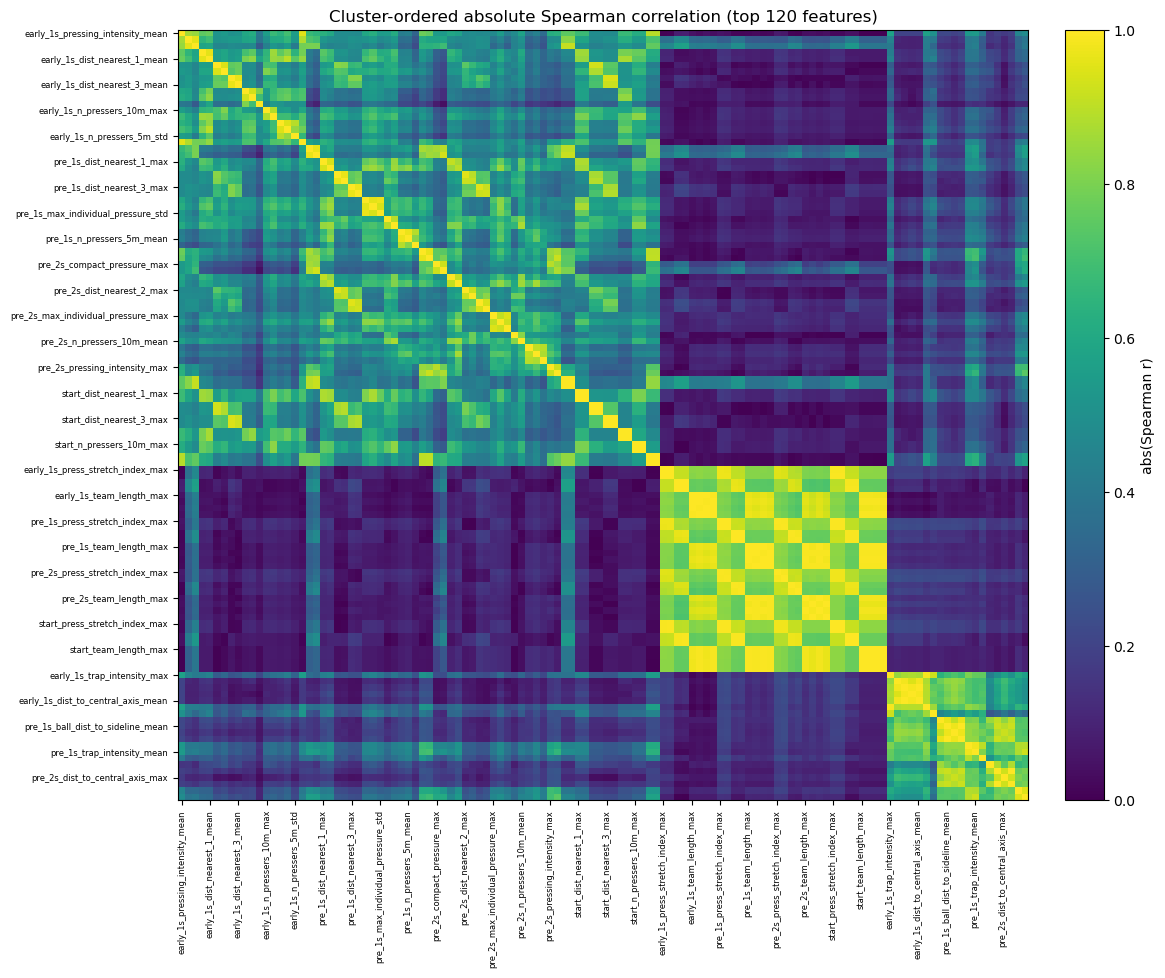

Feature correlation diagnostics saved.
Rows analysed: 6,851
Features analysed: 474
High-correlation pairs: 3,299
Redundancy clusters: 119
Non-singleton clusters: 57
Output directory: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_feature_correlation_outputs

Top high-correlation pairs


,method,feature_a,feature_b,correlation,abs_correlation,family_a,concept_a,window_a,stat_a,family_b,concept_b,window_b,stat_b,same_family,same_concept,same_window,same_stat,cross_window_same_concept,threshold_band
0,pearson,pre_2s_ball_dist_to_sideline_std,pre_2s_dist_to_central_axis_std,1.0,1.0,ball_state,ball_dist_to_sideline,pre_2s,std,other,dist_to_central_axis,pre_2s,std,False,False,True,True,False,>=0.95
1,pearson,early_1s_n_pressers_evaluated_mean,early_1s_n_pressers_evaluated_max,1.0,1.0,pressing_team_shape,n_pressers_evaluated,early_1s,mean,pressing_team_shape,n_pressers_evaluated,early_1s,max,True,True,True,False,False,>=0.95
2,pearson,start_n_sprinting_pressers_mean,start_n_sprinting_pressers_max,1.0,1.0,other,n_sprinting_pressers,start,mean,other,n_sprinting_pressers,start,max,True,True,True,False,False,>=0.95
3,pearson,start_opp_stretch_index_mean,start_opp_stretch_index_max,1.0,1.0,pressing_team_shape,opp_stretch_index,start,mean,pressing_team_shape,opp_stretch_index,start,max,True,True,True,False,False,>=0.95
4,pearson,start_ball_dist_to_sideline_mean,start_ball_dist_to_sideline_max,1.0,1.0,ball_state,ball_dist_to_sideline,start,mean,ball_state,ball_dist_to_sideline,start,max,True,True,True,False,False,>=0.95
5,pearson,start_ball_y_mean,start_ball_y_max,1.0,1.0,ball_state,ball_y,start,mean,ball_state,ball_y,start,max,True,True,True,False,False,>=0.95
6,pearson,start_vertical_compactness_mean,start_vertical_compactness_max,1.0,1.0,pressing_team_shape,vertical_compactness,start,mean,pressing_team_shape,vertical_compactness,start,max,True,True,True,False,False,>=0.95
7,pearson,start_nearest_presser_speed_mean,start_nearest_presser_speed_max,1.0,1.0,pressure_intensity,nearest_presser_speed,start,mean,pressure_intensity,nearest_presser_speed,start,max,True,True,True,False,False,>=0.95
8,pearson,start_avg_pressing_team_speed_mean,start_avg_pressing_team_speed_max,1.0,1.0,motion,avg_pressing_team_speed,start,mean,motion,avg_pressing_team_speed,start,max,True,True,True,False,False,>=0.95
9,pearson,start_pressing_intensity_mean,start_pressing_intensity_max,1.0,1.0,pressure_intensity,pressing_intensity,start,mean,pressure_intensity,pressing_intensity,start,max,True,True,True,False,False,>=0.95



Drop/keep recommendation preview


,cluster_id,feature,representative_feature,is_representative,cluster_size,missing_rate,target_assoc_abs,window,concept,stat,family,recommendation,reason
0,1,early_1s_pressing_intensity_mean,early_1s_pressing_intensity_mean,True,68,0.0,0.163430,early_1s,pressing_intensity,mean,pressure_intensity,keep,"Selected representative: low missingness, target association, causal timing,..."
1,1,early_1s_compact_pressure_max,early_1s_pressing_intensity_mean,False,68,0.0,0.116951,early_1s,compact_pressure,max,pressure_intensity,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
2,1,early_1s_compact_pressure_mean,early_1s_pressing_intensity_mean,False,68,0.0,0.094716,early_1s,compact_pressure,mean,pressure_intensity,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
3,1,early_1s_dist_nearest_1_max,early_1s_pressing_intensity_mean,False,68,0.0,0.118747,early_1s,dist_nearest_1,max,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
4,1,early_1s_dist_nearest_1_mean,early_1s_pressing_intensity_mean,False,68,0.0,0.118639,early_1s,dist_nearest_1,mean,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
5,1,early_1s_dist_nearest_2_max,early_1s_pressing_intensity_mean,False,68,0.0,0.076241,early_1s,dist_nearest_2,max,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
6,1,early_1s_dist_nearest_2_mean,early_1s_pressing_intensity_mean,False,68,0.0,0.083699,early_1s,dist_nearest_2,mean,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
7,1,early_1s_dist_nearest_3_max,early_1s_pressing_intensity_mean,False,68,0.0,0.069168,early_1s,dist_nearest_3,max,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
8,1,early_1s_dist_nearest_3_mean,early_1s_pressing_intensity_mean,False,68,0.0,0.070117,early_1s,dist_nearest_3,mean,other,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...
9,1,early_1s_max_individual_pressure_max,early_1s_pressing_intensity_mean,False,68,0.0,0.080363,early_1s,max_individual_pressure,max,pressure_intensity,drop_redundant_candidate,Highly correlated with the cluster representative; keep for audit unless red...


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature redundancy and correlation diagnostics
# ══════════════════════════════════════════════════════════════════════════════

from collections import Counter, defaultdict, deque
from datetime import datetime

FEATURE_CORRELATION_DIR = ARTIFACT_ROOT / "full_season_feature_correlation_outputs"
FEATURE_CORRELATION_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_CORRELATION_METADATA_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_feature_metadata.csv"
FEATURE_CORRELATION_PEARSON_MATRIX_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_pearson_matrix.parquet"
FEATURE_CORRELATION_SPEARMAN_MATRIX_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_spearman_matrix.parquet"
FEATURE_CORRELATION_HIGH_PAIRS_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_high_pairs.csv"
FEATURE_REDUNDANCY_CLUSTERS_PATH = FEATURE_CORRELATION_DIR / "press_feature_redundancy_clusters.json"
FEATURE_REDUNDANCY_CLUSTER_MEMBERS_PATH = FEATURE_CORRELATION_DIR / "press_feature_redundancy_cluster_members.csv"
FEATURE_CORRELATION_RECOMMENDATIONS_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_recommendations.csv"
FEATURE_REDUCED_SETS_PATH = FEATURE_CORRELATION_DIR / "press_feature_reduced_sets.json"
FEATURE_CORRELATION_CONCEPT_MATRIX_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_concept_matrix.csv"
FEATURE_CORRELATION_CONCEPT_SUMMARY_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_concept_summary.csv"
FEATURE_CORRELATION_FAMILY_SUMMARY_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_family_summary.csv"
FEATURE_CORRELATION_HEATMAP_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_clustered_heatmap.png"
FEATURE_CORRELATION_MANIFEST_PATH = FEATURE_CORRELATION_DIR / "press_feature_correlation_manifest.json"

CORRELATION_PAIR_THRESHOLD = 0.80
REDUCED_SET_THRESHOLDS = {
    "conservative_0_95": 0.95,
    "moderate_0_90": 0.90,
    "aggressive_0_80": 0.80,
}
CORRELATION_HEATMAP_MAX_FEATURES = 120


def _load_active_feature_manifest():
    manifest_path = ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json"
    if manifest_path.exists():
        with open(manifest_path) as fh:
            return json.load(fh)
    return {}


def _load_feature_correlation_inputs(feature_view="early_1s"):
    manifest = _load_active_feature_manifest()
    if "model_numeric_df" in globals() and isinstance(model_numeric_df, pd.DataFrame):
        source_df = model_numeric_df.copy()
        source_path = "in_memory:model_numeric_df"
    else:
        candidate_paths = []
        active_path = manifest.get("active_feature_path")
        if active_path:
            candidate_paths.append(Path(active_path))
        candidate_paths.extend([
            globals().get("SETTLED_HIGH_PRESS_FEATURES_PATH", ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet"),
            ARTIFACT_ROOT / "full_season_press_features_model_numeric.parquet",
        ])
        source_df = None
        source_path = None
        for candidate in candidate_paths:
            candidate = Path(candidate)
            if candidate.exists():
                source_df = pd.read_parquet(candidate)
                source_path = str(candidate)
                break
        if source_df is None:
            raise FileNotFoundError("No feature table found for correlation diagnostics.")

    if feature_view == "start_only" and "feature_cols_start_clean" in globals():
        feature_cols = list(feature_cols_start_clean)
    elif feature_view == "early_1s" and "feature_cols_early_clean" in globals():
        feature_cols = list(feature_cols_early_clean)
    else:
        manifest_key = "feature_cols_start" if feature_view == "start_only" else "feature_cols_early"
        feature_cols = list(manifest.get(manifest_key, []))

    feature_cols = [col for col in feature_cols if col in source_df.columns]
    if not feature_cols:
        raise ValueError(f"No feature columns found for feature_view={feature_view}.")
    return source_df.reset_index(drop=True), feature_cols, manifest, source_path


def parse_press_feature_name(feature):
    feature = str(feature)
    windows = ["early_1s", "pre_2s", "pre_1s", "start"]
    stats = ["mean", "max", "std", "median", "min"]
    window = "context"
    remainder = feature
    for candidate in windows:
        prefix = f"{candidate}_"
        if feature.startswith(prefix):
            window = candidate
            remainder = feature[len(prefix):]
            break
    if feature.startswith("delta_") or "early_vs_pre" in feature:
        window = "delta"
        remainder = feature.replace("delta_", "", 1)

    stat = "raw"
    concept = remainder
    for candidate in stats:
        suffix = f"_{candidate}"
        if remainder.endswith(suffix):
            stat = candidate
            concept = remainder[:-len(suffix)]
            break

    family_rules = {
        "ball_state": ["ball_x", "ball_y", "ball_speed", "sideline", "goal_line", "progress"],
        "pressing_team_shape": ["team_length", "team_width", "team_aspect", "team_centroid", "team_surface", "stretch", "vertical_compactness", "n_pressers"],
        "opponent_shape": ["opponent_", "escape", "passing_lane", "local_overload"],
        "pressure_intensity": ["pressing_intensity", "pressure", "trap_intensity", "closing", "speed_differential", "nearest_presser", "distance_nearest"],
        "motion": ["speed", "velocity", "acceleration", "direction"],
        "event_context": ["previous_event", "restart", "goalkeeper", "height_zone", "seconds_since"],
        "delta": ["early_vs_pre", "delta"],
    }
    family = "other"
    lowered = concept.lower()
    for candidate_family, tokens in family_rules.items():
        if any(token in lowered for token in tokens):
            family = candidate_family
            break

    return {
        "feature": feature,
        "window": window,
        "concept": concept,
        "stat": stat,
        "family": family,
    }


def _prepare_correlation_matrix(df, feature_cols):
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    missing_rate = X.isna().mean()
    nunique = X.nunique(dropna=True)
    keep_cols = [col for col in X.columns if missing_rate[col] < 1.0 and nunique[col] > 1]
    dropped_cols = sorted(set(X.columns).difference(keep_cols))
    return X[keep_cols].copy(), missing_rate.loc[keep_cols], dropped_cols


def _corr_to_high_pair_table(corr_matrix, metadata_df, method, threshold=CORRELATION_PAIR_THRESHOLD):
    features = list(corr_matrix.columns)
    if len(features) < 2:
        return pd.DataFrame()
    upper_i, upper_j = np.triu_indices(len(features), k=1)
    values = corr_matrix.to_numpy()[upper_i, upper_j]
    pairs = pd.DataFrame({
        "method": method,
        "feature_a": [features[i] for i in upper_i],
        "feature_b": [features[j] for j in upper_j],
        "correlation": values,
    })
    pairs = pairs.dropna(subset=["correlation"]).copy()
    pairs["abs_correlation"] = pairs["correlation"].abs()
    pairs = pairs[pairs["abs_correlation"].ge(float(threshold))].copy()
    if pairs.empty:
        return pairs

    meta = metadata_df.set_index("feature")
    for side in ["a", "b"]:
        pairs[f"family_{side}"] = pairs[f"feature_{side}"].map(meta["family"])
        pairs[f"concept_{side}"] = pairs[f"feature_{side}"].map(meta["concept"])
        pairs[f"window_{side}"] = pairs[f"feature_{side}"].map(meta["window"])
        pairs[f"stat_{side}"] = pairs[f"feature_{side}"].map(meta["stat"])
    pairs["same_family"] = pairs["family_a"].eq(pairs["family_b"])
    pairs["same_concept"] = pairs["concept_a"].eq(pairs["concept_b"])
    pairs["same_window"] = pairs["window_a"].eq(pairs["window_b"])
    pairs["same_stat"] = pairs["stat_a"].eq(pairs["stat_b"])
    pairs["cross_window_same_concept"] = pairs["same_concept"] & ~pairs["same_window"]
    pairs["threshold_band"] = np.select(
        [
            pairs["abs_correlation"].ge(0.95),
            pairs["abs_correlation"].ge(0.90),
            pairs["abs_correlation"].ge(0.80),
        ],
        [">=0.95", "0.90-0.95", "0.80-0.90"],
        default="<0.80",
    )
    return pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)


def _feature_target_association(X, target):
    if target is None:
        return pd.Series(0.0, index=X.columns)
    y = pd.Series(target).astype(float)
    values = {}
    for col in X.columns:
        pair = pd.concat([X[col].astype(float), y], axis=1).dropna()
        if len(pair) < 5 or pair.iloc[:, 0].nunique() <= 1 or pair.iloc[:, 1].nunique() <= 1:
            values[col] = 0.0
        else:
            values[col] = abs(float(pair.iloc[:, 0].corr(pair.iloc[:, 1])))
    return pd.Series(values).fillna(0.0)


def _timing_priority(window):
    return {"start": 0, "pre_1s": 1, "pre_2s": 2, "early_1s": 3, "delta": 4, "context": 5}.get(str(window), 6)


def _connected_components_from_corr(abs_corr_matrix, threshold):
    features = list(abs_corr_matrix.columns)
    adjacency = {feature: set() for feature in features}
    arr = abs_corr_matrix.to_numpy()
    for i, j in zip(*np.triu_indices(len(features), k=1)):
        value = arr[i, j]
        if pd.notna(value) and value >= threshold:
            adjacency[features[i]].add(features[j])
            adjacency[features[j]].add(features[i])

    components = []
    seen = set()
    for feature in features:
        if feature in seen:
            continue
        queue = deque([feature])
        seen.add(feature)
        members = []
        while queue:
            current = queue.popleft()
            members.append(current)
            for neighbor in adjacency[current]:
                if neighbor not in seen:
                    seen.add(neighbor)
                    queue.append(neighbor)
        components.append(sorted(members))
    return components


def _choose_cluster_representative(members, metadata_df, missing_rate, target_assoc):
    meta = metadata_df.set_index("feature")
    ranking = []
    for feature in members:
        ranking.append({
            "feature": feature,
            "missing_rate": float(missing_rate.get(feature, 0.0)),
            "target_assoc_abs": float(target_assoc.get(feature, 0.0)),
            "timing_priority": int(_timing_priority(meta.loc[feature, "window"])),
            "concept": str(meta.loc[feature, "concept"]),
        })
    ranking_df = pd.DataFrame(ranking)
    ranking_df = ranking_df.sort_values(
        ["missing_rate", "target_assoc_abs", "timing_priority", "feature"],
        ascending=[True, False, True, True],
    )
    return str(ranking_df.iloc[0]["feature"])


def _summarize_redundancy_clusters(abs_corr_matrix, metadata_df, missing_rate, target_assoc, threshold=CORRELATION_PAIR_THRESHOLD):
    meta = metadata_df.set_index("feature")
    components = _connected_components_from_corr(abs_corr_matrix, threshold=threshold)
    clusters = []
    member_rows = []
    for cluster_idx, members in enumerate(sorted(components, key=lambda values: (-len(values), values[0])), start=1):
        representative = _choose_cluster_representative(members, metadata_df, missing_rate, target_assoc)
        sub = abs_corr_matrix.loc[members, members]
        if len(members) > 1:
            upper_values = sub.to_numpy()[np.triu_indices(len(members), k=1)]
            mean_abs_corr = float(np.nanmean(upper_values))
            max_abs_corr = float(np.nanmax(upper_values))
        else:
            mean_abs_corr = np.nan
            max_abs_corr = np.nan
        member_meta = meta.loc[members]
        dominant_family = Counter(member_meta["family"]).most_common(1)[0][0]
        dominant_concept = Counter(member_meta["concept"]).most_common(1)[0][0]
        cluster = {
            "cluster_id": int(cluster_idx),
            "threshold": float(threshold),
            "cluster_size": int(len(members)),
            "representative_feature": representative,
            "dominant_family": str(dominant_family),
            "dominant_concept": str(dominant_concept),
            "windows": sorted(member_meta["window"].astype(str).unique().tolist()),
            "stats": sorted(member_meta["stat"].astype(str).unique().tolist()),
            "mean_abs_correlation": None if pd.isna(mean_abs_corr) else float(mean_abs_corr),
            "max_abs_correlation": None if pd.isna(max_abs_corr) else float(max_abs_corr),
            "members": members,
        }
        clusters.append(cluster)
        for feature in members:
            member_rows.append({
                "cluster_id": int(cluster_idx),
                "feature": feature,
                "representative_feature": representative,
                "is_representative": feature == representative,
                "cluster_size": int(len(members)),
                "missing_rate": float(missing_rate.get(feature, 0.0)),
                "target_assoc_abs": float(target_assoc.get(feature, 0.0)),
                **parse_press_feature_name(feature),
            })
    return clusters, pd.DataFrame(member_rows)


def _build_recommendations(cluster_members_df):
    recommendations = cluster_members_df.copy()
    recommendations["recommendation"] = np.where(
        recommendations["is_representative"],
        "keep",
        np.where(recommendations["cluster_size"].gt(1), "drop_redundant_candidate", "keep"),
    )
    recommendations["reason"] = np.where(
        recommendations["is_representative"],
        "Selected representative: low missingness, target association, causal timing, and stable name order.",
        "Highly correlated with the cluster representative; keep for audit unless reduced feature set is evaluated.",
    )
    return recommendations.sort_values(["cluster_id", "is_representative", "feature"], ascending=[True, False, True]).reset_index(drop=True)


def _build_reduced_feature_sets(abs_corr_matrix, metadata_df, missing_rate, target_assoc, thresholds=REDUCED_SET_THRESHOLDS):
    reduced_sets = {}
    all_features = list(abs_corr_matrix.columns)
    for set_name, threshold in thresholds.items():
        clusters, members = _summarize_redundancy_clusters(abs_corr_matrix, metadata_df, missing_rate, target_assoc, threshold=threshold)
        representatives = members.loc[members["is_representative"], "feature"].tolist()
        reduced_sets[set_name] = {
            "threshold": float(threshold),
            "n_original_features": int(len(all_features)),
            "n_reduced_features": int(len(representatives)),
            "n_dropped_candidates": int(len(all_features) - len(representatives)),
            "features": representatives,
            "dropped_candidates": sorted(set(all_features).difference(representatives)),
        }
    return reduced_sets


def _build_concept_correlation_matrix(abs_corr_matrix, metadata_df):
    meta = metadata_df.set_index("feature")
    concepts = sorted(meta["concept"].astype(str).unique().tolist())
    concept_matrix = pd.DataFrame(index=concepts, columns=concepts, dtype=float)
    for concept_a in concepts:
        features_a = meta.index[meta["concept"].astype(str).eq(concept_a)].tolist()
        for concept_b in concepts:
            features_b = meta.index[meta["concept"].astype(str).eq(concept_b)].tolist()
            block = abs_corr_matrix.loc[features_a, features_b].to_numpy(dtype=float)
            if concept_a == concept_b and block.size > 1:
                mask = ~np.eye(block.shape[0], block.shape[1], dtype=bool)
                values = block[mask]
            else:
                values = block.ravel()
            concept_matrix.loc[concept_a, concept_b] = float(np.nanmean(values)) if len(values) else np.nan
    concept_summary = metadata_df.groupby(["family", "concept"], as_index=False).agg(n_features=("feature", "nunique"))
    return concept_matrix, concept_summary


def _plot_clustered_correlation_heatmap(abs_corr_matrix, cluster_members_df, output_path, max_features=CORRELATION_HEATMAP_MAX_FEATURES):
    try:
        import matplotlib.pyplot as plt
    except Exception as exc:
        print(f"Skipping correlation heatmap: matplotlib unavailable ({exc})")
        return False

    ordered = cluster_members_df.sort_values(["cluster_size", "cluster_id", "is_representative", "feature"], ascending=[False, True, False, True])
    selected_features = ordered["feature"].head(max_features).tolist()
    heatmap = abs_corr_matrix.loc[selected_features, selected_features]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(heatmap.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto")
    tick_step = max(1, int(np.ceil(len(selected_features) / 35)))
    tick_positions = np.arange(0, len(selected_features), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels([selected_features[i] for i in tick_positions], rotation=90, fontsize=6)
    ax.set_yticklabels([selected_features[i] for i in tick_positions], fontsize=6)
    ax.set_title(f"Cluster-ordered absolute Spearman correlation (top {len(selected_features)} features)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="abs(Spearman r)")
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    return True


def build_feature_correlation_diagnostics(feature_view="early_1s"):
    df, feature_cols, manifest, source_path = _load_feature_correlation_inputs(feature_view=feature_view)
    X, missing_rate, dropped_cols = _prepare_correlation_matrix(df, feature_cols)
    metadata_df = pd.DataFrame([parse_press_feature_name(feature) for feature in X.columns])
    metadata_df.to_csv(FEATURE_CORRELATION_METADATA_PATH, index=False)

    pearson_corr = X.corr(method="pearson", min_periods=5)
    spearman_corr = X.corr(method="spearman", min_periods=5)
    pearson_corr.to_parquet(FEATURE_CORRELATION_PEARSON_MATRIX_PATH)
    spearman_corr.to_parquet(FEATURE_CORRELATION_SPEARMAN_MATRIX_PATH)

    pearson_pairs = _corr_to_high_pair_table(pearson_corr, metadata_df, method="pearson")
    spearman_pairs = _corr_to_high_pair_table(spearman_corr, metadata_df, method="spearman")
    high_pairs = pd.concat([pearson_pairs, spearman_pairs], ignore_index=True) if not pearson_pairs.empty or not spearman_pairs.empty else pd.DataFrame()
    high_pairs.to_csv(FEATURE_CORRELATION_HIGH_PAIRS_PATH, index=False)

    target_assoc = _feature_target_association(X, df["press_success_any"] if "press_success_any" in df.columns else None)
    abs_spearman = spearman_corr.abs()
    clusters, cluster_members = _summarize_redundancy_clusters(abs_spearman, metadata_df, missing_rate, target_assoc)
    cluster_members.to_csv(FEATURE_REDUNDANCY_CLUSTER_MEMBERS_PATH, index=False)
    with open(FEATURE_REDUNDANCY_CLUSTERS_PATH, "w") as fh:
        json.dump({"threshold": CORRELATION_PAIR_THRESHOLD, "clusters": clusters}, fh, indent=2)

    recommendations = _build_recommendations(cluster_members)
    recommendations.to_csv(FEATURE_CORRELATION_RECOMMENDATIONS_PATH, index=False)

    reduced_sets = _build_reduced_feature_sets(abs_spearman, metadata_df, missing_rate, target_assoc)
    with open(FEATURE_REDUCED_SETS_PATH, "w") as fh:
        json.dump(reduced_sets, fh, indent=2)

    concept_matrix, concept_summary = _build_concept_correlation_matrix(abs_spearman, metadata_df)
    concept_matrix.to_csv(FEATURE_CORRELATION_CONCEPT_MATRIX_PATH)
    concept_summary.to_csv(FEATURE_CORRELATION_CONCEPT_SUMMARY_PATH, index=False)

    if high_pairs.empty:
        family_summary = pd.DataFrame(columns=["method", "family_a", "family_b", "n_pairs", "mean_abs_correlation", "max_abs_correlation"])
    else:
        family_summary = (
            high_pairs.groupby(["method", "family_a", "family_b"], as_index=False)
            .agg(
                n_pairs=("abs_correlation", "size"),
                mean_abs_correlation=("abs_correlation", "mean"),
                max_abs_correlation=("abs_correlation", "max"),
            )
            .sort_values(["method", "n_pairs", "max_abs_correlation"], ascending=[True, False, False])
        )
    family_summary.to_csv(FEATURE_CORRELATION_FAMILY_SUMMARY_PATH, index=False)

    heatmap_written = _plot_clustered_correlation_heatmap(abs_spearman, cluster_members, FEATURE_CORRELATION_HEATMAP_PATH)

    manifest_payload = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "feature_view": feature_view,
        "source_path": source_path,
        "n_rows": int(len(df)),
        "n_requested_features": int(len(feature_cols)),
        "n_analyzed_features": int(X.shape[1]),
        "dropped_safety_features": dropped_cols,
        "pair_threshold": float(CORRELATION_PAIR_THRESHOLD),
        "n_high_correlation_pairs": int(len(high_pairs)),
        "n_redundancy_clusters": int(len(clusters)),
        "n_non_singleton_clusters": int(sum(cluster["cluster_size"] > 1 for cluster in clusters)),
        "reduced_sets": {name: {k: v for k, v in payload.items() if k != "features" and k != "dropped_candidates"} for name, payload in reduced_sets.items()},
        "output_paths": {
            "feature_metadata": str(FEATURE_CORRELATION_METADATA_PATH),
            "pearson_matrix": str(FEATURE_CORRELATION_PEARSON_MATRIX_PATH),
            "spearman_matrix": str(FEATURE_CORRELATION_SPEARMAN_MATRIX_PATH),
            "high_pairs": str(FEATURE_CORRELATION_HIGH_PAIRS_PATH),
            "clusters": str(FEATURE_REDUNDANCY_CLUSTERS_PATH),
            "cluster_members": str(FEATURE_REDUNDANCY_CLUSTER_MEMBERS_PATH),
            "recommendations": str(FEATURE_CORRELATION_RECOMMENDATIONS_PATH),
            "reduced_sets": str(FEATURE_REDUCED_SETS_PATH),
            "concept_matrix": str(FEATURE_CORRELATION_CONCEPT_MATRIX_PATH),
            "concept_summary": str(FEATURE_CORRELATION_CONCEPT_SUMMARY_PATH),
            "family_summary": str(FEATURE_CORRELATION_FAMILY_SUMMARY_PATH),
            "heatmap": str(FEATURE_CORRELATION_HEATMAP_PATH) if heatmap_written else None,
        },
    }
    with open(FEATURE_CORRELATION_MANIFEST_PATH, "w") as fh:
        json.dump(manifest_payload, fh, indent=2)

    return {
        "manifest": manifest_payload,
        "feature_metadata": metadata_df,
        "high_pairs": high_pairs,
        "cluster_members": cluster_members,
        "recommendations": recommendations,
        "concept_summary": concept_summary,
        "family_summary": family_summary,
    }


feature_correlation_outputs = build_feature_correlation_diagnostics(feature_view="early_1s")
feature_correlation_manifest = feature_correlation_outputs["manifest"]
feature_high_pairs_df = feature_correlation_outputs["high_pairs"]
feature_recommendations_df = feature_correlation_outputs["recommendations"]

print("Feature correlation diagnostics saved.")
print(f"Rows analysed: {feature_correlation_manifest['n_rows']:,}")
print(f"Features analysed: {feature_correlation_manifest['n_analyzed_features']:,}")
print(f"High-correlation pairs: {feature_correlation_manifest['n_high_correlation_pairs']:,}")
print(f"Redundancy clusters: {feature_correlation_manifest['n_redundancy_clusters']:,}")
print(f"Non-singleton clusters: {feature_correlation_manifest['n_non_singleton_clusters']:,}")
print(f"Output directory: {FEATURE_CORRELATION_DIR}")

print("\nTop high-correlation pairs")
display(feature_high_pairs_df.head(20))
print("\nDrop/keep recommendation preview")
display(feature_recommendations_df.head(30))

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# W&B sweep helpers for binary press-success models
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

# Optional sklearn-native fallback, intentionally not active in the primary thesis model set:
# from sklearn.ensemble import HistGradientBoostingClassifier

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LGBMClassifier = None
    LIGHTGBM_AVAILABLE = False
    LIGHTGBM_IMPORT_ERROR = repr(exc)

WANDB_PROJECT_NAME = "MASTER_SDU"
WANDB_ENTITY = None
WANDB_MODE = "online"  # Set to "offline" or "disabled" if needed.
RUN_WANDB_SWEEPS_NOW = False
WANDB_SWEEP_COUNT_PER_MODEL = 20
ACTIVE_BINARY_MODEL_FAMILIES = ["random_forest", "lightgbm", "xgboost"]

MODEL_WANDB_SWEEP_CONFIGS_PATH = ARTIFACT_ROOT / "full_season_press_model_wandb_sweep_configs.json"
MODEL_WANDB_SWEEP_RUNS_PATH = ARTIFACT_ROOT / "full_season_press_model_wandb_sweep_runs.json"
MODEL_LOCAL_TUNING_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_model_local_tuning_results.parquet"

try:
    import wandb
    WANDB_AVAILABLE = True
    
    # Try to login using Colab Secrets if running in Colab
    try:
        from google.colab import userdata
        wandb_key = userdata.get('WANDB_API_KEY')
        wandb.login(key=wandb_key)
        print("Successfully logged into W&B using Colab Secrets.")
    except ImportError:
        pass
    except Exception:
        print("WANDB_API_KEY not found in secrets. Interactive login prompted:")
        wandb.login()
        
except Exception as exc:
    wandb = None
    WANDB_AVAILABLE = False
    WANDB_IMPORT_ERROR = repr(exc)


def _binary_best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_idx = int(np.nanargmax(f1_values))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


def evaluate_binary_scores(y_true, y_score, prefix="validation"):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    threshold, best_f1 = _binary_best_f1_threshold(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        f"{prefix}_roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        f"{prefix}_pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        f"{prefix}_brier": float(brier_score_loss(y_true, y_score)),
        f"{prefix}_best_f1_threshold": float(threshold),
        f"{prefix}_best_f1": float(best_f1),
        f"{prefix}_precision_at_best_f1": float(precision_score(y_true, y_pred, zero_division=0)),
        f"{prefix}_recall_at_best_f1": float(recall_score(y_true, y_pred, zero_division=0)),
        f"{prefix}_f1_at_0_5": float(f1_score(y_true, (y_score >= 0.5).astype(int), zero_division=0)),
        f"{prefix}_tn": int(cm[0, 0]),
        f"{prefix}_fp": int(cm[0, 1]),
        f"{prefix}_fn": int(cm[1, 0]),
        f"{prefix}_tp": int(cm[1, 1]),
    }


def make_numeric_binary_preprocessor(feature_cols):
    return ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def default_binary_model_params(model_family):
    defaults = {
        "random_forest": {
            "n_estimators": 500,
            "max_depth": None,
            "min_samples_leaf": 8,
            "max_features": "sqrt",
            "class_weight": "balanced_subsample",
        },
        "lightgbm": {
            "n_estimators": 500,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "min_child_samples": 20,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.0,
            "reg_lambda": 1.0,
            "scale_pos_weight": 1.0,
        },
        "xgboost": {
            "n_estimators": 500,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "min_child_weight": 1.0,
            "reg_lambda": 1.0,
            "reg_alpha": 0.0,
            "scale_pos_weight": 1.0,
        },
    }
    if model_family not in defaults:
        raise ValueError(f"Unknown model family: {model_family}")
    return defaults[model_family].copy()


def make_binary_model_pipeline(model_family, feature_cols, params=None, random_state=42):
    params = {**default_binary_model_params(model_family), **(params or {})}
    prep = make_numeric_binary_preprocessor(feature_cols)

    if model_family == "random_forest":
        model = RandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            max_depth=None if params.get("max_depth") in [None, "None", 0] else int(params["max_depth"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            class_weight=params.get("class_weight"),
            random_state=random_state,
            n_jobs=-1,
        )
    elif model_family == "lightgbm":
        if not LIGHTGBM_AVAILABLE:
            raise ImportError(f"LightGBM is required for lightgbm models: {globals().get('LIGHTGBM_IMPORT_ERROR', 'unknown import error')}")
        model = LGBMClassifier(
            n_estimators=int(params["n_estimators"]),
            learning_rate=float(params["learning_rate"]),
            num_leaves=int(params["num_leaves"]),
            max_depth=int(params["max_depth"]),
            min_child_samples=int(params["min_child_samples"]),
            subsample=float(params["subsample"]),
            colsample_bytree=float(params["colsample_bytree"]),
            reg_alpha=float(params["reg_alpha"]),
            reg_lambda=float(params["reg_lambda"]),
            scale_pos_weight=float(params["scale_pos_weight"]),
            objective="binary",
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
        )
    # Optional sklearn-native fallback, intentionally inactive:
    # elif model_family == "hist_gradient_boosting":
    #     model = HistGradientBoostingClassifier(
    #         learning_rate=float(params["learning_rate"]),
    #         max_iter=int(params["max_iter"]),
    #         max_leaf_nodes=int(params["max_leaf_nodes"]),
    #         l2_regularization=float(params["l2_regularization"]),
    #         min_samples_leaf=int(params["min_samples_leaf"]),
    #         random_state=random_state,
    #     )
    elif model_family == "xgboost":
        try:
            from xgboost import XGBClassifier
        except Exception as exc:
            raise ImportError(f"XGBoost is required for xgboost sweeps: {exc}") from exc
        model = XGBClassifier(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            learning_rate=float(params["learning_rate"]),
            subsample=float(params["subsample"]),
            colsample_bytree=float(params["colsample_bytree"]),
            min_child_weight=float(params["min_child_weight"]),
            reg_lambda=float(params["reg_lambda"]),
            reg_alpha=float(params["reg_alpha"]),
            scale_pos_weight=float(params["scale_pos_weight"]),
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Unknown model family: {model_family}")

    return Pipeline(steps=[("prep", prep), ("model", model)])


def attach_split_column(df, assignments):
    source = df.reset_index(drop=True).copy()
    split_lookup = assignments[["row_position", "split"]].copy()
    out = source.merge(split_lookup, left_index=True, right_on="row_position", how="left").sort_values("row_position")
    out = out.reset_index(drop=True)
    if out["split"].isna().any():
        raise RuntimeError("Split assignment merge produced missing split labels.")
    return out


def train_validate_binary_model(
    model_family,
    params,
    df,
    assignments,
    feature_cols,
    target_col="press_success_any",
    random_state=42,
):
    model_df = attach_split_column(df, assignments)
    train_df = model_df[model_df["split"].eq("train")].copy()
    validation_df = model_df[model_df["split"].eq("validation")].copy()

    X_train = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = train_df[target_col].astype(int)
    X_validation = validation_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_validation = validation_df[target_col].astype(int)

    pipeline = make_binary_model_pipeline(model_family, feature_cols, params=params, random_state=random_state)
    pipeline.fit(X_train, y_train)
    validation_score = pipeline.predict_proba(X_validation)[:, 1]

    metrics = evaluate_binary_scores(y_validation, validation_score, prefix="validation")
    metrics.update({
        "model_family": model_family,
        "n_train": int(len(train_df)),
        "n_validation": int(len(validation_df)),
        "n_features": int(len(feature_cols)),
    })
    return pipeline, metrics


BINARY_WANDB_SWEEP_CONFIGS = {
    "random_forest": {
        "method": "bayes",
        "metric": {"name": "validation_pr_auc", "goal": "maximize"},
        "parameters": {
            "n_estimators": {"values": [300, 500, 800]},
            "max_depth": {"values": [0, 4, 6, 10, 14]},
            "min_samples_leaf": {"values": [3, 5, 8, 12, 20]},
            "max_features": {"values": ["sqrt", "log2", 0.35, 0.50, 0.75]},
            "class_weight": {"values": ["balanced", "balanced_subsample", None]},
        },
    },
    "lightgbm": {
        "method": "bayes",
        "metric": {"name": "validation_pr_auc", "goal": "maximize"},
        "parameters": {
            "n_estimators": {"values": [200, 350, 500, 800]},
            "learning_rate": {"min": 0.01, "max": 0.10},
            "num_leaves": {"values": [15, 31, 63, 127]},
            "max_depth": {"values": [-1, 3, 5, 7, 10]},
            "min_child_samples": {"values": [10, 20, 35, 50, 80]},
            "subsample": {"min": 0.65, "max": 1.0},
            "colsample_bytree": {"min": 0.55, "max": 1.0},
            "reg_alpha": {"min": 0.0, "max": 1.0},
            "reg_lambda": {"min": 0.1, "max": 5.0},
            "scale_pos_weight": {"values": [1.0, 2.0, 3.0, 5.25, 7.0]},
        },
    },
    # Optional sklearn-native fallback, intentionally inactive:
    # "hist_gradient_boosting": {
    #     "method": "bayes",
    #     "metric": {"name": "validation_pr_auc", "goal": "maximize"},
    #     "parameters": {
    #         "learning_rate": {"min": 0.01, "max": 0.12},
    #         "max_iter": {"values": [100, 200, 300, 500]},
    #         "max_leaf_nodes": {"values": [15, 31, 63]},
    #         "l2_regularization": {"min": 0.0, "max": 0.30},
    #         "min_samples_leaf": {"values": [10, 20, 35, 50]},
    #     },
    # },
    "xgboost": {
        "method": "bayes",
        "metric": {"name": "validation_pr_auc", "goal": "maximize"},
        "parameters": {
            "n_estimators": {"values": [200, 350, 500, 800]},
            "max_depth": {"values": [2, 3, 4, 5]},
            "learning_rate": {"min": 0.01, "max": 0.10},
            "subsample": {"min": 0.65, "max": 1.0},
            "colsample_bytree": {"min": 0.55, "max": 1.0},
            "min_child_weight": {"values": [1.0, 2.0, 5.0, 10.0]},
            "reg_lambda": {"min": 0.1, "max": 5.0},
            "reg_alpha": {"min": 0.0, "max": 1.0},
            "scale_pos_weight": {"values": [1.0, 2.0, 3.0, 5.25, 7.0]},
        },
    },
}

with open(MODEL_WANDB_SWEEP_CONFIGS_PATH, "w") as fh:
    json.dump(BINARY_WANDB_SWEEP_CONFIGS, fh, indent=2)


def wandb_binary_sweep_train(model_family):
    if not WANDB_AVAILABLE:
        raise RuntimeError(f"wandb is not available: {globals().get('WANDB_IMPORT_ERROR', 'unknown import error')}")
    with wandb.init(project=WANDB_PROJECT_NAME, entity=WANDB_ENTITY, mode=WANDB_MODE) as run:
        params = dict(wandb.config)
        _, metrics = train_validate_binary_model(
            model_family=model_family,
            params=params,
            df=model_split_df,
            assignments=model_split_assignments,
            feature_cols=model_feature_cols_early,
            target_col="press_success_any",
            random_state=MODEL_SPLIT_RANDOM_STATE,
        )
        wandb.log(metrics)
        run.summary.update(metrics)
        run.summary["split_manifest_path"] = str(MODEL_SPLIT_MANIFEST_PATH)
        run.summary["feature_manifest_path"] = str(ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json")


def run_binary_wandb_sweep(model_family, count=WANDB_SWEEP_COUNT_PER_MODEL):
    if not WANDB_AVAILABLE:
        raise RuntimeError(f"wandb is not available: {globals().get('WANDB_IMPORT_ERROR', 'unknown import error')}")
    sweep_config = BINARY_WANDB_SWEEP_CONFIGS[model_family]
    sweep_id = wandb.sweep(sweep=sweep_config, project=WANDB_PROJECT_NAME, entity=WANDB_ENTITY)
    wandb.agent(sweep_id, function=lambda: wandb_binary_sweep_train(model_family), count=count)
    return sweep_id


sweep_run_ids = {}
if RUN_WANDB_SWEEPS_NOW:
    for _model_family in ACTIVE_BINARY_MODEL_FAMILIES:
        print(f"Starting W&B sweep for {_model_family}...")
        sweep_run_ids[_model_family] = run_binary_wandb_sweep(_model_family)
    with open(MODEL_WANDB_SWEEP_RUNS_PATH, "w") as fh:
        json.dump(sweep_run_ids, fh, indent=2)
else:
    print("W&B sweep helpers ready. Set RUN_WANDB_SWEEPS_NOW = True to launch sweeps.")
    print(f"wandb available: {WANDB_AVAILABLE}")
    print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")
    if not LIGHTGBM_AVAILABLE:
        print(f"LightGBM import issue: {globals().get('LIGHTGBM_IMPORT_ERROR', 'unknown')}")
    if not WANDB_AVAILABLE:
        print(f"wandb import issue: {globals().get('WANDB_IMPORT_ERROR', 'unknown')}")
print(f"Active binary model families: {ACTIVE_BINARY_MODEL_FAMILIES}")
print(f"Saved sweep configs: {MODEL_WANDB_SWEEP_CONFIGS_PATH}")

W&B sweep helpers ready. Set RUN_WANDB_SWEEPS_NOW = True to launch sweeps.
wandb available: True
LightGBM available: True
Active binary model families: ['random_forest', 'lightgbm', 'xgboost']
Saved sweep configs: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_wandb_sweep_configs.json


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# Final binary models from best W&B hyperparameters
# ══════════════════════════════════════════════════════════════════════════════

MODEL_BEST_HYPERPARAMETERS_PATH = ARTIFACT_ROOT / "full_season_press_model_best_hyperparameters.json"
MODEL_FINAL_TEST_METRICS_PATH = ARTIFACT_ROOT / "full_season_press_model_final_test_metrics.json"
MODEL_FINAL_TEST_PREDICTIONS_PATH = ARTIFACT_ROOT / "full_season_press_model_final_test_predictions.parquet"

RUN_FETCH_BEST_PARAMS_FROM_WANDB_NOW = False
RUN_FINAL_WANDB_SELECTED_MODELS_NOW = False
WANDB_SWEEP_IDS_BY_MODEL = {
    # Fill after sweeps are created, for example:
    # "random_forest": "entity/project/sweep_id",
    # "lightgbm": "entity/project/sweep_id",
    # "xgboost": "entity/project/sweep_id",
    # Optional fallback if re-enabled:
    # "hist_gradient_boosting": "entity/project/sweep_id",
}


def collect_best_hyperparameters_from_wandb_sweeps(sweep_ids_by_model, metric_name="validation_pr_auc"):
    """Collect one best W&B run per model family from completed sweeps."""
    if not WANDB_AVAILABLE:
        raise RuntimeError(f"wandb is not available: {globals().get('WANDB_IMPORT_ERROR', 'unknown import error')}")
    api = wandb.Api()
    best = {}
    for model_family, sweep_path in sweep_ids_by_model.items():
        sweep = api.sweep(sweep_path)
        best_run = None
        best_score = -np.inf
        for run in sweep.runs:
            score = run.summary.get(metric_name)
            if score is None or pd.isna(score):
                continue
            if float(score) > best_score:
                best_score = float(score)
                best_run = run
        if best_run is None:
            raise RuntimeError(f"No completed W&B runs with {metric_name} found for {model_family}.")
        params = {
            key: value
            for key, value in dict(best_run.config).items()
            if not str(key).startswith("_")
        }
        best[model_family] = {
            "model_family": model_family,
            "params": params,
            "selection_metric": metric_name,
            "selection_metric_value": best_score,
            "wandb_run_id": best_run.id,
            "wandb_run_name": best_run.name,
            "wandb_sweep_path": sweep_path,
            "validation_metrics": {
                key: value
                for key, value in dict(best_run.summary).items()
                if str(key).startswith("validation_")
            },
        }
    return best


def save_best_binary_hyperparameters(best_by_model, path=MODEL_BEST_HYPERPARAMETERS_PATH, source="wandb_sweep"):
    payload = {
        "source": source,
        "target_col": "press_success_any",
        "split_manifest_path": str(MODEL_SPLIT_MANIFEST_PATH),
        "feature_manifest_path": str(ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json"),
        "best_models": best_by_model,
    }
    with open(path, "w") as fh:
        json.dump(payload, fh, indent=2)
    return payload


def load_best_binary_hyperparameters(path=MODEL_BEST_HYPERPARAMETERS_PATH, allow_default_fallback=True):
    if path.exists():
        with open(path) as fh:
            return json.load(fh)
    if not allow_default_fallback:
        raise FileNotFoundError(
            f"Best hyperparameter file does not exist: {path}. Run W&B sweeps or create the file first."
        )
    print(
        "Best hyperparameter file not found. Using current baseline defaults as a dry-run fallback. "
        "Do not treat these as sweep-selected final parameters."
    )
    best_models = {}
    for model_family in ACTIVE_BINARY_MODEL_FAMILIES:
        best_models[model_family] = {
            "model_family": model_family,
            "params": default_binary_model_params(model_family),
            "selection_metric": "baseline_default_fallback",
            "selection_metric_value": None,
            "validation_metrics": {},
        }
    return {
        "source": "baseline_default_fallback",
        "target_col": "press_success_any",
        "split_manifest_path": str(MODEL_SPLIT_MANIFEST_PATH),
        "feature_manifest_path": str(ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json"),
        "best_models": best_models,
    }


def evaluate_binary_scores_at_threshold(y_true, y_score, threshold=0.5, prefix="test"):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        f"{prefix}_roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        f"{prefix}_pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        f"{prefix}_brier": float(brier_score_loss(y_true, y_score)),
        f"{prefix}_threshold": float(threshold),
        f"{prefix}_f1": float(f1_score(y_true, y_pred, zero_division=0)),
        f"{prefix}_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        f"{prefix}_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        f"{prefix}_tn": int(cm[0, 0]),
        f"{prefix}_fp": int(cm[0, 1]),
        f"{prefix}_fn": int(cm[1, 0]),
        f"{prefix}_tp": int(cm[1, 1]),
    }


def final_train_validate_test_binary_models(
    df,
    assignments,
    feature_cols,
    best_hyperparameter_payload,
    target_col="press_success_any",
    threshold=0.5,
    random_state=MODEL_SPLIT_RANDOM_STATE,
    log_to_wandb=False,
):
    model_df = attach_split_column(df, assignments)
    train_validation_df = model_df[model_df["split"].isin(["train", "validation"])].copy()
    test_df = model_df[model_df["split"].eq("test")].copy()
    if train_validation_df.empty or test_df.empty:
        raise RuntimeError("Train+validation or test split is empty. Check split assignments.")

    X_train_validation = train_validation_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train_validation = train_validation_df[target_col].astype(int)
    X_test = test_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_test = test_df[target_col].astype(int)

    metrics_by_model = {}
    prediction_frames = []

    for model_family, model_info in best_hyperparameter_payload["best_models"].items():
        params = model_info.get("params", {})
        print(f"Training final {model_family} on train+validation...")
        pipeline = make_binary_model_pipeline(model_family, feature_cols, params=params, random_state=random_state)
        pipeline.fit(X_train_validation, y_train_validation)
        test_score = pipeline.predict_proba(X_test)[:, 1]
        metrics = evaluate_binary_scores_at_threshold(y_test, test_score, threshold=threshold, prefix="test")
        metrics.update({
            "model_family": model_family,
            "n_train_validation": int(len(train_validation_df)),
            "n_test": int(len(test_df)),
            "n_features": int(len(feature_cols)),
            "target_col": target_col,
            "hyperparameter_source": best_hyperparameter_payload.get("source"),
            "selection_metric": model_info.get("selection_metric"),
            "selection_metric_value": model_info.get("selection_metric_value"),
        })
        metrics_by_model[model_family] = metrics

        pred = test_df[[col for col in ["episode_id", "match_name", "team_id", target_col, "split"] if col in test_df.columns]].copy()
        pred["model_family"] = model_family
        pred["pred_press_success_probability"] = test_score
        pred["pred_press_success_label"] = (test_score >= threshold).astype(int)
        prediction_frames.append(pred)

        if log_to_wandb and WANDB_AVAILABLE:
            with wandb.init(
                project=WANDB_PROJECT_NAME,
                entity=WANDB_ENTITY,
                mode=WANDB_MODE,
                name=f"final_test_{model_family}",
                config={
                    "model_family": model_family,
                    "target_col": target_col,
                    "n_features": len(feature_cols),
                    "split_manifest_path": str(MODEL_SPLIT_MANIFEST_PATH),
                    **params,
                },
            ) as run:
                wandb.log(metrics)
                run.summary.update(metrics)

    predictions = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
    final_payload = {
        "target_col": target_col,
        "split_manifest_path": str(MODEL_SPLIT_MANIFEST_PATH),
        "best_hyperparameters_path": str(MODEL_BEST_HYPERPARAMETERS_PATH),
        "threshold_note": "Final classification labels use a fixed 0.5 threshold; ROC-AUC, PR-AUC and Brier are threshold-independent.",
        "models": metrics_by_model,
    }

    predictions.to_parquet(MODEL_FINAL_TEST_PREDICTIONS_PATH, index=False)
    with open(MODEL_FINAL_TEST_METRICS_PATH, "w") as fh:
        json.dump(final_payload, fh, indent=2)
    return final_payload, predictions


if RUN_FETCH_BEST_PARAMS_FROM_WANDB_NOW:
    best_from_wandb = collect_best_hyperparameters_from_wandb_sweeps(WANDB_SWEEP_IDS_BY_MODEL)
    best_binary_hyperparameters = save_best_binary_hyperparameters(best_from_wandb, source="wandb_sweep")
    print(f"Saved W&B-selected hyperparameters: {MODEL_BEST_HYPERPARAMETERS_PATH}")
else:
    best_binary_hyperparameters = load_best_binary_hyperparameters(allow_default_fallback=True)
    print(f"Best hyperparameter source: {best_binary_hyperparameters['source']}")

if RUN_FINAL_WANDB_SELECTED_MODELS_NOW:
    final_binary_test_metrics, final_binary_test_predictions = final_train_validate_test_binary_models(
        model_split_df,
        model_split_assignments,
        model_feature_cols_early,
        best_binary_hyperparameters,
        target_col="press_success_any",
        threshold=0.5,
        log_to_wandb=True,
    )
    print("Final binary test evaluation saved.")
    print(f"Saved: {MODEL_FINAL_TEST_METRICS_PATH}")
    print(f"Saved: {MODEL_FINAL_TEST_PREDICTIONS_PATH}")
else:
    print("Final model helpers ready. Set RUN_FINAL_WANDB_SELECTED_MODELS_NOW = True after W&B best parameters are saved.")
    print(f"Expected best-parameter file: {MODEL_BEST_HYPERPARAMETERS_PATH}")

Best hyperparameter file not found. Using current baseline defaults as a dry-run fallback. Do not treat these as sweep-selected final parameters.
Best hyperparameter source: baseline_default_fallback
Final model helpers ready. Set RUN_FINAL_WANDB_SELECTED_MODELS_NOW = True after W&B best parameters are saved.
Expected best-parameter file: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_best_hyperparameters.json


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# Match-level baseline models for press_success_any
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

# Optional sklearn-native fallback, intentionally not active in the primary thesis model set:
# from sklearn.ensemble import HistGradientBoostingClassifier

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_BASELINE_AVAILABLE = True
except Exception as exc:
    LGBMClassifier = globals().get("LGBMClassifier", None)
    LIGHTGBM_BASELINE_AVAILABLE = LGBMClassifier is not None
    LIGHTGBM_BASELINE_IMPORT_ERROR = repr(exc)

MODEL_BASELINE_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_model_baseline_results.json"
MODEL_BASELINE_PREDICTIONS_PATH = ARTIFACT_ROOT / "full_season_press_model_baseline_predictions.parquet"


def _best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_idx = int(np.nanargmax(f1_values))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


def _evaluate_binary_predictions(y_true, y_score):
    threshold, best_f1 = _best_f1_threshold(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "brier": float(brier_score_loss(y_true, y_score)),
        "best_f1_threshold": threshold,
        "best_f1": best_f1,
        "f1_at_0_5": float(f1_score(y_true, (y_score >= 0.5).astype(int))),
        "confusion_matrix_best_f1": cm.tolist(),
    }


def build_match_level_binary_baselines(df, feature_cols, target_col="press_success_any", group_col="match_name"):
    required = [target_col, group_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required modelling columns: {missing}")

    model_df = df.dropna(subset=[target_col, group_col]).copy()
    groups = model_df[group_col].astype(str)
    unique_groups = groups.nunique()
    if unique_groups < 3:
        raise ValueError("Need at least 3 matches for a meaningful grouped split.")

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    train_idx, test_idx = next(splitter.split(model_df, model_df[target_col], groups=groups))

    X_train = model_df.iloc[train_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    X_test = model_df.iloc[test_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = model_df.iloc[train_idx][target_col].astype(int)
    y_test = model_df.iloc[test_idx][target_col].astype(int)

    numeric_preprocess = ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    models = {
        "random_forest": Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }

    if LIGHTGBM_BASELINE_AVAILABLE:
        models["lightgbm"] = Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", LGBMClassifier(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.0,
                reg_lambda=1.0,
                scale_pos_weight=1.0,
                objective="binary",
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
    else:
        print(f"Skipping LightGBM baseline: {globals().get('LIGHTGBM_BASELINE_IMPORT_ERROR', 'not available')}")

    # Optional sklearn-native fallback, intentionally inactive:
    # models["hist_gradient_boosting"] = Pipeline(steps=[
    #     ("prep", numeric_preprocess),
    #     ("model", HistGradientBoostingClassifier(
    #         learning_rate=0.04,
    #         max_iter=250,
    #         l2_regularization=0.05,
    #         random_state=42,
    #     )),
    # ])

    try:
        from xgboost import XGBClassifier
        models["xgboost"] = Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", XGBClassifier(
                n_estimators=500,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            )),
        ])
    except Exception as exc:
        print(f"Skipping XGBoost baseline: {exc}")

    results = {
        "target": target_col,
        "group_col": group_col,
        "n_rows": int(len(model_df)),
        "n_features": int(len(feature_cols)),
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "train_matches": sorted(groups.iloc[train_idx].unique().tolist()),
        "test_matches": sorted(groups.iloc[test_idx].unique().tolist()),
        "models": {},
    }
    prediction_rows = model_df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in model_df.columns]].copy()
    prediction_rows[target_col] = y_test.values

    for model_name, model in models.items():
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
            y_score = (y_score - y_score.min()) / max(y_score.max() - y_score.min(), 1e-12)
        results["models"][model_name] = _evaluate_binary_predictions(y_test.values, y_score)
        prediction_rows[f"pred_{model_name}"] = y_score

        fitted_model = model.named_steps["model"]
        if hasattr(fitted_model, "feature_importances_"):
            importances = pd.Series(fitted_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
            results["models"][model_name]["top_features"] = importances.head(25).to_dict()

    prediction_rows.to_parquet(MODEL_BASELINE_PREDICTIONS_PATH, index=False)
    with open(MODEL_BASELINE_RESULTS_PATH, "w") as fh:
        json.dump(results, fh, indent=2)

    return results, prediction_rows


baseline_results, baseline_predictions = build_match_level_binary_baselines(
    advanced_press_df,
    feature_cols_early_clean,
    target_col="press_success_any",
    group_col="match_name",
)

print("\nMatch-level baseline results")
print(f"Train matches: {len(baseline_results['train_matches'])} | Test matches: {len(baseline_results['test_matches'])}")
for model_name, metrics in baseline_results["models"].items():
    print(
        f"{model_name}: "
        f"ROC-AUC={metrics['roc_auc']:.3f}, "
        f"PR-AUC={metrics['pr_auc']:.3f}, "
        f"F1*={metrics['best_f1']:.3f}, "
        f"Brier={metrics['brier']:.3f}"
    )

print(f"\nSaved: {MODEL_BASELINE_RESULTS_PATH}")
print(f"Saved: {MODEL_BASELINE_PREDICTIONS_PATH}")

Training random_forest...
Training lightgbm...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training xgboost...

Match-level baseline results
Train matches: 134 | Test matches: 58
random_forest: ROC-AUC=0.652, PR-AUC=0.626, F1*=0.646, Brier=0.231
lightgbm: ROC-AUC=0.638, PR-AUC=0.610, F1*=0.639, Brier=0.238
xgboost: ROC-AUC=0.652, PR-AUC=0.624, F1*=0.643, Brier=0.230

Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_baseline_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_baseline_predictions.parquet


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# Match-level regression baselines for press_value_score
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional sklearn-native fallback, intentionally not active in the primary thesis model set:
# from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_REGRESSION_AVAILABLE = True
except Exception as exc:
    LGBMRegressor = globals().get("LGBMRegressor", None)
    LIGHTGBM_REGRESSION_AVAILABLE = LGBMRegressor is not None
    LIGHTGBM_REGRESSION_IMPORT_ERROR = repr(exc)

MODEL_VALUE_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_model_value_regression_results.json"
MODEL_VALUE_PREDICTIONS_PATH = ARTIFACT_ROOT / "full_season_press_model_value_regression_predictions.parquet"


def _evaluate_regression_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mse)),
        "r2": float(r2_score(y_true, y_pred)),
        "prediction_mean": float(np.mean(y_pred)),
        "prediction_std": float(np.std(y_pred)),
    }


def build_match_level_value_regression_baselines(
    df,
    feature_cols,
    target_col="press_value_score",
    group_col="match_name",
):
    required = [target_col, group_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required modelling columns: {missing}")

    model_df = df.dropna(subset=[target_col, group_col]).copy()
    groups = model_df[group_col].astype(str)
    if groups.nunique() < 3:
        raise ValueError("Need at least 3 matches for a meaningful grouped split.")

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    train_idx, test_idx = next(splitter.split(model_df, model_df[target_col], groups=groups))

    X_train = model_df.iloc[train_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    X_test = model_df.iloc[test_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = model_df.iloc[train_idx][target_col].astype(float)
    y_test = model_df.iloc[test_idx][target_col].astype(float)

    numeric_preprocess = ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    models = {
        "random_forest_regressor": Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=8,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }

    if LIGHTGBM_REGRESSION_AVAILABLE:
        models["lightgbm_regressor"] = Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.0,
                reg_lambda=1.0,
                objective="regression",
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
    else:
        print(f"Skipping LightGBM regressor: {globals().get('LIGHTGBM_REGRESSION_IMPORT_ERROR', 'not available')}")

    # Optional sklearn-native fallback, intentionally inactive:
    # models["hist_gradient_boosting_regressor"] = Pipeline(steps=[
    #     ("prep", numeric_preprocess),
    #     ("model", HistGradientBoostingRegressor(
    #         learning_rate=0.04,
    #         max_iter=250,
    #         l2_regularization=0.05,
    #         random_state=42,
    #     )),
    # ])

    try:
        from xgboost import XGBRegressor
        models["xgboost_regressor"] = Pipeline(steps=[
            ("prep", numeric_preprocess),
            ("model", XGBRegressor(
                n_estimators=500,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
            )),
        ])
    except Exception as exc:
        print(f"Skipping XGBoost regressor: {exc}")

    baseline_mean = float(y_train.mean())
    baseline_pred = np.full(len(y_test), baseline_mean)

    results = {
        "target": target_col,
        "group_col": group_col,
        "n_rows": int(len(model_df)),
        "n_features": int(len(feature_cols)),
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "train_matches": sorted(groups.iloc[train_idx].unique().tolist()),
        "test_matches": sorted(groups.iloc[test_idx].unique().tolist()),
        "baseline_train_mean": baseline_mean,
        "models": {
            "train_mean_baseline": _evaluate_regression_predictions(y_test.values, baseline_pred),
        },
    }

    prediction_rows = model_df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in model_df.columns]].copy()
    prediction_rows[target_col] = y_test.values
    prediction_rows["pred_train_mean_baseline"] = baseline_pred

    for model_name, model in models.items():
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        y_pred = np.clip(model.predict(X_test), 0.0, 1.0)
        results["models"][model_name] = _evaluate_regression_predictions(y_test.values, y_pred)
        prediction_rows[f"pred_{model_name}"] = y_pred

        fitted_model = model.named_steps["model"]
        if hasattr(fitted_model, "feature_importances_"):
            importances = pd.Series(fitted_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
            results["models"][model_name]["top_features"] = importances.head(25).to_dict()

    prediction_rows.to_parquet(MODEL_VALUE_PREDICTIONS_PATH, index=False)
    with open(MODEL_VALUE_RESULTS_PATH, "w") as fh:
        json.dump(results, fh, indent=2)

    return results, prediction_rows


value_regression_results, value_regression_predictions = build_match_level_value_regression_baselines(
    advanced_press_df,
    feature_cols_early_clean,
    target_col="press_value_score",
    group_col="match_name",
)

print("\nMatch-level value regression results")
print(
    f"Train matches: {len(value_regression_results['train_matches'])} | "
    f"Test matches: {len(value_regression_results['test_matches'])}"
)
for model_name, metrics in value_regression_results["models"].items():
    print(
        f"{model_name}: "
        f"MAE={metrics['mae']:.3f}, "
        f"RMSE={metrics['rmse']:.3f}, "
        f"R2={metrics['r2']:.3f}"
    )

print(f"\nSaved: {MODEL_VALUE_RESULTS_PATH}")
print(f"Saved: {MODEL_VALUE_PREDICTIONS_PATH}")

Training random_forest_regressor...
Training lightgbm_regressor...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training xgboost_regressor...

Match-level value regression results
Train matches: 134 | Test matches: 58
train_mean_baseline: MAE=0.353, RMSE=0.356, R2=-0.000
random_forest_regressor: MAE=0.332, RMSE=0.343, R2=0.072
lightgbm_regressor: MAE=0.324, RMSE=0.346, R2=0.058
xgboost_regressor: MAE=0.327, RMSE=0.343, R2=0.070

Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_value_regression_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_value_regression_predictions.parquet


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# SHAP + permutation interpretation for binary and value models
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.inspection import permutation_importance

MODEL_INTERPRETATION_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_model_interpretation_results.json"
MODEL_PERMUTATION_IMPORTANCE_PATH = ARTIFACT_ROOT / "full_season_press_model_permutation_importance.parquet"
MODEL_SHAP_IMPORTANCE_PATH = ARTIFACT_ROOT / "full_season_press_model_shap_importance.parquet"


def _make_grouped_split(df, target_col, group_col="match_name", test_size=0.30, random_state=42):
    model_df = df.dropna(subset=[target_col, group_col]).copy()
    groups = model_df[group_col].astype(str)
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(model_df, model_df[target_col], groups=groups))
    return model_df, train_idx, test_idx, groups


def _make_numeric_preprocessor(feature_cols):
    return ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def _make_xgb_pipeline(task, feature_cols):
    try:
        from xgboost import XGBClassifier, XGBRegressor
    except Exception as exc:
        raise ImportError(f"XGBoost is required for this interpretation cell: {exc}") from exc

    prep = _make_numeric_preprocessor(feature_cols)
    if task == "binary":
        model = XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        )
    elif task == "value":
        model = XGBRegressor(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("task must be 'binary' or 'value'")

    return Pipeline(steps=[("prep", prep), ("model", model)])


def _permutation_table(task, pipeline, X_test, y_test, scoring, feature_cols, n_repeats=5):
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1,
    )
    out = pd.DataFrame({
        "task": task,
        "model": "xgboost",
        "feature": feature_cols,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out


def _shap_table(task, pipeline, X_test, feature_cols, max_rows=300):
    try:
        import shap
    except Exception as exc:
        print(f"Skipping SHAP for {task}: {exc}")
        return pd.DataFrame(columns=["task", "model", "feature", "mean_abs_shap", "rank"])

    prep = pipeline.named_steps["prep"]
    model = pipeline.named_steps["model"]
    X_proc = prep.transform(X_test)
    X_proc = pd.DataFrame(X_proc, columns=feature_cols, index=X_test.index)
    if len(X_proc) > max_rows:
        X_proc = X_proc.sample(n=max_rows, random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_proc)
    if isinstance(shap_values, list):
        shap_array = shap_values[-1]
    else:
        shap_array = shap_values
    if getattr(shap_array, "ndim", 2) == 3:
        shap_array = shap_array[:, :, -1]

    out = pd.DataFrame({
        "task": task,
        "model": "xgboost",
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out


def build_interpretation_tables(df, feature_cols):
    specs = [
        {
            "task": "binary_press_success_any",
            "model_task": "binary",
            "target": "press_success_any",
            "scoring": "average_precision",
        },
        {
            "task": "value_press_value_score",
            "model_task": "value",
            "target": "press_value_score",
            "scoring": "neg_mean_absolute_error",
        },
    ]

    permutation_tables = []
    shap_tables = []
    summary = {}

    for spec in specs:
        task_name = spec["task"]
        target_col = spec["target"]
        print(f"Training interpretation model for {task_name}...")
        model_df, train_idx, test_idx, groups = _make_grouped_split(df, target_col)
        X_train = model_df.iloc[train_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
        X_test = model_df.iloc[test_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
        y_train = model_df.iloc[train_idx][target_col]
        y_test = model_df.iloc[test_idx][target_col]
        if spec["model_task"] == "binary":
            y_train = y_train.astype(int)
            y_test = y_test.astype(int)
        else:
            y_train = y_train.astype(float)
            y_test = y_test.astype(float)

        pipeline = _make_xgb_pipeline(spec["model_task"], feature_cols)
        pipeline.fit(X_train, y_train)

        print(f"  Permutation importance for {task_name}...")
        perm_df = _permutation_table(
            task_name,
            pipeline,
            X_test,
            y_test,
            spec["scoring"],
            feature_cols,
            n_repeats=5,
        )
        permutation_tables.append(perm_df)

        print(f"  SHAP importance for {task_name}...")
        shap_df = _shap_table(task_name, pipeline, X_test, feature_cols, max_rows=300)
        shap_tables.append(shap_df)

        summary[task_name] = {
            "target": target_col,
            "scoring": spec["scoring"],
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "train_matches": sorted(groups.iloc[train_idx].unique().tolist()),
            "test_matches": sorted(groups.iloc[test_idx].unique().tolist()),
            "top_permutation_features": perm_df.head(25).set_index("feature")["importance_mean"].to_dict(),
            "top_shap_features": shap_df.head(25).set_index("feature")["mean_abs_shap"].to_dict() if not shap_df.empty else {},
        }

    permutation_importance_df = pd.concat(permutation_tables, ignore_index=True)
    shap_importance_df = pd.concat(shap_tables, ignore_index=True)

    permutation_importance_df.to_parquet(MODEL_PERMUTATION_IMPORTANCE_PATH, index=False)
    shap_importance_df.to_parquet(MODEL_SHAP_IMPORTANCE_PATH, index=False)
    with open(MODEL_INTERPRETATION_RESULTS_PATH, "w") as fh:
        json.dump({
            "model": "xgboost",
            "feature_set": "feature_cols_early_clean",
            "n_features": int(len(feature_cols)),
            "note": "Multi-output success-type modelling is intentionally left as future work.",
            "summary": summary,
            "output_paths": {
                "permutation_importance": str(MODEL_PERMUTATION_IMPORTANCE_PATH),
                "shap_importance": str(MODEL_SHAP_IMPORTANCE_PATH),
            },
        }, fh, indent=2)

    return permutation_importance_df, shap_importance_df, summary


permutation_importance_df, shap_importance_df, interpretation_summary = build_interpretation_tables(
    advanced_press_df,
    feature_cols_early_clean,
)

print("\nInterpretation outputs saved.")
print(f"Permutation rows: {len(permutation_importance_df):,}")
print(f"SHAP rows: {len(shap_importance_df):,}")
print(f"Saved: {MODEL_INTERPRETATION_RESULTS_PATH}")
print(f"Saved: {MODEL_PERMUTATION_IMPORTANCE_PATH}")
print(f"Saved: {MODEL_SHAP_IMPORTANCE_PATH}")

for task_name in interpretation_summary:
    print(f"\nTop permutation features for {task_name}:")
    display(permutation_importance_df[permutation_importance_df["task"] == task_name].head(10))
    if not shap_importance_df.empty:
        print(f"Top SHAP features for {task_name}:")
        display(shap_importance_df[shap_importance_df["task"] == task_name].head(10))

Training interpretation model for binary_press_success_any...
  Permutation importance for binary_press_success_any...
  SHAP importance for binary_press_success_any...
Training interpretation model for value_press_value_score...
  Permutation importance for value_press_value_score...
  SHAP importance for value_press_value_score...

Interpretation outputs saved.
Permutation rows: 948
SHAP rows: 948
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_interpretation_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_permutation_importance.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_model_shap_importance.parquet

Top permutation features for binary_press_success_any:


,task,model,feature,importance_mean,importance_std,rank
0,binary_press_success_any,xgboost,early_1s_trap_intensity_std,0.014310,0.002684,1
1,binary_press_success_any,xgboost,previous_event_seconds_before_press,0.003757,0.001234,2
2,binary_press_success_any,xgboost,early_1s_pressing_intensity_std,0.003583,0.000574,3
3,binary_press_success_any,xgboost,early_1s_pressing_intensity_max,0.003384,0.000994,4
4,binary_press_success_any,xgboost,early_1s_pressing_intensity_mean,0.002959,0.000719,5
5,binary_press_success_any,xgboost,early_1s_passing_lane_occlusion_mean,0.002574,0.001067,6
6,binary_press_success_any,xgboost,pre_2s_shape_aspect_ratio_max,0.002199,0.000679,7
7,binary_press_success_any,xgboost,pre_2s_centroid_dist_to_sideline_mean,0.001938,0.000339,8
8,binary_press_success_any,xgboost,early_1s_trap_intensity_max,0.001920,0.000558,9
9,binary_press_success_any,xgboost,early_1s_area_ratio_max,0.001783,0.000466,10


Top SHAP features for binary_press_success_any:


,task,model,feature,mean_abs_shap,rank
0,binary_press_success_any,xgboost,early_1s_trap_intensity_std,0.095653,1
1,binary_press_success_any,xgboost,early_1s_pressing_intensity_max,0.049385,2
2,binary_press_success_any,xgboost,delta_team_length_early_vs_pre1,0.045135,3
3,binary_press_success_any,xgboost,early_1s_pressing_intensity_mean,0.043780,4
4,binary_press_success_any,xgboost,early_1s_press_centroid_y_std,0.035309,5
5,binary_press_success_any,xgboost,previous_event_seconds_before_press,0.033129,6
6,binary_press_success_any,xgboost,pre_2s_opp_stretch_index_max,0.032951,7
7,binary_press_success_any,xgboost,early_1s_mean_time_to_intercept_std,0.030296,8
8,binary_press_success_any,xgboost,pre_2s_press_stretch_index_std,0.029553,9
9,binary_press_success_any,xgboost,pre_1s_passing_lane_occlusion_mean,0.029525,10



Top permutation features for value_press_value_score:


,task,model,feature,importance_mean,importance_std,rank
474,value_press_value_score,xgboost,early_1s_trap_intensity_std,0.003712,0.000429,1
475,value_press_value_score,xgboost,early_1s_pressing_intensity_max,0.002218,0.000094,2
476,value_press_value_score,xgboost,early_1s_pressing_intensity_mean,0.001509,0.000105,3
477,value_press_value_score,xgboost,early_1s_trap_intensity_max,0.001074,0.000133,4
478,value_press_value_score,xgboost,previous_event_seconds_before_press,0.000757,0.000100,5
479,value_press_value_score,xgboost,early_1s_pressing_intensity_std,0.000707,0.000168,6
480,value_press_value_score,xgboost,early_1s_avg_pressing_team_speed_max,0.000680,0.000099,7
481,value_press_value_score,xgboost,early_1s_press_stretch_index_max,0.000617,0.000110,8
482,value_press_value_score,xgboost,pre_2s_dist_nearest_3_mean,0.000576,0.000137,9
483,value_press_value_score,xgboost,early_1s_passing_lane_occlusion_mean,0.000533,0.000094,10


Top SHAP features for value_press_value_score:


,task,model,feature,mean_abs_shap,rank
474,value_press_value_score,xgboost,early_1s_trap_intensity_std,0.015852,1
475,value_press_value_score,xgboost,early_1s_pressing_intensity_max,0.009597,2
476,value_press_value_score,xgboost,delta_team_length_early_vs_pre1,0.006803,3
477,value_press_value_score,xgboost,early_1s_pressing_intensity_mean,0.006684,4
478,value_press_value_score,xgboost,pre_2s_opp_stretch_index_max,0.005934,5
479,value_press_value_score,xgboost,pre_1s_passing_lane_occlusion_mean,0.005880,6
480,value_press_value_score,xgboost,pressing_progress_to_opponent_goal,0.005421,7
481,value_press_value_score,xgboost,early_1s_mean_time_to_intercept_std,0.005394,8
482,value_press_value_score,xgboost,early_1s_press_centroid_y_std,0.005193,9
483,value_press_value_score,xgboost,pre_1s_ball_x_std,0.005105,10


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# Settled/high-press: start-only vs early-1s grouped cross-validation
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import GroupKFold

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    LIGHTGBM_CV_AVAILABLE = True
except Exception as exc:
    LGBMClassifier = globals().get("LGBMClassifier", None)
    LGBMRegressor = globals().get("LGBMRegressor", None)
    LIGHTGBM_CV_AVAILABLE = LGBMClassifier is not None and LGBMRegressor is not None
    LIGHTGBM_CV_IMPORT_ERROR = repr(exc)

# Optional sklearn-native fallback, intentionally inactive in primary CV comparisons:
# from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

START_VS_EARLY_BINARY_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_start_vs_early_cv_binary_results.json"
START_VS_EARLY_REGRESSION_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_start_vs_early_cv_regression_results.json"
START_VS_EARLY_PREDICTIONS_PATH = ARTIFACT_ROOT / "full_season_press_start_vs_early_cv_predictions.parquet"
START_VS_EARLY_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_press_start_vs_early_cv_summary.parquet"
START_VS_EARLY_RELIABILITY_PATH = ARTIFACT_ROOT / "full_season_press_start_vs_early_cv_reliability.parquet"


def _fresh_numeric_preprocessor(feature_cols):
    return ColumnTransformer(
        transformers=[("num", SimpleImputer(strategy="median"), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def _binary_cv_models(feature_cols):
    models = {
        "random_forest": Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }
    if LIGHTGBM_CV_AVAILABLE:
        models["lightgbm"] = Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", LGBMClassifier(
                n_estimators=300,
                learning_rate=0.04,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.0,
                reg_lambda=1.0,
                scale_pos_weight=1.0,
                objective="binary",
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
    else:
        print(f"Skipping LightGBM CV classifier: {globals().get('LIGHTGBM_CV_IMPORT_ERROR', 'not available')}")

    # Optional sklearn-native fallback, intentionally inactive:
    # models["hist_gradient_boosting"] = Pipeline(steps=[
    #     ("prep", _fresh_numeric_preprocessor(feature_cols)),
    #     ("model", HistGradientBoostingClassifier(
    #         learning_rate=0.04,
    #         max_iter=200,
    #         l2_regularization=0.05,
    #         random_state=42,
    #     )),
    # ])

    try:
        from xgboost import XGBClassifier
        models["xgboost"] = Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            )),
        ])
    except Exception as exc:
        print(f"Skipping XGBoost CV classifier: {exc}")
    return models


def _regression_cv_models(feature_cols):
    models = {
        "random_forest_regressor": Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=8,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }
    if LIGHTGBM_CV_AVAILABLE:
        models["lightgbm_regressor"] = Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", LGBMRegressor(
                n_estimators=300,
                learning_rate=0.04,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.0,
                reg_lambda=1.0,
                objective="regression",
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
    else:
        print(f"Skipping LightGBM CV regressor: {globals().get('LIGHTGBM_CV_IMPORT_ERROR', 'not available')}")

    # Optional sklearn-native fallback, intentionally inactive:
    # models["hist_gradient_boosting_regressor"] = Pipeline(steps=[
    #     ("prep", _fresh_numeric_preprocessor(feature_cols)),
    #     ("model", HistGradientBoostingRegressor(
    #         learning_rate=0.04,
    #         max_iter=200,
    #         l2_regularization=0.05,
    #         random_state=42,
    #     )),
    # ])

    try:
        from xgboost import XGBRegressor
        models["xgboost_regressor"] = Pipeline(steps=[
            ("prep", _fresh_numeric_preprocessor(feature_cols)),
            ("model", XGBRegressor(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
            )),
        ])
    except Exception as exc:
        print(f"Skipping XGBoost CV regressor: {exc}")
    return models


def _cv_binary_metrics(y_true, y_score):
    threshold, best_f1 = _best_f1_threshold(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "brier": float(brier_score_loss(y_true, y_score)),
        "best_f1": float(best_f1),
        "best_f1_threshold": float(threshold),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }


def _cv_regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def _aggregate_cv_results(fold_df, metric_cols):
    rows = []
    for (task, view, model), group in fold_df.groupby(["task", "feature_view", "model"], dropna=False):
        row = {
            "task": task,
            "feature_view": view,
            "model": model,
            "n_folds": int(group["fold"].nunique()),
            "n_test_total": int(group["n_test"].sum()),
            "n_features": int(group["n_features"].iloc[0]),
        }
        for col in metric_cols:
            if col in group.columns:
                row[f"{col}_mean"] = float(group[col].mean())
                row[f"{col}_std"] = float(group[col].std(ddof=0))
        rows.append(row)
    return pd.DataFrame(rows)


def _build_reliability_table(predictions_df, n_bins=10):
    binary = predictions_df[predictions_df["task"].eq("binary")].copy()
    if binary.empty:
        return pd.DataFrame()
    binary["prob_bin"] = pd.cut(
        binary["y_score"],
        bins=np.linspace(0.0, 1.0, n_bins + 1),
        include_lowest=True,
    )
    rows = []
    for (view, model, prob_bin), group in binary.groupby(["feature_view", "model", "prob_bin"], observed=False):
        if group.empty:
            continue
        rows.append({
            "feature_view": view,
            "model": model,
            "prob_bin": str(prob_bin),
            "n": int(len(group)),
            "mean_predicted_probability": float(group["y_score"].mean()),
            "observed_success_rate": float(group["y_true"].mean()),
        })
    return pd.DataFrame(rows)


def _append_early_minus_start_deltas(summary_df):
    rows = []
    for (task, model), group in summary_df.groupby(["task", "model"], dropna=False):
        indexed = group.set_index("feature_view")
        if {"start_only", "early_1s"}.issubset(indexed.index):
            row = {"task": task, "feature_view": "early_1s_minus_start_only", "model": model}
            for col in summary_df.columns:
                if col.endswith("_mean"):
                    row[col] = float(indexed.loc["early_1s", col] - indexed.loc["start_only", col])
            rows.append(row)
    if rows:
        summary_df = pd.concat([summary_df, pd.DataFrame(rows)], ignore_index=True)
    return summary_df


def build_start_vs_early_cv_comparison(df, n_splits=5):
    if "match_name" not in df.columns:
        raise ValueError("match_name is required for grouped cross-validation.")
    if df["match_name"].nunique() < n_splits:
        n_splits = int(df["match_name"].nunique())
    if n_splits < 2:
        raise ValueError("Need at least two match groups for grouped CV.")

    start_cols, dropped_start = get_clean_model_feature_columns(df, include_early_1s=False)
    early_cols, dropped_early = get_clean_model_feature_columns(df, include_early_1s=True)
    leaked_start_cols = [col for col in start_cols if col.startswith("early_1s_")]
    if leaked_start_cols:
        raise ValueError(f"start_only feature set contains early_1s columns: {leaked_start_cols[:10]}")

    feature_views = {
        "start_only": start_cols,
        "early_1s": early_cols,
    }
    groups = df["match_name"].astype(str)
    splitter = GroupKFold(n_splits=n_splits)
    splits = list(splitter.split(df, df["press_success_any"].astype(int), groups=groups))

    fold_rows = []
    prediction_frames = []

    for feature_view, feature_cols in feature_views.items():
        X_all = df[feature_cols].replace([np.inf, -np.inf], np.nan)
        y_binary_all = df["press_success_any"].astype(int)
        y_value_all = df["press_value_score"].astype(float)

        for fold, (train_idx, test_idx) in enumerate(splits, start=1):
            train_matches = sorted(groups.iloc[train_idx].unique().tolist())
            test_matches = sorted(groups.iloc[test_idx].unique().tolist())
            overlap = set(train_matches) & set(test_matches)
            if overlap:
                raise ValueError(f"Group leakage in fold {fold}: {overlap}")

            X_train = X_all.iloc[train_idx]
            X_test = X_all.iloc[test_idx]
            y_binary_train = y_binary_all.iloc[train_idx]
            y_binary_test = y_binary_all.iloc[test_idx]
            y_value_train = y_value_all.iloc[train_idx]
            y_value_test = y_value_all.iloc[test_idx]

            print(f"{feature_view} fold {fold}/{n_splits}: train={len(train_idx):,}, test={len(test_idx):,}, test_matches={len(test_matches)}")

            for model_name, model in _binary_cv_models(feature_cols).items():
                model.fit(X_train, y_binary_train)
                y_score = model.predict_proba(X_test)[:, 1]
                metrics = _cv_binary_metrics(y_binary_test.values, y_score)
                fold_rows.append({
                    "task": "binary",
                    "feature_view": feature_view,
                    "model": model_name,
                    "fold": fold,
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                    "n_features": int(len(feature_cols)),
                    "train_matches": train_matches,
                    "test_matches": test_matches,
                    **metrics,
                })
                pred = df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in df.columns]].copy()
                pred["task"] = "binary"
                pred["feature_view"] = feature_view
                pred["model"] = model_name
                pred["fold"] = fold
                pred["y_true"] = y_binary_test.values.astype(float)
                pred["y_score"] = y_score.astype(float)
                prediction_frames.append(pred)

            mean_pred = np.repeat(float(y_value_train.mean()), len(test_idx))
            mean_metrics = _cv_regression_metrics(y_value_test.values, mean_pred)
            fold_rows.append({
                "task": "regression",
                "feature_view": feature_view,
                "model": "train_mean_baseline",
                "fold": fold,
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "n_features": int(len(feature_cols)),
                "train_matches": train_matches,
                "test_matches": test_matches,
                **mean_metrics,
            })
            pred = df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in df.columns]].copy()
            pred["task"] = "regression"
            pred["feature_view"] = feature_view
            pred["model"] = "train_mean_baseline"
            pred["fold"] = fold
            pred["y_true"] = y_value_test.values.astype(float)
            pred["y_score"] = mean_pred.astype(float)
            prediction_frames.append(pred)

            for model_name, model in _regression_cv_models(feature_cols).items():
                model.fit(X_train, y_value_train)
                y_pred = model.predict(X_test)
                metrics = _cv_regression_metrics(y_value_test.values, y_pred)
                fold_rows.append({
                    "task": "regression",
                    "feature_view": feature_view,
                    "model": model_name,
                    "fold": fold,
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                    "n_features": int(len(feature_cols)),
                    "train_matches": train_matches,
                    "test_matches": test_matches,
                    **metrics,
                })
                pred = df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in df.columns]].copy()
                pred["task"] = "regression"
                pred["feature_view"] = feature_view
                pred["model"] = model_name
                pred["fold"] = fold
                pred["y_true"] = y_value_test.values.astype(float)
                pred["y_score"] = y_pred.astype(float)
                prediction_frames.append(pred)

    fold_results_df = pd.DataFrame(fold_rows)
    predictions_df = pd.concat(prediction_frames, ignore_index=True)
    binary_summary = _aggregate_cv_results(
        fold_results_df[fold_results_df["task"].eq("binary")],
        ["roc_auc", "pr_auc", "brier", "best_f1", "best_f1_threshold", "tn", "fp", "fn", "tp"],
    )
    regression_summary = _aggregate_cv_results(
        fold_results_df[fold_results_df["task"].eq("regression")],
        ["mae", "rmse", "r2"],
    )
    summary_df = pd.concat([binary_summary, regression_summary], ignore_index=True)
    summary_df = _append_early_minus_start_deltas(summary_df)
    reliability_df = _build_reliability_table(predictions_df)

    binary_payload = {
        "scope": "settled_high_press",
        "target": "press_success_any",
        "group_col": "match_name",
        "n_rows": int(len(df)),
        "n_matches": int(groups.nunique()),
        "n_splits": int(n_splits),
        "feature_views": {
            "start_only": {"n_features": int(len(start_cols)), "dropped_features": dropped_start.to_dict(orient="records")},
            "early_1s": {"n_features": int(len(early_cols)), "dropped_features": dropped_early.to_dict(orient="records")},
        },
        "fold_results": fold_results_df[fold_results_df["task"].eq("binary")].to_dict(orient="records"),
        "summary": binary_summary.to_dict(orient="records"),
    }
    regression_payload = {
        "scope": "settled_high_press",
        "target": "press_value_score",
        "group_col": "match_name",
        "n_rows": int(len(df)),
        "n_matches": int(groups.nunique()),
        "n_splits": int(n_splits),
        "feature_views": {
            "start_only": {"n_features": int(len(start_cols)), "dropped_features": dropped_start.to_dict(orient="records")},
            "early_1s": {"n_features": int(len(early_cols)), "dropped_features": dropped_early.to_dict(orient="records")},
        },
        "fold_results": fold_results_df[fold_results_df["task"].eq("regression")].to_dict(orient="records"),
        "summary": regression_summary.to_dict(orient="records"),
    }

    with open(START_VS_EARLY_BINARY_RESULTS_PATH, "w") as fh:
        json.dump(binary_payload, fh, indent=2)
    with open(START_VS_EARLY_REGRESSION_RESULTS_PATH, "w") as fh:
        json.dump(regression_payload, fh, indent=2)
    predictions_df.to_parquet(START_VS_EARLY_PREDICTIONS_PATH, index=False)
    summary_df.to_parquet(START_VS_EARLY_SUMMARY_PATH, index=False)
    reliability_df.to_parquet(START_VS_EARLY_RELIABILITY_PATH, index=False)

    return fold_results_df, summary_df, predictions_df, reliability_df


cv_source_path = globals().get("SETTLED_HIGH_PRESS_FEATURES_PATH", ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet")
cv_df = pd.read_parquet(cv_source_path)
cv_fold_results_df, cv_summary_df, cv_predictions_df, cv_reliability_df = build_start_vs_early_cv_comparison(
    cv_df,
    n_splits=5,
)

print("\nStart-only vs early-1s CV complete.")
print(f"Rows: {len(cv_df):,} | Matches: {cv_df['match_name'].nunique()} | Predictions: {len(cv_predictions_df):,}")
print(f"Saved: {START_VS_EARLY_BINARY_RESULTS_PATH}")
print(f"Saved: {START_VS_EARLY_REGRESSION_RESULTS_PATH}")
print(f"Saved: {START_VS_EARLY_PREDICTIONS_PATH}")
print(f"Saved: {START_VS_EARLY_SUMMARY_PATH}")
print(f"Saved: {START_VS_EARLY_RELIABILITY_PATH}")

print("\nBinary summary")
display(cv_summary_df[cv_summary_df["task"].eq("binary")].sort_values(["model", "feature_view"]))
print("\nRegression summary")
display(cv_summary_df[cv_summary_df["task"].eq("regression")].sort_values(["model", "feature_view"]))

start_only fold 1/5: train=5,473, test=1,378, test_matches=39


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


start_only fold 2/5: train=5,484, test=1,367, test_matches=38


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


start_only fold 3/5: train=5,487, test=1,364, test_matches=38


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Start-only vs early-1s CV complete.
Rows: 6,851 | Matches: 192 | Predictions: 95,914
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_start_vs_early_cv_binary_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_start_vs_early_cv_regression_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_start_vs_early_cv_predictions.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_start_vs_early_cv_summary.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_start_vs_early_cv_reliability.parquet

Binary summary


,task,feature_view,model,n_folds,n_test_total,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,best_f1_threshold_mean,best_f1_threshold_std,tn_mean,tn_std,fp_mean,fp_std,fn_mean,fn_std,tp_mean,tp_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,binary,early_1s,lightgbm,5.0,6851.0,474.0,0.634842,0.016449,0.601546,0.013127,0.238592,0.005764,0.644247,0.010244,0.220419,0.061708,109.2,69.826642,625.6,76.080484,36.6,27.839540,598.8,28.909514,NaN,NaN,NaN,NaN,NaN,NaN
14,binary,early_1s_minus_start_only,lightgbm,NaN,NaN,NaN,0.017491,NaN,0.015489,NaN,-0.003704,NaN,0.001555,NaN,0.011624,NaN,23.4,NaN,-23.4,NaN,9.0,NaN,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,binary,start_only,lightgbm,5.0,6851.0,348.0,0.617351,0.017847,0.586057,0.008300,0.242295,0.005727,0.642693,0.012584,0.208795,0.072237,85.8,54.634787,649.0,62.928531,27.6,19.324596,607.8,20.556264,NaN,NaN,NaN,NaN,NaN,NaN
1,binary,early_1s,random_forest,5.0,6851.0,474.0,0.641283,0.022091,0.609754,0.011180,0.233350,0.004030,0.647401,0.009200,0.379514,0.019071,182.0,43.689816,552.8,41.748772,66.6,18.095303,568.8,25.810076,NaN,NaN,NaN,NaN,NaN,NaN
15,binary,early_1s_minus_start_only,random_forest,NaN,NaN,NaN,0.015296,NaN,0.014067,NaN,-0.002675,NaN,0.002706,NaN,0.041010,NaN,77.4,NaN,-77.4,NaN,33.0,NaN,-33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,binary,start_only,random_forest,5.0,6851.0,348.0,0.625987,0.020660,0.595687,0.011525,0.236026,0.003659,0.644695,0.009857,0.338504,0.046981,104.6,59.526801,630.2,66.502331,33.6,26.829834,601.8,26.671333,NaN,NaN,NaN,NaN,NaN,NaN
2,binary,early_1s,xgboost,5.0,6851.0,474.0,0.641086,0.021445,0.609998,0.009043,0.232963,0.005144,0.647341,0.008878,0.301371,0.053465,126.4,83.483172,608.4,75.058910,40.0,33.027261,595.4,41.778463,NaN,NaN,NaN,NaN,NaN,NaN
16,binary,early_1s_minus_start_only,xgboost,NaN,NaN,NaN,0.014385,NaN,0.013601,NaN,-0.002908,NaN,0.003411,NaN,0.003063,NaN,25.6,NaN,-25.6,NaN,7.4,NaN,-7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,binary,start_only,xgboost,5.0,6851.0,348.0,0.626701,0.023317,0.596397,0.014588,0.235871,0.005499,0.643930,0.010402,0.298307,0.047405,100.8,54.260114,634.0,51.345886,32.6,17.839282,602.8,28.722117,NaN,NaN,NaN,NaN,NaN,NaN



Regression summary


,task,feature_view,model,n_folds,n_test_total,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,best_f1_threshold_mean,best_f1_threshold_std,tn_mean,tn_std,fp_mean,fp_std,fn_mean,fn_std,tp_mean,tp_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
6,regression,early_1s,lightgbm_regressor,5.0,6851.0,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.325820,0.003367,0.347698,0.003699,0.044811,0.017715
17,regression,early_1s_minus_start_only,lightgbm_regressor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004272,NaN,-0.002795,NaN,0.015403,NaN
10,regression,start_only,lightgbm_regressor,5.0,6851.0,348.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.330092,0.002423,0.350493,0.003234,0.029408,0.015649
7,regression,early_1s,random_forest_regressor,5.0,6851.0,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333007,0.002067,0.344624,0.002714,0.061632,0.013979
18,regression,early_1s_minus_start_only,random_forest_regressor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002553,NaN,-0.001873,NaN,0.010216,NaN
11,regression,start_only,random_forest_regressor,5.0,6851.0,348.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.335561,0.002043,0.346497,0.002618,0.051417,0.013128
8,regression,early_1s,train_mean_baseline,5.0,6851.0,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.353031,0.000610,0.355918,0.000940,-0.000821,0.000930
19,regression,early_1s_minus_start_only,train_mean_baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
12,regression,start_only,train_mean_baseline,5.0,6851.0,348.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.353031,0.000610,0.355918,0.000940,-0.000821,0.000930
9,regression,early_1s,xgboost_regressor,5.0,6851.0,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.329375,0.002723,0.344416,0.003547,0.062756,0.017092


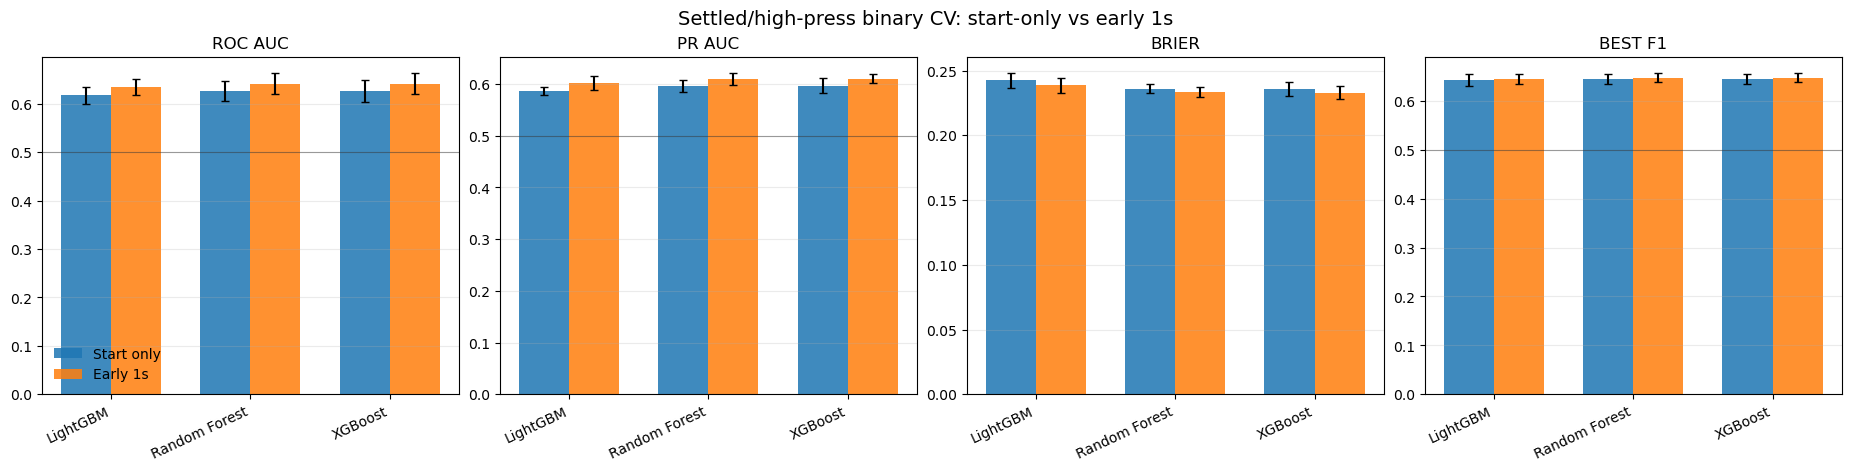

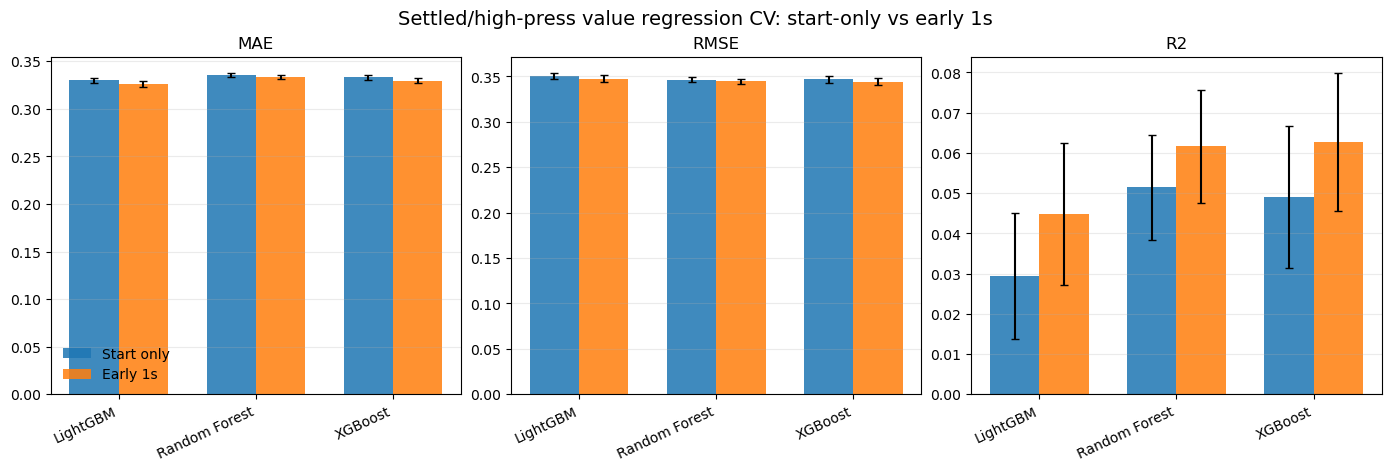

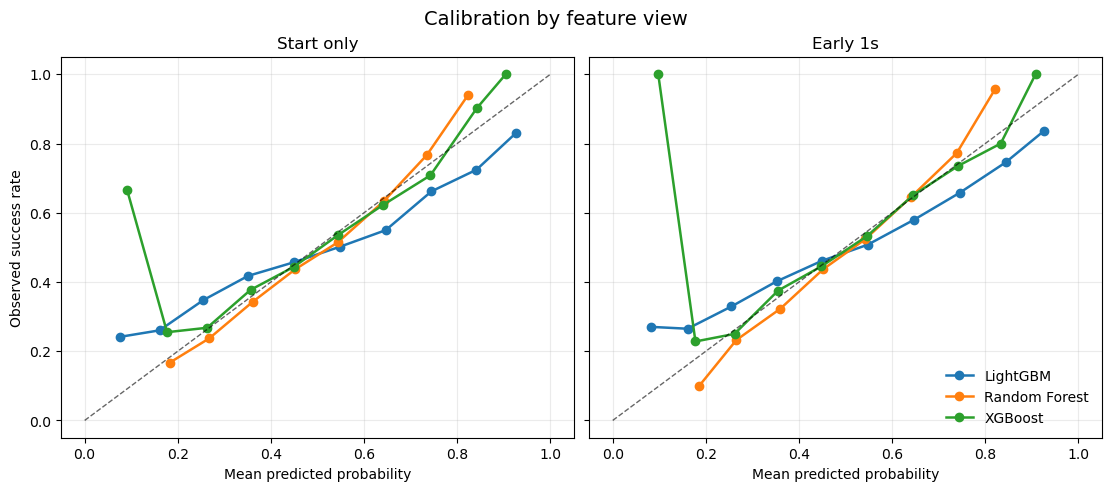

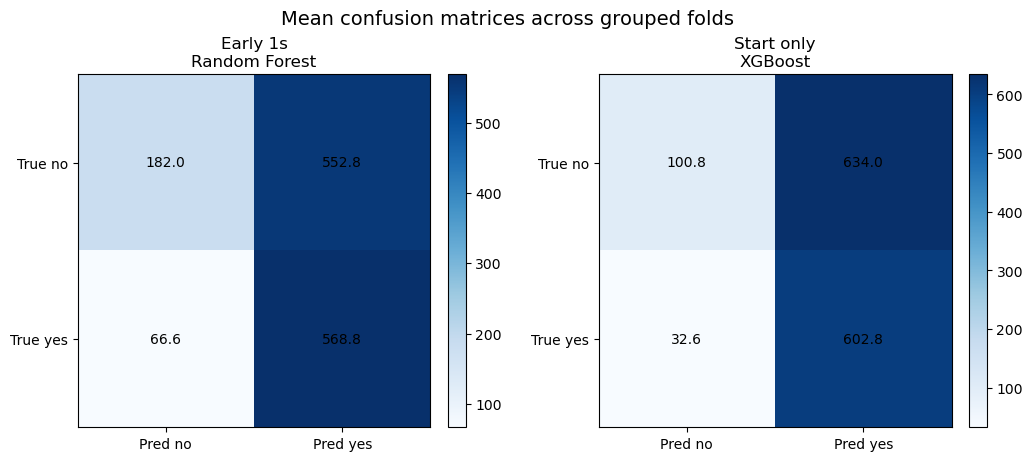

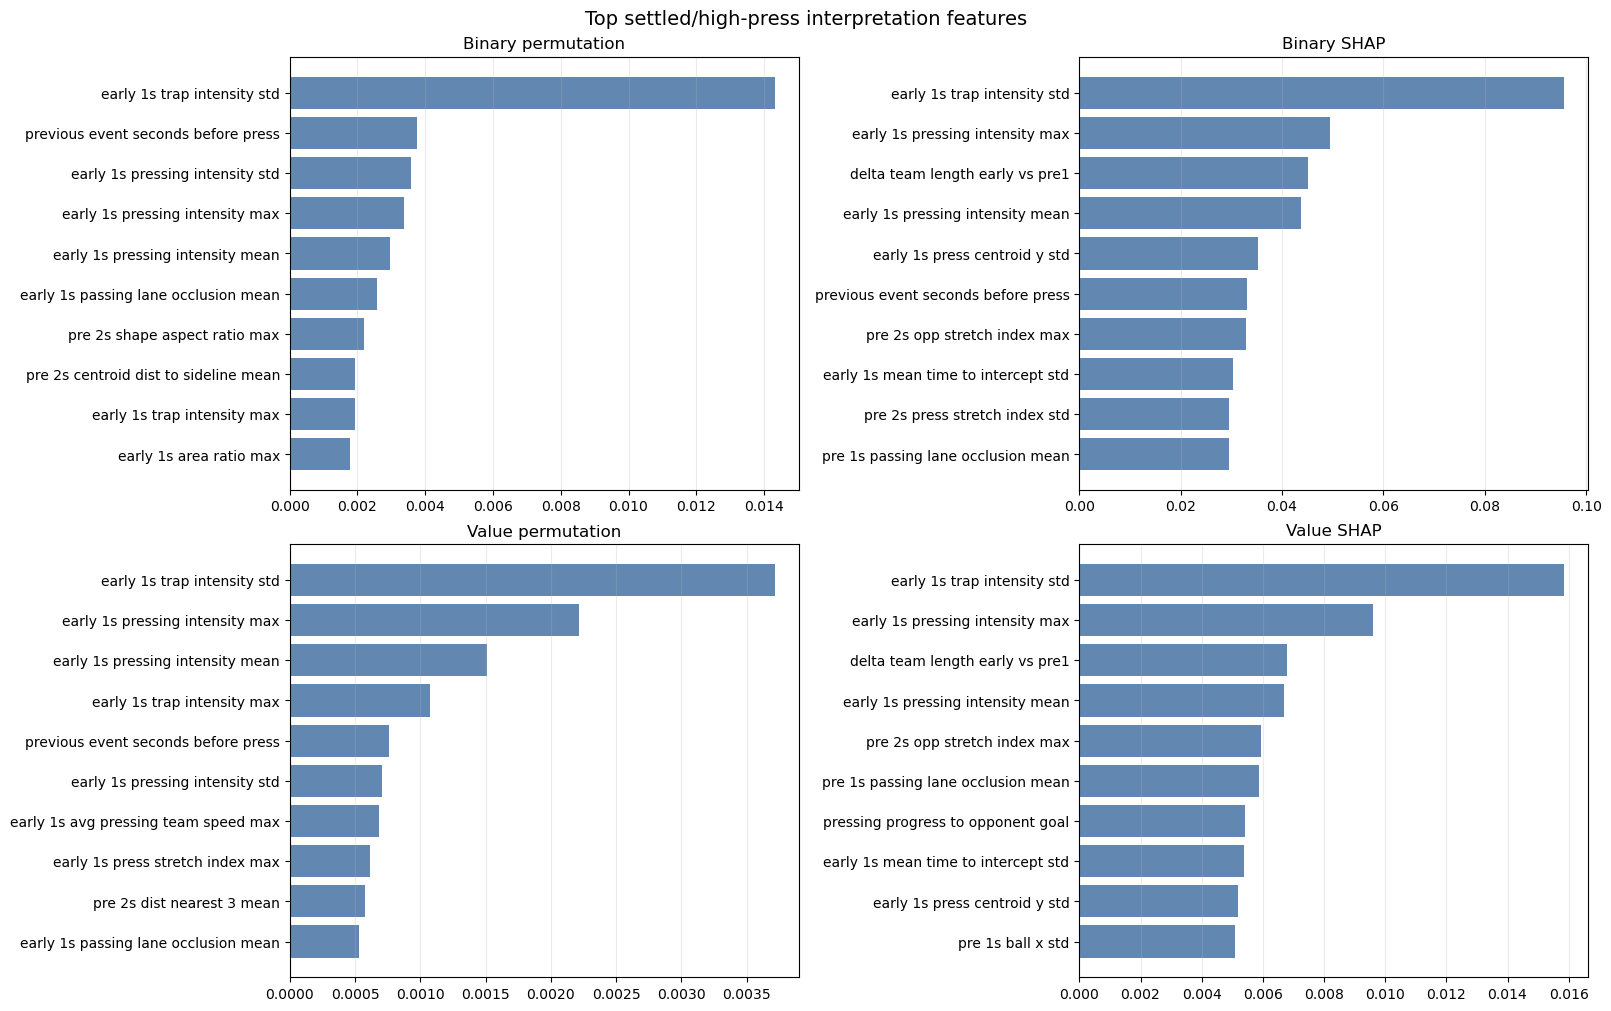

Thesis reporting outputs saved.
Report directory: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_thesis_reporting_outputs

Best binary model by ROC-AUC:
{'model': 'random_forest', 'feature_view': 'early_1s', 'roc_auc_mean': 0.6412829960811981, 'pr_auc_mean': 0.6097537587293246, 'brier_mean': 0.2333504501863204, 'best_f1_mean': 0.647401199508774}

Best regression model by MAE:
{'model': 'lightgbm_regressor', 'feature_view': 'early_1s', 'mae_mean': 0.32582028108964767, 'rmse_mean': 0.34769801716617155, 'r2_mean': 0.04481059400315326}

Binary table


,feature_view,model,n_folds,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,tn_mean,fp_mean,fn_mean,tp_mean
0,Early 1s,LightGBM,5.0,474.0,0.635,0.016,0.602,0.013,0.239,0.006,0.644,0.010,109.2,625.6,36.6,598.8
3,Start only,LightGBM,5.0,348.0,0.617,0.018,0.586,0.008,0.242,0.006,0.643,0.013,85.8,649.0,27.6,607.8
1,Early 1s,Random Forest,5.0,474.0,0.641,0.022,0.610,0.011,0.233,0.004,0.647,0.009,182.0,552.8,66.6,568.8
4,Start only,Random Forest,5.0,348.0,0.626,0.021,0.596,0.012,0.236,0.004,0.645,0.010,104.6,630.2,33.6,601.8
2,Early 1s,XGBoost,5.0,474.0,0.641,0.021,0.610,0.009,0.233,0.005,0.647,0.009,126.4,608.4,40.0,595.4
5,Start only,XGBoost,5.0,348.0,0.627,0.023,0.596,0.015,0.236,0.005,0.644,0.010,100.8,634.0,32.6,602.8



Regression table


,feature_view,model,n_folds,n_features,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
6,Early 1s,LightGBM,5.0,474.0,0.326,0.003,0.348,0.004,0.045,0.018
10,Start only,LightGBM,5.0,348.0,0.330,0.002,0.350,0.003,0.029,0.016
7,Early 1s,Random Forest,5.0,474.0,0.333,0.002,0.345,0.003,0.062,0.014
11,Start only,Random Forest,5.0,348.0,0.336,0.002,0.346,0.003,0.051,0.013
8,Early 1s,Train mean,5.0,474.0,0.353,0.001,0.356,0.001,-0.001,0.001
12,Start only,Train mean,5.0,348.0,0.353,0.001,0.356,0.001,-0.001,0.001
9,Early 1s,XGBoost,5.0,474.0,0.329,0.003,0.344,0.004,0.063,0.017
13,Start only,XGBoost,5.0,348.0,0.333,0.003,0.347,0.004,0.049,0.018



Early 1s minus start-only deltas


,task,feature_view,model,n_folds,n_test_total,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,best_f1_threshold_mean,best_f1_threshold_std,tn_mean,tn_std,fp_mean,fp_std,fn_mean,fn_std,tp_mean,tp_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
14,binary,Early 1s - start only,LightGBM,NaN,NaN,NaN,0.017,NaN,0.015,NaN,-0.004,NaN,0.002,NaN,0.012,NaN,23.4,NaN,-23.4,NaN,9.0,NaN,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,binary,Early 1s - start only,Random Forest,NaN,NaN,NaN,0.015,NaN,0.014,NaN,-0.003,NaN,0.003,NaN,0.041,NaN,77.4,NaN,-77.4,NaN,33.0,NaN,-33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,binary,Early 1s - start only,XGBoost,NaN,NaN,NaN,0.014,NaN,0.014,NaN,-0.003,NaN,0.003,NaN,0.003,NaN,25.6,NaN,-25.6,NaN,7.4,NaN,-7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,regression,Early 1s - start only,LightGBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004,NaN,-0.003,NaN,0.015,NaN
18,regression,Early 1s - start only,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003,NaN,-0.002,NaN,0.010,NaN
19,regression,Early 1s - start only,Train mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,0.000,NaN
20,regression,Early 1s - start only,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004,NaN,-0.003,NaN,0.014,NaN


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# Thesis-ready reporting outputs: tables, calibration, confusion, interpretation
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

THESIS_REPORT_DIR = ARTIFACT_ROOT / "full_season_thesis_reporting_outputs"
THESIS_REPORT_DIR.mkdir(exist_ok=True)

THESIS_BINARY_TABLE_PATH = THESIS_REPORT_DIR / "press_thesis_binary_cv_table.csv"
THESIS_REGRESSION_TABLE_PATH = THESIS_REPORT_DIR / "press_thesis_regression_cv_table.csv"
THESIS_DELTA_TABLE_PATH = THESIS_REPORT_DIR / "press_thesis_start_vs_early_delta_table.csv"
THESIS_REPORT_SUMMARY_PATH = THESIS_REPORT_DIR / "press_thesis_reporting_summary.json"
THESIS_BINARY_PLOT_PATH = THESIS_REPORT_DIR / "press_thesis_binary_cv_metrics.png"
THESIS_REGRESSION_PLOT_PATH = THESIS_REPORT_DIR / "press_thesis_regression_cv_metrics.png"
THESIS_CALIBRATION_PLOT_PATH = THESIS_REPORT_DIR / "press_thesis_calibration_curves.png"
THESIS_CONFUSION_PLOT_PATH = THESIS_REPORT_DIR / "press_thesis_confusion_matrices.png"
THESIS_IMPORTANCE_PLOT_PATH = THESIS_REPORT_DIR / "press_thesis_feature_importance.png"

MODEL_LABELS = {
    "random_forest": "Random Forest",
    "lightgbm": "LightGBM",
    "xgboost": "XGBoost",
    "train_mean_baseline": "Train mean",
    "random_forest_regressor": "Random Forest",
    "lightgbm_regressor": "LightGBM",
    "xgboost_regressor": "XGBoost",
    # Optional sklearn-native HistGradientBoosting fallback labels can be re-added if those models are re-enabled.
}
VIEW_LABELS = {
    "start_only": "Start only",
    "early_1s": "Early 1s",
    "early_1s_minus_start_only": "Early 1s - start only",
}
ACTIVE_REPORT_BINARY_MODELS = ["random_forest", "lightgbm", "xgboost"]


def _round_cols(df, decimals=3):
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(decimals)
    return out


def _display_name(value, mapping):
    return mapping.get(value, value)


def _prepare_thesis_tables(summary_df):
    binary_cols = [
        "feature_view", "model", "n_folds", "n_features",
        "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std",
        "brier_mean", "brier_std", "best_f1_mean", "best_f1_std",
        "tn_mean", "fp_mean", "fn_mean", "tp_mean",
    ]
    regression_cols = [
        "feature_view", "model", "n_folds", "n_features",
        "mae_mean", "mae_std", "rmse_mean", "rmse_std", "r2_mean", "r2_std",
    ]

    binary_table = summary_df[
        summary_df["task"].eq("binary") & summary_df["feature_view"].isin(["start_only", "early_1s"])
    ][[c for c in binary_cols if c in summary_df.columns]].copy()
    regression_table = summary_df[
        summary_df["task"].eq("regression") & summary_df["feature_view"].isin(["start_only", "early_1s"])
    ][[c for c in regression_cols if c in summary_df.columns]].copy()
    delta_table = summary_df[summary_df["feature_view"].eq("early_1s_minus_start_only")].copy()

    for table in [binary_table, regression_table, delta_table]:
        if not table.empty:
            table["feature_view"] = table["feature_view"].map(lambda x: _display_name(x, VIEW_LABELS))
            table["model"] = table["model"].map(lambda x: _display_name(x, MODEL_LABELS))

    binary_table = _round_cols(binary_table.sort_values(["model", "feature_view"])) if not binary_table.empty else binary_table
    regression_table = _round_cols(regression_table.sort_values(["model", "feature_view"])) if not regression_table.empty else regression_table
    delta_table = _round_cols(delta_table.sort_values(["task", "model"])) if not delta_table.empty else delta_table
    return binary_table, regression_table, delta_table


def _plot_grouped_metric(summary_df, task, metrics, output_path, title):
    data = summary_df[
        summary_df["task"].eq(task) & summary_df["feature_view"].isin(["start_only", "early_1s"])
    ].copy()
    if data.empty:
        print(f"Skipping {title}: no rows available.")
        return
    models = [m for m in data["model"].dropna().unique().tolist() if m != "train_mean_baseline"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6 * len(metrics), 4.6), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        x = np.arange(len(models))
        width = 0.36
        for offset, view in [(-width / 2, "start_only"), (width / 2, "early_1s")]:
            vals = []
            errs = []
            for model in models:
                row = data[(data["model"].eq(model)) & (data["feature_view"].eq(view))]
                vals.append(float(row[f"{metric}_mean"].iloc[0]) if not row.empty and f"{metric}_mean" in row.columns else np.nan)
                std_col = f"{metric}_std"
                errs.append(float(row[std_col].iloc[0]) if not row.empty and std_col in row.columns else 0.0)
            ax.bar(x + offset, vals, width, yerr=errs, capsize=3, label=_display_name(view, VIEW_LABELS), alpha=0.86)
        ax.set_title(metric.replace("_", " ").upper())
        ax.set_xticks(x)
        ax.set_xticklabels([_display_name(m, MODEL_LABELS) for m in models], rotation=25, ha="right")
        ax.grid(axis="y", alpha=0.25)
        if metric in {"roc_auc", "pr_auc", "best_f1", "r2"}:
            ax.axhline(0.5 if metric != "r2" else 0.0, color="black", linewidth=0.8, alpha=0.35)
    axes[0].legend(frameon=False)
    fig.suptitle(title, fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


def _plot_calibration(reliability_df, output_path):
    rel = reliability_df.copy()
    rel = rel[rel["model"].isin(ACTIVE_REPORT_BINARY_MODELS)]
    if rel.empty:
        print("Skipping calibration plot: no active model reliability rows available.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True, constrained_layout=True)
    for ax, view in zip(axes, ["start_only", "early_1s"]):
        view_df = rel[rel["feature_view"].eq(view)]
        for model, group in view_df.groupby("model"):
            group = group.sort_values("mean_predicted_probability")
            ax.plot(
                group["mean_predicted_probability"],
                group["observed_success_rate"],
                marker="o",
                linewidth=1.8,
                label=_display_name(model, MODEL_LABELS),
            )
        ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.0, alpha=0.6)
        ax.set_title(_display_name(view, VIEW_LABELS))
        ax.set_xlabel("Mean predicted probability")
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Observed success rate")
    axes[1].legend(frameon=False, loc="lower right")
    fig.suptitle("Calibration by feature view", fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


def _plot_best_confusion_matrices(summary_df, output_path):
    binary = summary_df[
        summary_df["task"].eq("binary") & summary_df["feature_view"].isin(["start_only", "early_1s"])
    ].copy()
    if binary.empty:
        print("Skipping confusion matrices: no binary summary rows available.")
        return
    best_rows = []
    for view, group in binary.groupby("feature_view"):
        best_rows.append(group.sort_values("roc_auc_mean", ascending=False).iloc[0])

    fig, axes = plt.subplots(1, len(best_rows), figsize=(5.2 * len(best_rows), 4.5), constrained_layout=True)
    if len(best_rows) == 1:
        axes = [axes]
    for ax, row in zip(axes, best_rows):
        matrix = np.array([[row["tn_mean"], row["fp_mean"]], [row["fn_mean"], row["tp_mean"]]], dtype=float)
        im = ax.imshow(matrix, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred no", "Pred yes"])
        ax.set_yticklabels(["True no", "True yes"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center", color="black")
        ax.set_title(f"{_display_name(row['feature_view'], VIEW_LABELS)}\n{_display_name(row['model'], MODEL_LABELS)}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle("Mean confusion matrices across grouped folds", fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


def _plot_interpretation_importance(permutation_df, shap_df, output_path, top_n=10):
    specs = [
        (permutation_df, "binary_press_success_any", "importance_mean", "Binary permutation"),
        (shap_df, "binary_press_success_any", "mean_abs_shap", "Binary SHAP"),
        (permutation_df, "value_press_value_score", "importance_mean", "Value permutation"),
        (shap_df, "value_press_value_score", "mean_abs_shap", "Value SHAP"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    for ax, (source, task, value_col, title) in zip(axes.ravel(), specs):
        data = source[source["task"].eq(task)].sort_values(value_col, ascending=False).head(top_n).copy()
        data = data.sort_values(value_col, ascending=True)
        labels = data["feature"].str.replace("_", " ", regex=False)
        ax.barh(labels, data[value_col], color="#4C78A8", alpha=0.88)
        ax.set_title(title)
        ax.grid(axis="x", alpha=0.25)
    fig.suptitle("Top settled/high-press interpretation features", fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


cv_summary_report_df = pd.read_parquet(START_VS_EARLY_SUMMARY_PATH)
cv_reliability_report_df = pd.read_parquet(START_VS_EARLY_RELIABILITY_PATH)
permutation_report_df = pd.read_parquet(MODEL_PERMUTATION_IMPORTANCE_PATH)
shap_report_df = pd.read_parquet(MODEL_SHAP_IMPORTANCE_PATH)

binary_report_table, regression_report_table, delta_report_table = _prepare_thesis_tables(cv_summary_report_df)
binary_report_table.to_csv(THESIS_BINARY_TABLE_PATH, index=False)
regression_report_table.to_csv(THESIS_REGRESSION_TABLE_PATH, index=False)
delta_report_table.to_csv(THESIS_DELTA_TABLE_PATH, index=False)

_plot_grouped_metric(
    cv_summary_report_df,
    task="binary",
    metrics=["roc_auc", "pr_auc", "brier", "best_f1"],
    output_path=THESIS_BINARY_PLOT_PATH,
    title="Settled/high-press binary CV: start-only vs early 1s",
)
_plot_grouped_metric(
    cv_summary_report_df,
    task="regression",
    metrics=["mae", "rmse", "r2"],
    output_path=THESIS_REGRESSION_PLOT_PATH,
    title="Settled/high-press value regression CV: start-only vs early 1s",
)
_plot_calibration(cv_reliability_report_df, THESIS_CALIBRATION_PLOT_PATH)
_plot_best_confusion_matrices(cv_summary_report_df, THESIS_CONFUSION_PLOT_PATH)
_plot_interpretation_importance(permutation_report_df, shap_report_df, THESIS_IMPORTANCE_PLOT_PATH)

binary_no_delta = cv_summary_report_df[
    cv_summary_report_df["task"].eq("binary") & cv_summary_report_df["feature_view"].isin(["start_only", "early_1s"])
]
best_binary = binary_no_delta.sort_values("roc_auc_mean", ascending=False).iloc[0]
regression_no_delta = cv_summary_report_df[
    cv_summary_report_df["task"].eq("regression") & cv_summary_report_df["feature_view"].isin(["start_only", "early_1s"])
]
best_regression = regression_no_delta.sort_values("mae_mean", ascending=True).iloc[0]

delta_rows = cv_summary_report_df[cv_summary_report_df["feature_view"].eq("early_1s_minus_start_only")]
report_summary = {
    "scope": "settled_high_press",
    "n_rows": int(pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH).shape[0]),
    "feature_views": {"start_only": 315, "early_1s": 430},
    "active_model_set": ["Random Forest", "LightGBM", "XGBoost"],
    "fallback_model_note": "Sklearn-native gradient boosting blocks are retained only as commented fallback code.",
    "best_binary_by_roc_auc": {
        "model": str(best_binary["model"]),
        "feature_view": str(best_binary["feature_view"]),
        "roc_auc_mean": float(best_binary["roc_auc_mean"]),
        "pr_auc_mean": float(best_binary["pr_auc_mean"]),
        "brier_mean": float(best_binary["brier_mean"]),
        "best_f1_mean": float(best_binary["best_f1_mean"]),
    },
    "best_regression_by_mae": {
        "model": str(best_regression["model"]),
        "feature_view": str(best_regression["feature_view"]),
        "mae_mean": float(best_regression["mae_mean"]),
        "rmse_mean": float(best_regression["rmse_mean"]),
        "r2_mean": float(best_regression["r2_mean"]),
    },
    "early_1s_minus_start_only_deltas": delta_rows.to_dict(orient="records"),
    "output_paths": {
        "binary_table": str(THESIS_BINARY_TABLE_PATH),
        "regression_table": str(THESIS_REGRESSION_TABLE_PATH),
        "delta_table": str(THESIS_DELTA_TABLE_PATH),
        "binary_plot": str(THESIS_BINARY_PLOT_PATH),
        "regression_plot": str(THESIS_REGRESSION_PLOT_PATH),
        "calibration_plot": str(THESIS_CALIBRATION_PLOT_PATH),
        "confusion_plot": str(THESIS_CONFUSION_PLOT_PATH),
        "importance_plot": str(THESIS_IMPORTANCE_PLOT_PATH),
    },
}
with open(THESIS_REPORT_SUMMARY_PATH, "w") as fh:
    json.dump(report_summary, fh, indent=2)

print("Thesis reporting outputs saved.")
print(f"Report directory: {THESIS_REPORT_DIR}")
print("\nBest binary model by ROC-AUC:")
print(report_summary["best_binary_by_roc_auc"])
print("\nBest regression model by MAE:")
print(report_summary["best_regression_by_mae"])
print("\nBinary table")
display(binary_report_table)
print("\nRegression table")
display(regression_report_table)
print("\nEarly 1s minus start-only deltas")
display(delta_report_table)

Team holdout start_only: team_id=1000


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Team holdout start_only: team_id=1943


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Team holdout start_only: team_id=239


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Team holdout early_1s: team_id=569


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Temporal split early_1s: train_matches=134, test_matches=58


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


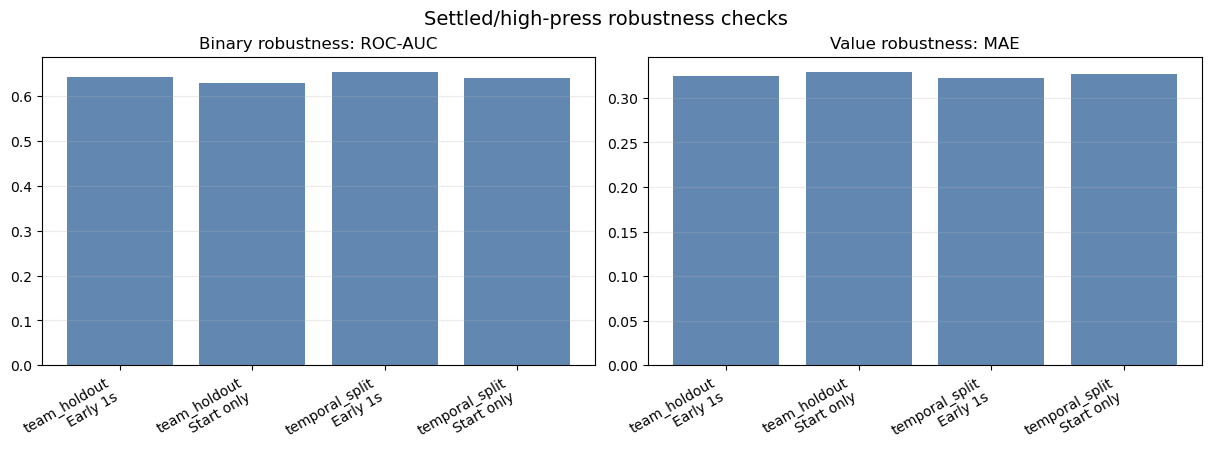


Robustness checks saved.
Metrics rows: 52
Prediction rows: 35,272
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_summary.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_predictions.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_summary.png

Robustness summary


,split_family,task,feature_view,model,n_splits,n_test_total,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,team_holdout,binary,early_1s,random_forest,12,6851,474,0.642,0.029,0.609,0.044,0.233,0.005,0.652,0.023,NaN,NaN,NaN,NaN,NaN,NaN
1,team_holdout,binary,start_only,random_forest,12,6851,348,0.629,0.033,0.598,0.045,0.236,0.006,0.646,0.027,NaN,NaN,NaN,NaN,NaN,NaN
2,team_holdout,regression,early_1s,lightgbm_regressor,12,6851,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.324,0.006,0.346,0.006,0.052,0.026
3,team_holdout,regression,start_only,lightgbm_regressor,12,6851,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.329,0.006,0.349,0.006,0.032,0.028
4,temporal_split,binary,early_1s,random_forest,1,1967,474,0.655,0.000,0.628,0.000,0.231,0.000,0.635,0.000,NaN,NaN,NaN,NaN,NaN,NaN
5,temporal_split,binary,start_only,random_forest,1,1967,348,0.641,0.000,0.613,0.000,0.234,0.000,0.632,0.000,NaN,NaN,NaN,NaN,NaN,NaN
6,temporal_split,regression,early_1s,lightgbm_regressor,1,1967,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.322,0.000,0.342,0.000,0.063,0.000
7,temporal_split,regression,start_only,lightgbm_regressor,1,1967,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.327,0.000,0.347,0.000,0.038,0.000


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# Robustness checks: team holdout and temporal split
# ══════════════════════════════════════════════════════════════════════════════

import re

ROBUSTNESS_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_robustness_results.json"
ROBUSTNESS_PREDICTIONS_PATH = ARTIFACT_ROOT / "full_season_press_robustness_predictions.parquet"
ROBUSTNESS_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_press_robustness_summary.parquet"
ROBUSTNESS_PLOT_PATH = ARTIFACT_ROOT / "full_season_press_robustness_summary.png"


def _match_date_from_name(match_name):
    match = re.match(r"(\d{4}-\d{2}-\d{2})", str(match_name))
    return pd.to_datetime(match.group(1)) if match else pd.NaT


def _make_robust_binary_model(feature_cols):
    return Pipeline(steps=[
        ("prep", _fresh_numeric_preprocessor(feature_cols)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=8,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ])


def _make_robust_regression_model(feature_cols):
    if not LIGHTGBM_CV_AVAILABLE:
        raise ImportError(f"LightGBM is required for robustness regression: {globals().get('LIGHTGBM_CV_IMPORT_ERROR', 'not available')}")
    return Pipeline(steps=[
        ("prep", _fresh_numeric_preprocessor(feature_cols)),
        ("model", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.04,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="regression",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )),
    ])
    # Optional sklearn-native fallback, intentionally inactive:
    # return Pipeline(steps=[
    #     ("prep", _fresh_numeric_preprocessor(feature_cols)),
    #     ("model", HistGradientBoostingRegressor(
    #         learning_rate=0.04,
    #         max_iter=200,
    #         l2_regularization=0.05,
    #         random_state=42,
    #     )),
    # ])


def _evaluate_robustness_split(df, feature_view, feature_cols, split_family, split_name, train_mask, test_mask):
    train_idx = np.flatnonzero(train_mask.to_numpy())
    test_idx = np.flatnonzero(test_mask.to_numpy())
    if len(train_idx) == 0 or len(test_idx) == 0:
        return [], []

    y_binary_train = df.iloc[train_idx]["press_success_any"].astype(int)
    y_binary_test = df.iloc[test_idx]["press_success_any"].astype(int)
    y_value_train = df.iloc[train_idx]["press_value_score"].astype(float)
    y_value_test = df.iloc[test_idx]["press_value_score"].astype(float)

    if y_binary_train.nunique() < 2 or y_binary_test.nunique() < 2:
        return [], []

    X_train = df.iloc[train_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    X_test = df.iloc[test_idx][feature_cols].replace([np.inf, -np.inf], np.nan)
    train_matches = sorted(df.iloc[train_idx]["match_name"].astype(str).unique().tolist())
    test_matches = sorted(df.iloc[test_idx]["match_name"].astype(str).unique().tolist())

    metric_rows = []
    prediction_rows = []

    binary_model = _make_robust_binary_model(feature_cols)
    binary_model.fit(X_train, y_binary_train)
    y_score = binary_model.predict_proba(X_test)[:, 1]
    binary_metrics = _cv_binary_metrics(y_binary_test.values, y_score)
    metric_rows.append({
        "task": "binary",
        "feature_view": feature_view,
        "model": "random_forest",
        "split_family": split_family,
        "split_name": split_name,
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "n_features": int(len(feature_cols)),
        "n_train_matches": int(len(train_matches)),
        "n_test_matches": int(len(test_matches)),
        "train_matches": train_matches,
        "test_matches": test_matches,
        **binary_metrics,
    })
    pred = df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in df.columns]].copy()
    pred["task"] = "binary"
    pred["feature_view"] = feature_view
    pred["model"] = "random_forest"
    pred["split_family"] = split_family
    pred["split_name"] = split_name
    pred["y_true"] = y_binary_test.values.astype(float)
    pred["y_score"] = y_score.astype(float)
    prediction_rows.append(pred)

    regression_model = _make_robust_regression_model(feature_cols)
    regression_model.fit(X_train, y_value_train)
    y_pred = regression_model.predict(X_test)
    regression_metrics = _cv_regression_metrics(y_value_test.values, y_pred)
    metric_rows.append({
        "task": "regression",
        "feature_view": feature_view,
        "model": "lightgbm_regressor",
        "split_family": split_family,
        "split_name": split_name,
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "n_features": int(len(feature_cols)),
        "n_train_matches": int(len(train_matches)),
        "n_test_matches": int(len(test_matches)),
        "train_matches": train_matches,
        "test_matches": test_matches,
        **regression_metrics,
    })
    pred = df.iloc[test_idx][[c for c in IDENTIFIER_COLUMNS if c in df.columns]].copy()
    pred["task"] = "regression"
    pred["feature_view"] = feature_view
    pred["model"] = "lightgbm_regressor"
    pred["split_family"] = split_family
    pred["split_name"] = split_name
    pred["y_true"] = y_value_test.values.astype(float)
    pred["y_score"] = y_pred.astype(float)
    prediction_rows.append(pred)

    return metric_rows, prediction_rows


def _summarize_robustness(metrics_df):
    metric_cols = ["roc_auc", "pr_auc", "brier", "best_f1", "mae", "rmse", "r2"]
    rows = []
    for keys, group in metrics_df.groupby(["split_family", "task", "feature_view", "model"], dropna=False):
        split_family, task, feature_view, model = keys
        row = {
            "split_family": split_family,
            "task": task,
            "feature_view": feature_view,
            "model": model,
            "n_splits": int(group["split_name"].nunique()),
            "n_test_total": int(group["n_test"].sum()),
            "n_features": int(group["n_features"].iloc[0]),
        }
        for col in metric_cols:
            if col in group.columns and group[col].notna().any():
                row[f"{col}_mean"] = float(group[col].mean())
                row[f"{col}_std"] = float(group[col].std(ddof=0))
        rows.append(row)
    return pd.DataFrame(rows)


def _plot_robustness_summary(summary_df, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    binary = summary_df[summary_df["task"].eq("binary")].copy()
    regression = summary_df[summary_df["task"].eq("regression")].copy()

    for ax, data, metric, title in [
        (axes[0], binary, "roc_auc_mean", "Binary robustness: ROC-AUC"),
        (axes[1], regression, "mae_mean", "Value robustness: MAE"),
    ]:
        if data.empty or metric not in data.columns:
            ax.set_axis_off()
            continue
        labels = data["split_family"] + "\n" + data["feature_view"].map(lambda x: VIEW_LABELS.get(x, x))
        ax.bar(np.arange(len(data)), data[metric], color="#4C78A8", alpha=0.88)
        ax.set_xticks(np.arange(len(data)))
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle("Settled/high-press robustness checks", fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


def build_robustness_checks(df):
    df = df.copy()
    df["match_date"] = df["match_name"].map(_match_date_from_name)
    start_cols, _ = get_clean_model_feature_columns(df, include_early_1s=False)
    early_cols, _ = get_clean_model_feature_columns(df, include_early_1s=True)
    feature_views = {"start_only": start_cols, "early_1s": early_cols}

    metric_rows = []
    prediction_frames = []

    for feature_view, feature_cols in feature_views.items():
        eligible_teams = []
        for team_id, group in df.groupby("team_id"):
            if len(group) >= 20 and group["press_success_any"].nunique() == 2:
                train = df[df["team_id"].ne(team_id)]
                if train["press_success_any"].nunique() == 2:
                    eligible_teams.append(team_id)

        for team_id in eligible_teams:
            print(f"Team holdout {feature_view}: team_id={team_id}")
            rows, preds = _evaluate_robustness_split(
                df,
                feature_view,
                feature_cols,
                split_family="team_holdout",
                split_name=f"team_{team_id}",
                train_mask=df["team_id"].ne(team_id),
                test_mask=df["team_id"].eq(team_id),
            )
            metric_rows.extend(rows)
            prediction_frames.extend(preds)

        ordered_matches = df[["match_name", "match_date"]].drop_duplicates().sort_values(["match_date", "match_name"])
        split_at = max(1, int(np.floor(len(ordered_matches) * 0.70)))
        train_matches = set(ordered_matches["match_name"].iloc[:split_at])
        test_matches = set(ordered_matches["match_name"].iloc[split_at:])
        print(f"Temporal split {feature_view}: train_matches={len(train_matches)}, test_matches={len(test_matches)}")
        rows, preds = _evaluate_robustness_split(
            df,
            feature_view,
            feature_cols,
            split_family="temporal_split",
            split_name="early_matches_train_late_matches_test",
            train_mask=df["match_name"].isin(train_matches),
            test_mask=df["match_name"].isin(test_matches),
        )
        metric_rows.extend(rows)
        prediction_frames.extend(preds)

    metrics_df = pd.DataFrame(metric_rows)
    predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
    summary_df = _summarize_robustness(metrics_df) if not metrics_df.empty else pd.DataFrame()

    metrics_df.to_parquet(ROBUSTNESS_SUMMARY_PATH, index=False)
    predictions_df.to_parquet(ROBUSTNESS_PREDICTIONS_PATH, index=False)
    payload = {
        "scope": "settled_high_press",
        "n_rows": int(len(df)),
        "n_matches": int(df["match_name"].nunique()),
        "n_teams": int(df["team_id"].nunique()),
        "team_holdout_min_rows": 20,
        "temporal_policy": "train earliest 70% of matches by date; test latest 30%",
        "feature_views": {"start_only": len(start_cols), "early_1s": len(early_cols)},
        "metrics": metrics_df.to_dict(orient="records"),
        "summary": summary_df.to_dict(orient="records"),
        "output_paths": {
            "metrics": str(ROBUSTNESS_SUMMARY_PATH),
            "predictions": str(ROBUSTNESS_PREDICTIONS_PATH),
            "plot": str(ROBUSTNESS_PLOT_PATH),
        },
    }
    with open(ROBUSTNESS_RESULTS_PATH, "w") as fh:
        json.dump(payload, fh, indent=2)

    _plot_robustness_summary(summary_df, ROBUSTNESS_PLOT_PATH)
    return metrics_df, summary_df, predictions_df, payload


robustness_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
robustness_metrics_df, robustness_summary_df, robustness_predictions_df, robustness_results = build_robustness_checks(robustness_df)

print("\nRobustness checks saved.")
print(f"Metrics rows: {len(robustness_metrics_df):,}")
print(f"Prediction rows: {len(robustness_predictions_df):,}")
print(f"Saved: {ROBUSTNESS_RESULTS_PATH}")
print(f"Saved: {ROBUSTNESS_SUMMARY_PATH}")
print(f"Saved: {ROBUSTNESS_PREDICTIONS_PATH}")
print(f"Saved: {ROBUSTNESS_PLOT_PATH}")

print("\nRobustness summary")
display(_round_cols(robustness_summary_df, decimals=3))

In [43]:
# Robustness artifact cleanup: save split-level and aggregate tables explicitly

ROBUSTNESS_SPLIT_METRICS_PATH = ARTIFACT_ROOT / "full_season_press_robustness_split_metrics.parquet"
ROBUSTNESS_AGGREGATE_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_press_robustness_aggregate_summary.parquet"

if "robustness_metrics_df" not in globals() or "robustness_results" not in globals():
    with open(ROBUSTNESS_RESULTS_PATH) as fh:
        robustness_results = json.load(fh)
    robustness_metrics_df = pd.DataFrame(robustness_results["metrics"])

robustness_aggregate_summary_df = pd.DataFrame(robustness_results["summary"])
robustness_metrics_df.to_parquet(ROBUSTNESS_SPLIT_METRICS_PATH, index=False)
robustness_aggregate_summary_df.to_parquet(ROBUSTNESS_AGGREGATE_SUMMARY_PATH, index=False)
robustness_aggregate_summary_df.to_parquet(ROBUSTNESS_SUMMARY_PATH, index=False)

print("Robustness tables saved with explicit meanings.")
print(f"Split-level metrics: {ROBUSTNESS_SPLIT_METRICS_PATH}")
print(f"Aggregate summary: {ROBUSTNESS_AGGREGATE_SUMMARY_PATH}")
print(f"Compatibility summary path: {ROBUSTNESS_SUMMARY_PATH}")
display(_round_cols(robustness_aggregate_summary_df, decimals=3))

Robustness tables saved with explicit meanings.
Split-level metrics: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_split_metrics.parquet
Aggregate summary: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_aggregate_summary.parquet
Compatibility summary path: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_robustness_summary.parquet


,split_family,task,feature_view,model,n_splits,n_test_total,n_features,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,best_f1_mean,best_f1_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,team_holdout,binary,early_1s,random_forest,12,6851,474,0.642,0.029,0.609,0.044,0.233,0.005,0.652,0.023,NaN,NaN,NaN,NaN,NaN,NaN
1,team_holdout,binary,start_only,random_forest,12,6851,348,0.629,0.033,0.598,0.045,0.236,0.006,0.646,0.027,NaN,NaN,NaN,NaN,NaN,NaN
2,team_holdout,regression,early_1s,lightgbm_regressor,12,6851,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.324,0.006,0.346,0.006,0.052,0.026
3,team_holdout,regression,start_only,lightgbm_regressor,12,6851,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.329,0.006,0.349,0.006,0.032,0.028
4,temporal_split,binary,early_1s,random_forest,1,1967,474,0.655,0.000,0.628,0.000,0.231,0.000,0.635,0.000,NaN,NaN,NaN,NaN,NaN,NaN
5,temporal_split,binary,start_only,random_forest,1,1967,348,0.641,0.000,0.613,0.000,0.234,0.000,0.632,0.000,NaN,NaN,NaN,NaN,NaN,NaN
6,temporal_split,regression,early_1s,lightgbm_regressor,1,1967,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.322,0.000,0.342,0.000,0.063,0.000
7,temporal_split,regression,start_only,lightgbm_regressor,1,1967,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.327,0.000,0.347,0.000,0.038,0.000


Feature stability start_only fold 1/5: features=348, test_matches=39
Feature stability start_only fold 2/5: features=348, test_matches=38
Feature stability start_only fold 3/5: features=348, test_matches=38
Feature stability start_only fold 4/5: features=348, test_matches=38
Feature stability start_only fold 5/5: features=348, test_matches=39


Exception ignored in: <function ResourceTracker.__del__ at 0x111871c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105145c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108a71c60>
Traceback (most recent call last

Feature stability early_1s fold 1/5: features=474, test_matches=39
Feature stability early_1s fold 2/5: features=474, test_matches=38
Feature stability early_1s fold 3/5: features=474, test_matches=38
Feature stability early_1s fold 4/5: features=474, test_matches=38
Feature stability early_1s fold 5/5: features=474, test_matches=39


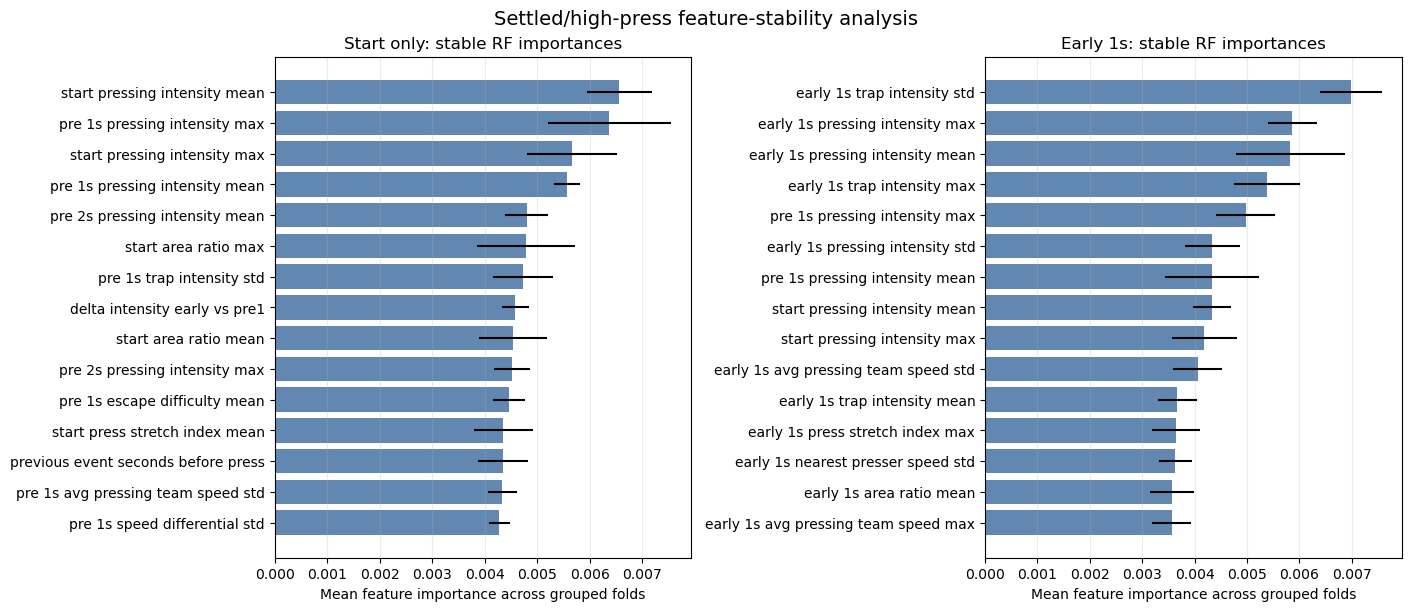


Feature-stability analysis saved.
Fold-importance rows: 4,110
Summary rows: 822
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_feature_stability_results.json
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_feature_stability_fold_importance.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_feature_stability_summary.parquet
Saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_feature_stability_top_features.png

Top stable features by view


,feature_view,feature,mean_importance,std_importance,mean_rank,std_rank,top_fold_share,n_folds,feature_window,feature_base,feature_family,stability_score
0,early_1s,early_1s_trap_intensity_std,0.0070,0.0006,1.0,0.0000,1.0,5,early_1s,trap_intensity_std,other,0.0070
1,early_1s,early_1s_pressing_intensity_max,0.0059,0.0005,2.8,0.8367,1.0,5,early_1s,pressing_intensity_max,pressure,0.0032
2,early_1s,early_1s_pressing_intensity_mean,0.0058,0.0010,3.4,2.1909,1.0,5,early_1s,pressing_intensity_mean,pressure,0.0018
3,early_1s,early_1s_trap_intensity_max,0.0054,0.0006,4.4,1.3416,1.0,5,early_1s,trap_intensity_max,other,0.0023
4,early_1s,pre_1s_pressing_intensity_max,0.0050,0.0006,5.2,1.3038,1.0,5,pre_1s,pressing_intensity_max,pressure,0.0022
5,early_1s,early_1s_pressing_intensity_std,0.0043,0.0005,8.8,3.5637,1.0,5,early_1s,pressing_intensity_std,pressure,0.0010
6,early_1s,pre_1s_pressing_intensity_mean,0.0043,0.0009,13.6,13.2778,0.8,5,pre_1s,pressing_intensity_mean,pressure,0.0002
7,early_1s,start_pressing_intensity_mean,0.0043,0.0004,8.2,1.9235,1.0,5,start,pressing_intensity_mean,pressure,0.0015
8,early_1s,start_pressing_intensity_max,0.0042,0.0006,10.6,5.2249,1.0,5,start,pressing_intensity_max,pressure,0.0007
9,early_1s,early_1s_avg_pressing_team_speed_std,0.0041,0.0005,10.4,4.6152,1.0,5,early_1s,avg_pressing_team_speed_std,pressure,0.0007


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature-stability analysis: grouped folds for thesis interpretation
# ══════════════════════════════════════════════════════════════════════════════

FEATURE_STABILITY_RESULTS_PATH = ARTIFACT_ROOT / "full_season_press_feature_stability_results.json"
FEATURE_STABILITY_FOLD_IMPORTANCE_PATH = ARTIFACT_ROOT / "full_season_press_feature_stability_fold_importance.parquet"
FEATURE_STABILITY_SUMMARY_PATH = ARTIFACT_ROOT / "full_season_press_feature_stability_summary.parquet"
FEATURE_STABILITY_PLOT_PATH = ARTIFACT_ROOT / "full_season_press_feature_stability_top_features.png"


def _feature_window(feature_name):
    for window_name in ADVANCED_FEATURE_WINDOWS:
        prefix = f"{window_name}_"
        if str(feature_name).startswith(prefix):
            return window_name
    return "other"


def _feature_base_name(feature_name):
    feature_name = str(feature_name)
    window = _feature_window(feature_name)
    prefix = f"{window}_"
    return feature_name[len(prefix):] if window != "other" and feature_name.startswith(prefix) else feature_name


def _feature_family(feature_name):
    base = _feature_base_name(feature_name)
    family_rules = {
        "pressure": ["pressure", "press", "closing", "distance_nearest", "nearest"],
        "ball_location": ["ball_x", "ball_y", "sideline", "goal_line", "progress"],
        "team_shape": ["team_", "stretch", "width", "length", "area", "compact"],
        "opponent_shape": ["opponent_", "escape", "lane", "overload"],
        "motion": ["speed", "velocity", "acceleration", "direction"],
        "context": ["previous_event", "restart", "goalkeeper", "height_zone"],
    }
    for family, tokens in family_rules.items():
        if any(token in base for token in tokens):
            return family
    return "other"


def _build_feature_stability_model(feature_cols):
    return Pipeline(steps=[
        ("prep", _fresh_numeric_preprocessor(feature_cols)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=8,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ])


def _fold_feature_importance(model, feature_cols):
    estimator = model.named_steps["model"]
    importances = getattr(estimator, "feature_importances_", None)
    if importances is None:
        raise ValueError("The fitted model does not expose feature_importances_.")
    return pd.DataFrame({
        "feature": feature_cols,
        "importance": importances.astype(float),
    }).sort_values("importance", ascending=False).reset_index(drop=True)


def _summarize_feature_stability(fold_importance_df, top_rank_cutoff=25):
    ranked = fold_importance_df.copy()
    ranked["rank"] = ranked.groupby(["feature_view", "fold"])["importance"].rank(method="first", ascending=False)
    ranked["is_top_feature"] = ranked["rank"].le(top_rank_cutoff)

    summary = (
        ranked.groupby(["feature_view", "feature"], as_index=False)
        .agg(
            mean_importance=("importance", "mean"),
            std_importance=("importance", "std"),
            mean_rank=("rank", "mean"),
            std_rank=("rank", "std"),
            top_fold_share=("is_top_feature", "mean"),
            n_folds=("fold", "nunique"),
        )
    )
    summary["std_importance"] = summary["std_importance"].fillna(0.0)
    summary["std_rank"] = summary["std_rank"].fillna(0.0)
    summary["feature_window"] = summary["feature"].map(_feature_window)
    summary["feature_base"] = summary["feature"].map(_feature_base_name)
    summary["feature_family"] = summary["feature"].map(_feature_family)
    summary["stability_score"] = summary["mean_importance"] * summary["top_fold_share"] / (1.0 + summary["std_rank"].fillna(0.0))
    return summary.sort_values(["feature_view", "mean_importance"], ascending=[True, False]).reset_index(drop=True)


def _plot_feature_stability(summary_df, output_path, top_n=15):
    views = [view for view in ["start_only", "early_1s"] if view in set(summary_df["feature_view"])]
    if not views:
        return

    fig, axes = plt.subplots(1, len(views), figsize=(7 * len(views), 6), constrained_layout=True)
    if len(views) == 1:
        axes = [axes]

    for ax, view in zip(axes, views):
        data = summary_df[summary_df["feature_view"].eq(view)].nlargest(top_n, "mean_importance").copy()
        data = data.sort_values("mean_importance", ascending=True)
        labels = data["feature"].str.replace("_", " ", regex=False)
        ax.barh(labels, data["mean_importance"], xerr=data["std_importance"], color="#4C78A8", alpha=0.88)
        ax.set_title(f"{VIEW_LABELS.get(view, view)}: stable RF importances")
        ax.set_xlabel("Mean feature importance across grouped folds")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("Settled/high-press feature-stability analysis", fontsize=14)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


def build_feature_stability_analysis(df, n_splits=5, top_rank_cutoff=25):
    if "match_name" not in df.columns:
        raise ValueError("match_name is required for grouped feature-stability analysis.")

    if df["match_name"].nunique() < n_splits:
        n_splits = int(df["match_name"].nunique())
    if n_splits < 2:
        raise ValueError("Need at least two match groups for feature-stability analysis.")

    start_cols, _ = get_clean_model_feature_columns(df, include_early_1s=False)
    early_cols, _ = get_clean_model_feature_columns(df, include_early_1s=True)
    feature_views = {
        "start_only": start_cols,
        "early_1s": early_cols,
    }

    groups = df["match_name"].astype(str)
    y = df["press_success_any"].astype(int)
    splits = list(GroupKFold(n_splits=n_splits).split(df, y, groups=groups))
    rows = []

    for feature_view, feature_cols in feature_views.items():
        X_all = df[feature_cols].replace([np.inf, -np.inf], np.nan)
        for fold, (train_idx, test_idx) in enumerate(splits, start=1):
            train_matches = sorted(groups.iloc[train_idx].unique().tolist())
            test_matches = sorted(groups.iloc[test_idx].unique().tolist())
            overlap = set(train_matches) & set(test_matches)
            if overlap:
                raise ValueError(f"Group leakage in fold {fold}: {overlap}")

            model = _build_feature_stability_model(feature_cols)
            model.fit(X_all.iloc[train_idx], y.iloc[train_idx])
            fold_importance = _fold_feature_importance(model, feature_cols)
            fold_importance["feature_view"] = feature_view
            fold_importance["fold"] = fold
            fold_importance["n_train"] = int(len(train_idx))
            fold_importance["n_test"] = int(len(test_idx))
            fold_importance["n_train_matches"] = int(len(train_matches))
            fold_importance["n_test_matches"] = int(len(test_matches))
            fold_importance["test_matches"] = [test_matches] * len(fold_importance)
            rows.append(fold_importance)
            print(f"Feature stability {feature_view} fold {fold}/{n_splits}: features={len(feature_cols):,}, test_matches={len(test_matches)}")

    fold_importance_df = pd.concat(rows, ignore_index=True)
    summary_df = _summarize_feature_stability(fold_importance_df, top_rank_cutoff=top_rank_cutoff)

    fold_importance_df.to_parquet(FEATURE_STABILITY_FOLD_IMPORTANCE_PATH, index=False)
    summary_df.to_parquet(FEATURE_STABILITY_SUMMARY_PATH, index=False)
    _plot_feature_stability(summary_df, FEATURE_STABILITY_PLOT_PATH)

    payload = {
        "scope": "settled_high_press",
        "target": "press_success_any",
        "model": "random_forest",
        "group_col": "match_name",
        "n_rows": int(len(df)),
        "n_matches": int(df["match_name"].nunique()),
        "n_splits": int(n_splits),
        "top_rank_cutoff": int(top_rank_cutoff),
        "feature_views": {"start_only": len(start_cols), "early_1s": len(early_cols)},
        "output_paths": {
            "fold_importance": str(FEATURE_STABILITY_FOLD_IMPORTANCE_PATH),
            "summary": str(FEATURE_STABILITY_SUMMARY_PATH),
            "plot": str(FEATURE_STABILITY_PLOT_PATH),
        },
        "top_features": (
            summary_df.groupby("feature_view", group_keys=False)
            .head(20)
            .to_dict(orient="records")
        ),
    }
    with open(FEATURE_STABILITY_RESULTS_PATH, "w") as fh:
        json.dump(payload, fh, indent=2)

    return fold_importance_df, summary_df, payload


feature_stability_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
feature_stability_fold_importance_df, feature_stability_summary_df, feature_stability_results = build_feature_stability_analysis(
    feature_stability_df,
    n_splits=5,
    top_rank_cutoff=25,
)

print("\nFeature-stability analysis saved.")
print(f"Fold-importance rows: {len(feature_stability_fold_importance_df):,}")
print(f"Summary rows: {len(feature_stability_summary_df):,}")
print(f"Saved: {FEATURE_STABILITY_RESULTS_PATH}")
print(f"Saved: {FEATURE_STABILITY_FOLD_IMPORTANCE_PATH}")
print(f"Saved: {FEATURE_STABILITY_SUMMARY_PATH}")
print(f"Saved: {FEATURE_STABILITY_PLOT_PATH}")

print("\nTop stable features by view")
display(_round_cols(feature_stability_summary_df.groupby("feature_view", group_keys=False).head(15), decimals=4))

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# Opta event type_id lookup: verified names like Corner = type_id 6
# ══════════════════════════════════════════════════════════════════════════════

EVENT_TYPE_LOOKUP_PATH = ARTIFACT_ROOT / "full_season_opta_event_type_lookup.csv"

VERIFIED_OPTA_EVENT_TYPES = {
    1: "pass",
    2: "offside.pass",
    3: "take.on",
    4: "foul",
    5: "out",
    6: "corner.awarded",
    7: "tackle",
    8: "interception",
    10: "save",
    11: "claim",
    12: "clearance",
    13: "miss",
    14: "post",
    15: "attempt.saved",
    16: "goal",
    17: "card",
    18: "player.off",
    19: "player.on",
    20: "player.retired",
    21: "player.returns",
    22: "player.becomes.gk",
    23: "gk.becomes.player",
    24: "condition.change",
    25: "official.change",
    27: "start.delay",
    28: "end.delay",
    30: "end",
    32: "start",
    34: "team.setup",
    35: "player.change.position",
    36: "player.change.jersey.no",
    37: "collection.end",
    38: "temp.goal",
    39: "temp.attempt",
    40: "formation.change",
    41: "punch",
    42: "good.skill",
    43: "deleted.event",
    44: "aerial",
    45: "challenge",
    47: "rescinded.card",
    49: "ball.recovery",
    50: "dispossessed",
    51: "error",
    52: "gk.pickup",
    53: "cross.not.claimed",
    54: "smother",
    55: "offside.provoked",
    56: "shield.ball.opp",
    57: "foul.throw",
    58: "penalty.faced",
    59: "keeper.sweeper",
    60: "chance.missed",
    61: "ball.touch",
    63: "temp.save",
    64: "resume",
    65: "contentious.referee.decision",
}


def _verified_event_type_mapping():
    return pd.DataFrame(
        [
            {"type_id": type_id, "event_name": event_name, "mapping_source": "verified_user_mapping"}
            for type_id, event_name in VERIFIED_OPTA_EVENT_TYPES.items()
        ]
    )


def _collect_observed_event_type_counts(data_root):
    """Count event type_ids observed in F24/F73 files under DATA_ROOT."""
    observed_rows = []
    for match_dir in sorted(Path(data_root).iterdir()):
        if not match_dir.is_dir():
            continue
        for source, pattern, parser in [
            ("F24", "f24-*.xml", parse_f24),
            ("F73", "f73-*.xml", parse_f73),
        ]:
            if not list(match_dir.glob(pattern)):
                continue
            try:
                events = parser(match_dir)
            except Exception as exc:
                print(f"Skipping {source} in {match_dir.name}: {exc}")
                continue
            if "type_id" not in events.columns or events.empty:
                continue
            counts = events["type_id"].dropna().astype(int).value_counts().reset_index()
            counts.columns = ["type_id", "n_events"]
            counts["source"] = source
            counts["match_name"] = match_dir.name
            observed_rows.append(counts)

    if not observed_rows:
        return pd.DataFrame(columns=["type_id", "n_events", "n_matches", "sources"])

    observed = pd.concat(observed_rows, ignore_index=True)
    return (
        observed.groupby("type_id", as_index=False)
        .agg(
            n_events=("n_events", "sum"),
            n_matches=("match_name", "nunique"),
            sources=("source", lambda values: ", ".join(sorted(set(values)))),
        )
        .sort_values("type_id")
    )


def build_event_type_lookup(data_root=DATA_ROOT):
    verified_mapping = _verified_event_type_mapping()
    observed_counts = _collect_observed_event_type_counts(data_root)

    lookup = observed_counts.merge(verified_mapping, on="type_id", how="outer")
    lookup["event_name"] = lookup["event_name"].fillna("UNKNOWN_IN_VERIFIED_MAPPING")
    lookup["mapping_source"] = lookup["mapping_source"].fillna("observed_in_xml_only")
    lookup["n_events"] = lookup["n_events"].fillna(0).astype(int)
    lookup["n_matches"] = lookup["n_matches"].fillna(0).astype(int)
    lookup["sources"] = lookup["sources"].fillna("")
    return lookup.sort_values(["type_id"]).reset_index(drop=True)


def find_event_type(query=None, type_id=None, lookup=None):
    """Search by event name text or by numeric type_id."""
    if lookup is None:
        lookup = event_type_lookup
    result = lookup.copy()
    if type_id is not None:
        result = result[result["type_id"].eq(int(type_id))]
    if query is not None:
        query = str(query).lower()
        result = result[result["event_name"].str.lower().str.contains(query, na=False)]
    return result.sort_values(["type_id"]).reset_index(drop=True)


event_type_lookup = build_event_type_lookup(DATA_ROOT)
event_type_lookup.to_csv(EVENT_TYPE_LOOKUP_PATH, index=False)

print(f"Event type lookup saved: {EVENT_TYPE_LOOKUP_PATH}")
print(f"Verified mapped type_ids: {event_type_lookup['event_name'].ne('UNKNOWN_IN_VERIFIED_MAPPING').sum():,}")
print(f"Observed type_ids in XML: {event_type_lookup['n_events'].gt(0).sum():,}")
print(f"CLEARANCE_TYPE_ID: {CLEARANCE_TYPE_ID} -> {find_event_type(type_id=CLEARANCE_TYPE_ID)['event_name'].iloc[0]}")

print("\nExample searches")
for query in ["corner", "out", "pass", "foul", "goal", "clearance", "dispossessed", "ball.recovery"]:
    print(f"\nSearch: {query}")
    display(find_event_type(query=query))

print("\nFull observed lookup")
display(event_type_lookup[event_type_lookup["n_events"].gt(0)].sort_values(["type_id"]))

Event type lookup saved: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_opta_event_type_lookup.csv
Verified mapped type_ids: 57
Observed type_ids in XML: 54
CLEARANCE_TYPE_ID: 12 -> clearance

Example searches

Search: corner


,type_id,n_events,n_matches,sources,event_name,mapping_source
0,6,7828,193,"F24, F73",corner.awarded,verified_user_mapping



Search: out


,type_id,n_events,n_matches,sources,event_name,mapping_source
0,5,41768,193,"F24, F73",out,verified_user_mapping



Search: pass


...

,type_id,n_events,n_matches,sources,event_name,mapping_source
0,50,6418,193,"F24, F73",dispossessed,verified_user_mapping



Search: ball.recovery


,type_id,n_events,n_matches,sources,event_name,mapping_source
0,49,31200,193,"F24, F73",ball.recovery,verified_user_mapping



Full observed lookup


,type_id,n_events,n_matches,sources,event_name,mapping_source
0,1,401092,193,"F24, F73",pass,verified_user_mapping
1,2,1076,182,"F24, F73",offside.pass,verified_user_mapping
2,3,12506,193,"F24, F73",take.on,verified_user_mapping
3,4,16420,193,"F24, F73",foul,verified_user_mapping
4,5,41768,193,"F24, F73",out,verified_user_mapping
5,6,7828,193,"F24, F73",corner.awarded,verified_user_mapping
6,7,12018,193,"F24, F73",tackle,verified_user_mapping
7,8,6714,193,"F24, F73",interception,verified_user_mapping
8,10,4968,193,"F24, F73",save,verified_user_mapping
9,11,664,150,"F24, F73",claim,verified_user_mapping


## Export Press Episodes for Video Validation

This section creates a reproducible 100-episode review sample for manual video validation. The exported times are period-relative game-clock seconds, with padded clip windows around each detected pressing episode.

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# Export 100 settled high-press examples for video validation
# ══════════════════════════════════════════════════════════════════════════════

from datetime import datetime

VIDEO_VALIDATION_SAMPLE_SIZE = 100
VIDEO_VALIDATION_SAMPLE_RANDOM_STATE = 42
VIDEO_VALIDATION_CLIP_PADDING_SECONDS = 5.0
VIDEO_VALIDATION_BALANCED_BY_SUCCESS = True
VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD = 0.60
VIDEO_VALIDATION_NEAR_THRESHOLD_MARGIN = 0.05
VIDEO_VALIDATION_COUNTERPRESS_WARNING_SECONDS = 5.0
VIDEO_VALIDATION_STRICT_SCOPE_FILTER = True

PRESS_VIDEO_VALIDATION_CSV_PATH = ARTIFACT_ROOT / "NEW_full_season_press_validation_sample_100_episodes.csv"
PRESS_VIDEO_VALIDATION_XLSX_PATH = ARTIFACT_ROOT / "NEW_full_season_press_validation_sample_100_episodes.xlsx"
PRESS_VIDEO_VALIDATION_MANIFEST_PATH = ARTIFACT_ROOT / "NEW_full_season_press_validation_sample_100_episodes_manifest.json"


def _format_period_clock(seconds):
    if pd.isna(seconds):
        return ""
    seconds = max(float(seconds), 0.0)
    minutes = int(seconds // 60)
    secs = seconds - minutes * 60
    return f"{minutes:02d}:{secs:05.2f}"


def _load_video_validation_source():
    if "settled_high_press_df" in globals() and isinstance(settled_high_press_df, pd.DataFrame):
        return settled_high_press_df.copy(), "in_memory:settled_high_press_df"
    if "advanced_press_df" in globals() and isinstance(advanced_press_df, pd.DataFrame):
        source = advanced_press_df.copy()
        if "is_settled_high_press" in source.columns:
            source = source[source["is_settled_high_press"].astype(bool)].copy()
        return source, "in_memory:advanced_press_df"

    candidate_paths = [
        globals().get("SETTLED_HIGH_PRESS_FEATURES_PATH", ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet"),
        ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet",
        ARTIFACT_ROOT / "full_season_press_features_model_numeric.parquet",
    ]
    for path in candidate_paths:
        path = Path(path)
        if path.exists():
            return pd.read_parquet(path), str(path)
    raise FileNotFoundError("No settled high-press feature table found for video-validation export.")


def _first_existing_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def _as_bool_series(df, col, default=False):
    if col not in df.columns:
        return pd.Series(default, index=df.index)
    return df[col].fillna(default).astype(bool)


def _add_video_validation_audit_columns(df):
    df = df.copy()
    if "pressing_progress_to_opponent_goal" in df.columns:
        progress = pd.to_numeric(df["pressing_progress_to_opponent_goal"], errors="coerce")
        df["audit_high_press_pass"] = progress.ge(VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD)
        df["audit_high_press_margin"] = progress - VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD
        df["audit_near_threshold_high_press"] = progress.between(
            VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD,
            VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD + VIDEO_VALIDATION_NEAR_THRESHOLD_MARGIN,
            inclusive="both",
        )
    else:
        df["audit_high_press_pass"] = pd.NA
        df["audit_high_press_margin"] = np.nan
        df["audit_near_threshold_high_press"] = pd.NA

    if "is_settled_high_press" in df.columns:
        df["audit_settled_high_press_pass"] = _as_bool_series(df, "is_settled_high_press")
    else:
        df["audit_settled_high_press_pass"] = df["audit_high_press_pass"].fillna(True).astype(bool)

    previous_by_pressing = _as_bool_series(df, "previous_event_by_pressing_team")
    excluded_counterpress = _as_bool_series(df, "excluded_counterpress_candidate")
    if "previous_event_seconds_before_press" in df.columns:
        previous_seconds = pd.to_numeric(df["previous_event_seconds_before_press"], errors="coerce")
    else:
        previous_seconds = pd.Series(np.nan, index=df.index)
    df["audit_recent_pressing_team_event_warning"] = previous_by_pressing & previous_seconds.le(VIDEO_VALIDATION_COUNTERPRESS_WARNING_SECONDS)
    df["audit_counterpress_exclusion_warning"] = excluded_counterpress | df["audit_recent_pressing_team_event_warning"]

    if "ball_out_restart_context" in df.columns:
        df["audit_restart_context_warning"] = _as_bool_series(df, "ball_out_restart_context")
    else:
        df["audit_restart_context_warning"] = False

    def _warning_text(row):
        warnings = []
        if pd.notna(row.get("audit_high_press_pass")) and not bool(row.get("audit_high_press_pass")):
            warnings.append("below_high_press_threshold")
        if pd.notna(row.get("audit_settled_high_press_pass")) and not bool(row.get("audit_settled_high_press_pass")):
            warnings.append("not_settled_high_press")
        if bool(row.get("audit_counterpress_exclusion_warning", False)):
            warnings.append("recent_pressing_team_event_or_counterpress_flag")
        if bool(row.get("audit_restart_context_warning", False)):
            warnings.append("recent_restart_context")
        if bool(row.get("audit_near_threshold_high_press", False)):
            warnings.append("near_high_press_threshold_manual_check")
        return ";".join(warnings) if warnings else "ok"

    df["audit_video_validation_warning"] = df.apply(_warning_text, axis=1)
    return df


def _apply_strict_video_validation_scope(df):
    if not VIDEO_VALIDATION_STRICT_SCOPE_FILTER:
        return df.copy(), {"strict_scope_enabled": False}

    mask = pd.Series(True, index=df.index)
    criteria = {"strict_scope_enabled": True}

    if "audit_high_press_pass" in df.columns and df["audit_high_press_pass"].notna().any():
        high_mask = df["audit_high_press_pass"].fillna(False).astype(bool)
        criteria["removed_below_high_press_threshold"] = int((mask & ~high_mask).sum())
        mask &= high_mask
    else:
        criteria["removed_below_high_press_threshold"] = None

    if "is_settled_high_press" in df.columns:
        settled_mask = df["is_settled_high_press"].fillna(False).astype(bool)
        criteria["removed_not_settled_high_press"] = int((mask & ~settled_mask).sum())
        mask &= settled_mask
    else:
        criteria["removed_not_settled_high_press"] = None

    if "excluded_counterpress_candidate" in df.columns:
        counterpress_mask = ~df["excluded_counterpress_candidate"].fillna(False).astype(bool)
        criteria["removed_counterpress_candidates"] = int((mask & ~counterpress_mask).sum())
        mask &= counterpress_mask
    else:
        criteria["removed_counterpress_candidates"] = None

    if "ball_out_restart_context" in df.columns:
        restart_mask = ~df["ball_out_restart_context"].fillna(False).astype(bool)
        criteria["removed_restart_context"] = int((mask & ~restart_mask).sum())
        mask &= restart_mask
    else:
        criteria["removed_restart_context"] = None

    filtered = df.loc[mask].copy()
    criteria["rows_before_scope_filter"] = int(len(df))
    criteria["rows_after_scope_filter"] = int(len(filtered))
    criteria["rows_removed_total"] = int(len(df) - len(filtered))
    return filtered, criteria


def _build_video_validation_export_table(source_df):
    df = source_df.copy()
    required = ["match_name", "period", "gc_start", "gc_end", "press_success_any"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required video-validation columns: {missing}")

    df = df.dropna(subset=["match_name", "period", "gc_start", "gc_end", "press_success_any"]).copy()
    df["press_success_any"] = df["press_success_any"].astype(int)
    df["gc_start"] = df["gc_start"].astype(float)
    df["gc_end"] = df["gc_end"].astype(float)
    if "duration_sec" not in df.columns:
        if "duration" in df.columns:
            df["duration_sec"] = pd.to_numeric(df["duration"], errors="coerce")
        else:
            df["duration_sec"] = df["gc_end"] - df["gc_start"]

    df["video_clip_start_s"] = np.maximum(df["gc_start"] - VIDEO_VALIDATION_CLIP_PADDING_SECONDS, 0.0)
    df["video_clip_end_s"] = df["gc_end"] + VIDEO_VALIDATION_CLIP_PADDING_SECONDS
    for col in ["gc_start", "gc_end", "video_clip_start_s", "video_clip_end_s"]:
        df[f"{col}_mmss"] = df[col].map(_format_period_clock)

    df = _add_video_validation_audit_columns(df)
    df, scope_filter_summary = _apply_strict_video_validation_scope(df)
    if df.empty:
        raise ValueError("No rows remain after strict video-validation thesis-scope filtering.")

    side_col = _first_existing_column(df, ["pressing_side", "team_side"])
    player_col = _first_existing_column(df, ["player_ids", "pressing_player_ids"])
    player_count_col = _first_existing_column(df, ["player_count", "n_pressers", "n_pressing_players"])

    preferred_cols = [
        "episode_id",
        "match_name",
        "match_id",
        "period",
        side_col,
        "team_id",
        "gc_start",
        "gc_start_mmss",
        "gc_end",
        "gc_end_mmss",
        "duration_sec",
        "video_clip_start_s",
        "video_clip_start_s_mmss",
        "video_clip_end_s",
        "video_clip_end_s_mmss",
        "press_success_any",
        "press_success_sustained",
        "press_to_chance",
        "press_forced_clearance",
        "press_out_of_bounds",
        "press_regain",
        "press_no_effect",
        "press_value_score",
        "press_intensity_score",
        "start_ball_x_mean",
        "start_ball_y_mean",
        "pressing_progress_to_opponent_goal",
        "audit_high_press_pass",
        "audit_high_press_margin",
        "audit_near_threshold_high_press",
        "audit_settled_high_press_pass",
        "audit_recent_pressing_team_event_warning",
        "audit_counterpress_exclusion_warning",
        "audit_restart_context_warning",
        "audit_video_validation_warning",
        "is_high_press",
        "is_settled_press",
        "is_settled_high_press",
        "thesis_scope",
        "previous_event_type_id",
        "previous_event_team_id",
        "previous_event_seconds_before_press",
        "previous_event_by_pressing_team",
        "previous_event_by_opponent",
        "previous_event_direction",
        "last_pressing_team_event_seconds",
        "last_opponent_event_seconds",
        "excluded_counterpress_candidate",
        "ball_out_restart_context",
        "start_team_length_mean",
        "start_team_width_mean",
        "start_pressing_intensity_mean",
        "early_1s_pressing_intensity_mean",
        "early_1s_trap_intensity_max",
        player_count_col,
        player_col,
    ]
    export_cols = []
    for col in preferred_cols:
        if col and col in df.columns and col not in export_cols:
            export_cols.append(col)
    return df, export_cols, scope_filter_summary


def _balanced_video_validation_sample(df, n=VIDEO_VALIDATION_SAMPLE_SIZE, random_state=VIDEO_VALIDATION_SAMPLE_RANDOM_STATE):
    if len(df) <= n:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True), "all_available_rows"

    if not VIDEO_VALIDATION_BALANCED_BY_SUCCESS or "press_success_any" not in df.columns or df["press_success_any"].nunique() < 2:
        return df.sample(n=n, random_state=random_state).reset_index(drop=True), "simple_random_sample"

    target_per_class = n // 2
    sampled_parts = []
    leftovers = []
    for class_value, group in df.groupby("press_success_any"):
        take = min(target_per_class, len(group))
        sampled = group.sample(n=take, random_state=random_state + int(class_value))
        sampled_parts.append(sampled)
        leftovers.append(group.drop(index=sampled.index))

    sample = pd.concat(sampled_parts, ignore_index=False)
    if len(sample) < n:
        remaining_pool = pd.concat(leftovers, ignore_index=False)
        fill_n = min(n - len(sample), len(remaining_pool))
        if fill_n > 0:
            sample = pd.concat([sample, remaining_pool.sample(n=fill_n, random_state=random_state + 99)], ignore_index=False)

    return sample.sample(frac=1.0, random_state=random_state + 123).reset_index(drop=True), "balanced_press_success_any_sample"


def export_press_examples_for_video_validation():
    source_df, source_path = _load_video_validation_source()
    validation_df, export_cols, scope_filter_summary = _build_video_validation_export_table(source_df)
    sample_df, sampling_strategy = _balanced_video_validation_sample(validation_df)
    sample_df = sample_df.sort_values(["match_name", "period", "gc_start"]).reset_index(drop=True)
    export_df = sample_df[export_cols].copy()

    for col in export_df.columns:
        if export_df[col].map(lambda value: isinstance(value, (list, tuple, dict))).any():
            export_df[col] = export_df[col].map(lambda value: json.dumps(value) if isinstance(value, (list, tuple, dict)) else value)

    export_df.to_csv(PRESS_VIDEO_VALIDATION_CSV_PATH, index=False)

    xlsx_written = False
    try:
        with pd.ExcelWriter(PRESS_VIDEO_VALIDATION_XLSX_PATH) as writer:
            export_df.to_excel(writer, sheet_name="episodes", index=False)
            glossary = pd.DataFrame([
                {"field": "gc_start/gc_end", "meaning": "Seconds within the match period, not absolute broadcast-video time."},
                {"field": "video_clip_start_s/video_clip_end_s", "meaning": f"Suggested review window with {VIDEO_VALIDATION_CLIP_PADDING_SECONDS:g}s padding."},
                {"field": "press_success_any", "meaning": "Binary success label used by the thesis models."},
                {"field": "pressing_progress_to_opponent_goal", "meaning": f"High-press audit variable; exported rows should be >= {VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD:.2f}."},
                {"field": "audit_video_validation_warning", "meaning": "ok, near-threshold warning, or a scope/counterpress warning if present."},
            ])
            glossary.to_excel(writer, sheet_name="glossary", index=False)
        xlsx_written = True
    except Exception as exc:
        print(f"Excel export skipped: {exc}")

    class_counts = export_df["press_success_any"].value_counts(dropna=False).sort_index().to_dict() if "press_success_any" in export_df.columns else {}
    warning_counts = export_df["audit_video_validation_warning"].value_counts(dropna=False).to_dict() if "audit_video_validation_warning" in export_df.columns else {}
    manifest = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "source_path": source_path,
        "sample_size_requested": int(VIDEO_VALIDATION_SAMPLE_SIZE),
        "sample_size_exported": int(len(export_df)),
        "sampling_strategy": sampling_strategy,
        "random_state": int(VIDEO_VALIDATION_SAMPLE_RANDOM_STATE),
        "balanced_by_success": bool(VIDEO_VALIDATION_BALANCED_BY_SUCCESS),
        "clip_padding_seconds": float(VIDEO_VALIDATION_CLIP_PADDING_SECONDS),
        "high_press_threshold": float(VIDEO_VALIDATION_HIGH_PRESS_THRESHOLD),
        "strict_scope_filter": bool(VIDEO_VALIDATION_STRICT_SCOPE_FILTER),
        "scope_filter_summary": scope_filter_summary,
        "eligible_rows_after_scope_filter": int(len(validation_df)),
        "eligible_matches_after_scope_filter": int(validation_df["match_name"].nunique()),
        "exported_matches": int(export_df["match_name"].nunique()) if "match_name" in export_df.columns else 0,
        "success_counts": {str(key): int(value) for key, value in class_counts.items()},
        "warning_counts": {str(key): int(value) for key, value in warning_counts.items()},
        "export_columns": export_cols,
        "time_reference_note": "gc_start/gc_end are seconds within period. Add a match/period video offset table if broadcast video timestamps differ from game-clock time.",
        "manual_review_note": "Rows marked near_high_press_threshold_manual_check pass the high-press cutoff but are close to 0.60; inspect these carefully in video.",
        "output_paths": {
            "csv": str(PRESS_VIDEO_VALIDATION_CSV_PATH),
            "xlsx": str(PRESS_VIDEO_VALIDATION_XLSX_PATH) if xlsx_written else None,
            "manifest": str(PRESS_VIDEO_VALIDATION_MANIFEST_PATH),
        },
    }
    with open(PRESS_VIDEO_VALIDATION_MANIFEST_PATH, "w") as fh:
        json.dump(manifest, fh, indent=2)
    return export_df, manifest


press_video_validation_sample_df, press_video_validation_manifest = export_press_examples_for_video_validation()

print("Press video-validation sample saved.")
print(f"Rows exported: {press_video_validation_manifest['sample_size_exported']:,}")
print(f"Matches covered: {press_video_validation_manifest['exported_matches']:,}")
print(f"Success counts: {press_video_validation_manifest['success_counts']}")
print(f"Warning counts: {press_video_validation_manifest['warning_counts']}")
print(f"Scope filter summary: {press_video_validation_manifest['scope_filter_summary']}")
print(f"Saved CSV: {PRESS_VIDEO_VALIDATION_CSV_PATH}")
if press_video_validation_manifest["output_paths"]["xlsx"]:
    print(f"Saved Excel: {PRESS_VIDEO_VALIDATION_XLSX_PATH}")
print(f"Saved manifest: {PRESS_VIDEO_VALIDATION_MANIFEST_PATH}")

preview_cols = [col for col in ["match_name", "period", "gc_start_mmss", "gc_end_mmss", "video_clip_start_s_mmss", "video_clip_end_s_mmss", "press_success_any", "pressing_progress_to_opponent_goal", "audit_video_validation_warning", "episode_id"] if col in press_video_validation_sample_df.columns]
print("\nVideo-validation preview")
display(press_video_validation_sample_df[preview_cols].head(20))

Press video-validation sample saved.
Rows exported: 100
Matches covered: 78
Success counts: {'0': 50, '1': 50}
Warning counts: {'ok': 79, 'near_high_press_threshold_manual_check': 19, 'recent_pressing_team_event_or_counterpress_flag;near_high_press_threshold_manual_check': 1, 'recent_pressing_team_event_or_counterpress_flag': 1}
Scope filter summary: {'strict_scope_enabled': True, 'removed_below_high_press_threshold': 0, 'removed_not_settled_high_press': 0, 'removed_counterpress_candidates': 0, 'removed_restart_context': 0, 'rows_before_scope_filter': 6851, 'rows_after_scope_filter': 6851, 'rows_removed_total': 0}
Saved CSV: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/NEW_full_season_press_validation_sample_100_episodes.csv
Saved Excel: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/NEW_full_season_press_validation_sample_100_episodes.xlsx
Saved manifest: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL

,match_name,period,gc_start_mmss,gc_end_mmss,video_clip_start_s_mmss,video_clip_end_s_mmss,press_success_any,pressing_progress_to_opponent_goal,audit_video_validation_warning,episode_id
0,2024-07-19 AGF - FC Midtjylland (2442545),2,37:19.92,37:21.52,37:14.92,37:26.52,0,0.839682,ok,2024-07-19 AGF - FC Midtjylland (2442545)__2__away__00088
1,2024-07-19 FC Nordsjælland - AaB (2442546),1,02:27.40,02:30.60,02:22.40,02:35.60,1,0.842366,ok,2024-07-19 FC Nordsjælland - AaB (2442546)__1__away__00004
2,2024-07-19 FC Nordsjælland - AaB (2442546),1,06:52.20,06:54.60,06:47.20,06:59.60,0,0.672615,ok,2024-07-19 FC Nordsjælland - AaB (2442546)__1__home__00050
3,2024-07-21 Viborg FF - Brøndby IF (2442549),1,08:03.60,08:07.60,07:58.60,08:12.60,1,0.761800,ok,2024-07-21 Viborg FF - Brøndby IF (2442549)__1__away__00007
4,2024-07-22 Lyngby Boldklub - F.C. København (2442550),2,10:15.44,10:17.24,10:10.44,10:22.24,0,0.876620,ok,2024-07-22 Lyngby Boldklub - F.C. København (2442550)__2__home__00109
5,2024-07-27 FC Nordsjælland - FC Midtjylland (2442552),1,07:34.80,07:40.20,07:29.80,07:45.20,1,0.836627,ok,2024-07-27 FC Nordsjælland - FC Midtjylland (2442552)__1__away__00013
6,2024-07-28 AaB - Silkeborg IF (2442554),1,02:52.20,03:01.00,02:47.20,03:06.00,1,0.935147,ok,2024-07-28 AaB - Silkeborg IF (2442554)__1__home__00030
7,2024-07-28 AaB - Silkeborg IF (2442554),1,43:35.00,43:35.80,43:30.00,43:40.80,0,0.732155,ok,2024-07-28 AaB - Silkeborg IF (2442554)__1__away__00022
8,2024-07-28 Randers FC - Viborg FF (2442553),1,15:55.20,15:56.20,15:50.20,16:01.20,0,0.613680,near_high_press_threshold_manual_check,2024-07-28 Randers FC - Viborg FF (2442553)__1__away__00015
9,2024-08-02 AGF - SønderjyskE (2442558),2,08:55.84,08:57.24,08:50.84,09:02.24,1,0.785892,ok,2024-08-02 AGF - SønderjyskE (2442558)__2__home__00141


## Pressing Success/Failure Pitch Visualization

This final reporting cell plots the active settled/high pressing sample on a football pitch. It uses press-start ball location and colors each episode by the binary `press_success_any` label.

In [47]:
#!pip3 install mplsoccer

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# PRESSING SUCCESS/FAILURE VISUALIZATION WITH MPLSOCCER
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from mplsoccer import Pitch
except ImportError as exc:
    raise ImportError(
        "mplsoccer is required for this pitch visualization. "
        "Install it in the active environment with: pip install mplsoccer"
    ) from exc

PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
NORMALIZE_TO_OPPONENT_GOAL = True
PRESS_SUCCESS_FAILURE_PITCH_PATH = THESIS_REPORT_DIR / "full_season_pressing_success_failure_pitch.png"

PRESS_SCOPE_EXCLUSION_TYPE_IDS = {
    5: "out",
    6: "corner.awarded",
}

print("Type IDs excluded from settled/high pressing scope as ball-out restart context:")
for type_id, event_name in PRESS_SCOPE_EXCLUSION_TYPE_IDS.items():
    print(f"  {type_id}: {event_name}")
print(
    "Counterpress exclusions are context-based, not type-ID based: "
    f"previous pressing-team event within {COUNTERPRESS_EXCLUSION_SECONDS:.1f}s."
)

plot_source_df = pd.read_parquet(SETTLED_HIGH_PRESS_FEATURES_PATH)
plot_df = plot_source_df.copy()
required_plot_cols = ["start_ball_x_mean", "start_ball_y_mean", "press_success_any"]
missing_plot_cols = [col for col in required_plot_cols if col not in plot_df.columns]
if missing_plot_cols:
    raise KeyError(f"Missing required plotting columns: {missing_plot_cols}")

plot_df = plot_df.dropna(subset=required_plot_cols).copy()

x_raw = plot_df["start_ball_x_mean"].astype(float)
y_raw = plot_df["start_ball_y_mean"].astype(float)
uses_centered_coordinates = bool((x_raw.min() < 0) or (y_raw.min() < 0))

if NORMALIZE_TO_OPPONENT_GOAL and "pressing_progress_to_opponent_goal" in plot_df.columns:
    plot_df["plot_x"] = plot_df["pressing_progress_to_opponent_goal"].astype(float) * PITCH_LENGTH
    x_axis_note = "opponent-goal-normalized x-position"
else:
    if uses_centered_coordinates:
        plot_df["plot_x"] = x_raw + (PITCH_LENGTH / 2.0)
    else:
        plot_df["plot_x"] = x_raw
    x_axis_note = "raw pitch x-position"

if uses_centered_coordinates:
    plot_df["plot_y"] = y_raw + (PITCH_WIDTH / 2.0)
else:
    plot_df["plot_y"] = y_raw

in_pitch = (
    plot_df["plot_x"].between(0, PITCH_LENGTH)
    & plot_df["plot_y"].between(0, PITCH_WIDTH)
)
plot_ready_df = plot_df.loc[in_pitch].copy()
plot_ready_df["press_success_any"] = plot_ready_df["press_success_any"].astype(int)

success_df = plot_ready_df[plot_ready_df["press_success_any"] == 1]
failure_df = plot_ready_df[plot_ready_df["press_success_any"] == 0]

fig, ax = plt.subplots(figsize=(12, 8.4))
fig.subplots_adjust(top=0.87, bottom=0.12, left=0.03, right=0.97)
pitch = Pitch(
    pitch_type="custom",
    pitch_length=PITCH_LENGTH,
    pitch_width=PITCH_WIDTH,
    line_color="#3b3b3b",
    pitch_color="#f7f7f2",
    linewidth=1.2,
)
pitch.draw(ax=ax)

pitch.scatter(
    failure_df["plot_x"],
    failure_df["plot_y"],
    ax=ax,
    s=54,
    c="#d95f02",
    edgecolors="#ffffff",
    linewidth=0.7,
    alpha=0.78,
    label=f"Failure (n={len(failure_df)})",
)
pitch.scatter(
    success_df["plot_x"],
    success_df["plot_y"],
    ax=ax,
    s=54,
    c="#1b9e77",
    edgecolors="#ffffff",
    linewidth=0.7,
    alpha=0.78,
    label=f"Success (n={len(success_df)})",
)

fig.suptitle(
    "Settled High-Press Episodes: Success vs Failure",
    fontsize=17,
    fontweight="bold",
    y=0.965,
)
fig.text(
    0.5,
    0.928,
    f"Press-start ball location, {x_axis_note} | plotted={len(plot_ready_df)} | dropped={len(plot_source_df) - len(plot_ready_df)}",
    ha="center",
    va="center",
    fontsize=10.5,
    color="#4a4a4a",
)
legend = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.075),
    ncol=2,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#d0d0d0",
)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)

THESIS_REPORT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PRESS_SUCCESS_FAILURE_PITCH_PATH, dpi=220, bbox_inches="tight")
plt.show()

visualization_summary = pd.DataFrame(
    [
        {
            "source_rows": len(plot_source_df),
            "plotted_rows": len(plot_ready_df),
            "dropped_rows": len(plot_source_df) - len(plot_ready_df),
            "successes": len(success_df),
            "failures": len(failure_df),
            "centered_coordinates_converted": uses_centered_coordinates,
            "opponent_goal_normalized_x": NORMALIZE_TO_OPPONENT_GOAL,
            "output_path": str(PRESS_SUCCESS_FAILURE_PITCH_PATH),
        }
    ]
)
visualization_summary

NameError: name 'THESIS_REPORT_DIR' is not defined

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PRESSING SUCCESS/FAILURE SMOOTH HEATMAP SETUP
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

try:
    from mplsoccer import Pitch
except ImportError as exc:
    raise ImportError(
        "mplsoccer is required for this pitch heatmap visualization. "
        "Install it in the active environment with: pip install mplsoccer"
    ) from exc

try:
    from scipy.ndimage import gaussian_filter
except ImportError:
    gaussian_filter = None

ARTIFACT_ROOT_FALLBACK = Path("/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds") / "_generated_pressing_outputs"
HEATMAP_ARTIFACT_ROOT = globals().get("ARTIFACT_ROOT", ARTIFACT_ROOT_FALLBACK)
HEATMAP_FEATURES_PATH = globals().get(
    "SETTLED_HIGH_PRESS_FEATURES_PATH",
    HEATMAP_ARTIFACT_ROOT / "full_season_press_features_settled_high_press.parquet",
)
HEATMAP_REPORT_DIR = globals().get(
    "THESIS_REPORT_DIR",
    HEATMAP_ARTIFACT_ROOT / "full_season_thesis_reporting_outputs",
)

PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
SMOOTH_HEATMAP_BINS = (72, 46)
SMOOTH_HEATMAP_SIGMA = 3.0
NORMALIZE_TO_OPPONENT_GOAL = True
PRESS_FAILURE_HEATMAP_PATH = HEATMAP_REPORT_DIR / "full_season_pressing_failure_heatmap_plot_1.png"
PRESS_SUCCESS_HEATMAP_PATH = HEATMAP_REPORT_DIR / "full_season_pressing_success_heatmap_plot_2.png"
PRESS_HEATMAP_SUMMARY_PATH = HEATMAP_REPORT_DIR / "full_season_pressing_success_failure_heatmap_summary.csv"

heatmap_source_df = pd.read_parquet(HEATMAP_FEATURES_PATH)
heatmap_df = heatmap_source_df.copy()
required_heatmap_cols = ["start_ball_x_mean", "start_ball_y_mean", "press_success_any"]
missing_heatmap_cols = [col for col in required_heatmap_cols if col not in heatmap_df.columns]
if missing_heatmap_cols:
    raise KeyError(f"Missing required heatmap columns: {missing_heatmap_cols}")

heatmap_df = heatmap_df.dropna(subset=required_heatmap_cols).copy()

x_raw = heatmap_df["start_ball_x_mean"].astype(float)
y_raw = heatmap_df["start_ball_y_mean"].astype(float)
uses_centered_coordinates = bool((x_raw.min() < 0) or (y_raw.min() < 0))

if NORMALIZE_TO_OPPONENT_GOAL and "pressing_progress_to_opponent_goal" in heatmap_df.columns:
    heatmap_df["plot_x"] = heatmap_df["pressing_progress_to_opponent_goal"].astype(float) * PITCH_LENGTH
    x_axis_note = "opponent-goal-normalized x-position"
else:
    if uses_centered_coordinates:
        heatmap_df["plot_x"] = x_raw + (PITCH_LENGTH / 2.0)
    else:
        heatmap_df["plot_x"] = x_raw
    x_axis_note = "raw pitch x-position"

if uses_centered_coordinates:
    heatmap_df["plot_y"] = y_raw + (PITCH_WIDTH / 2.0)
else:
    heatmap_df["plot_y"] = y_raw

in_pitch = (
    heatmap_df["plot_x"].between(0, PITCH_LENGTH)
    & heatmap_df["plot_y"].between(0, PITCH_WIDTH)
)
heatmap_ready_df = heatmap_df.loc[in_pitch].copy()
heatmap_ready_df["press_success_any"] = heatmap_ready_df["press_success_any"].astype(int)

failure_heatmap_df = heatmap_ready_df[heatmap_ready_df["press_success_any"] == 0].copy()
success_heatmap_df = heatmap_ready_df[heatmap_ready_df["press_success_any"] == 1].copy()

pitch = Pitch(
    pitch_type="custom",
    pitch_length=PITCH_LENGTH,
    pitch_width=PITCH_WIDTH,
    pitch_color="#135a37",
    line_color="#f7fff0",
    linewidth=1.75,
)

football_heat_cmap = LinearSegmentedColormap.from_list(
    "football_heat",
    ["#240000", "#5c0000", "#a50000", "#e31a00", "#ff7a00", "#ffd21a", "#f7f4c7"],
)
football_heat_cmap.set_under((0, 0, 0, 0))
football_heat_cmap.set_over("#f7f4c7")


def _smooth_density_grid(plot_data, bins=SMOOTH_HEATMAP_BINS, sigma=SMOOTH_HEATMAP_SIGMA):
    counts, x_edges, y_edges = np.histogram2d(
        plot_data["plot_x"],
        plot_data["plot_y"],
        bins=bins,
        range=[[0, PITCH_LENGTH], [0, PITCH_WIDTH]],
    )
    if gaussian_filter is not None:
        density = gaussian_filter(counts, sigma=sigma)
    else:
        density = counts.copy()
        for _ in range(4):
            padded = np.pad(density, 1, mode="edge")
            density = (
                padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:]
                + padded[1:-1, :-2] + (2.0 * padded[1:-1, 1:-1]) + padded[1:-1, 2:]
                + padded[2:, :-2] + padded[2:, 1:-1] + padded[2:, 2:]
            ) / 10.0
    x_centres = (x_edges[:-1] + x_edges[1:]) / 2.0
    y_centres = (y_edges[:-1] + y_edges[1:]) / 2.0
    grid_x, grid_y = np.meshgrid(x_centres, y_centres)
    return grid_x, grid_y, density.T, counts


def _contour_levels(density, n_levels=14):
    positive_density = density[np.isfinite(density) & (density > 0)]
    if len(positive_density) == 0:
        return np.linspace(0.0, 1.0, n_levels)
    lower = float(np.quantile(positive_density, 0.18))
    upper = float(np.quantile(positive_density, 0.985))
    if upper <= lower:
        upper = float(positive_density.max())
    if upper <= lower:
        upper = lower + 1.0
    return np.linspace(lower, upper, n_levels)

failure_grid_x, failure_grid_y, failure_density, failure_raw_counts = _smooth_density_grid(failure_heatmap_df)
success_grid_x, success_grid_y, success_density, success_raw_counts = _smooth_density_grid(success_heatmap_df)
failure_contour_levels = _contour_levels(failure_density)
success_contour_levels = _contour_levels(success_density)

smooth_heatmap_summary = pd.DataFrame(
    [
        {
            "source_rows": len(heatmap_source_df),
            "plotted_rows": len(heatmap_ready_df),
            "dropped_rows": len(heatmap_source_df) - len(heatmap_ready_df),
            "successes": len(success_heatmap_df),
            "failures": len(failure_heatmap_df),
            "success_raw_count_total": int(np.nansum(success_raw_counts)),
            "failure_raw_count_total": int(np.nansum(failure_raw_counts)),
            "bins_x": SMOOTH_HEATMAP_BINS[0],
            "bins_y": SMOOTH_HEATMAP_BINS[1],
            "gaussian_sigma": SMOOTH_HEATMAP_SIGMA if gaussian_filter is not None else np.nan,
            "centered_coordinates_converted": uses_centered_coordinates,
            "opponent_goal_normalized_x": NORMALIZE_TO_OPPONENT_GOAL,
            "plot_1_output_path": str(PRESS_FAILURE_HEATMAP_PATH),
            "plot_2_output_path": str(PRESS_SUCCESS_HEATMAP_PATH),
        }
    ]
)

HEATMAP_REPORT_DIR.mkdir(parents=True, exist_ok=True)
smooth_heatmap_summary.to_csv(PRESS_HEATMAP_SUMMARY_PATH, index=False)


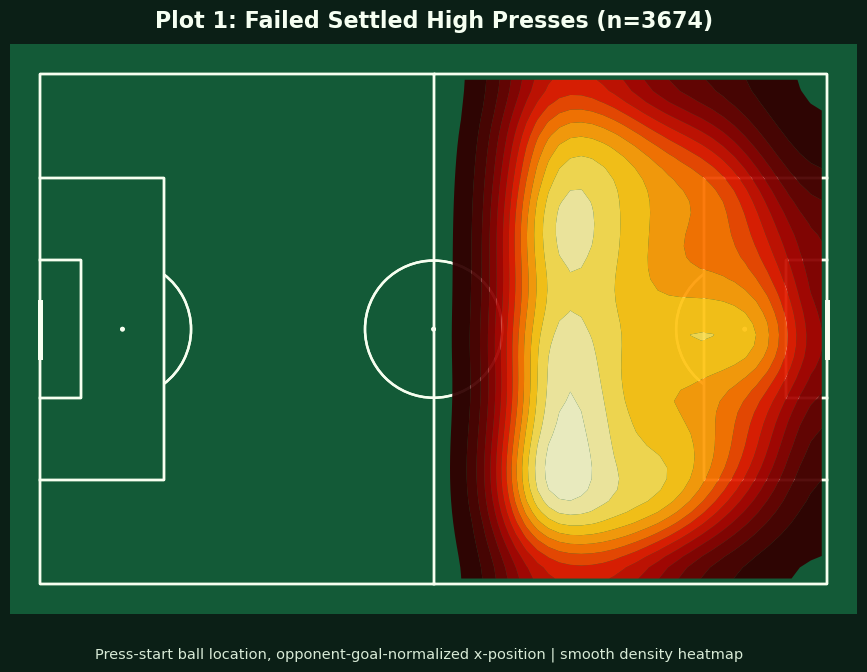

,plot,outcome,episodes,raw_count_total,output_path
0,Plot 1,Failures,3674,3674,/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SE...


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1: SMOOTH HEATMAP OF FAILED SETTLED HIGH PRESSES
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11.5, 7.4))
fig.patch.set_facecolor("#0b1f16")
ax.set_facecolor("#135a37")

pitch.draw(ax=ax)
heat = ax.contourf(
    failure_grid_x,
    failure_grid_y,
    failure_density,
    levels=failure_contour_levels,
    cmap=football_heat_cmap,
    alpha=0.94,
    antialiased=True,
    extend="max",
)
pitch.draw(ax=ax)

ax.set_title(
    f"Plot 1: Failed Settled High Presses (n={len(failure_heatmap_df)})",
    fontsize=16,
    fontweight="bold",
    color="#f6fff2",
    pad=12,
)
fig.text(
    0.5,
    0.055,
    f"Press-start ball location, {x_axis_note} | smooth density heatmap",
    ha="center",
    va="center",
    fontsize=10.5,
    color="#d8ead6",
)

fig.savefig(PRESS_FAILURE_HEATMAP_PATH, dpi=240, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

pd.DataFrame(
    [
        {
            "plot": "Plot 1",
            "outcome": "Failures",
            "episodes": len(failure_heatmap_df),
            "raw_count_total": int(np.nansum(failure_raw_counts)),
            "output_path": str(PRESS_FAILURE_HEATMAP_PATH),
        }
    ]
)

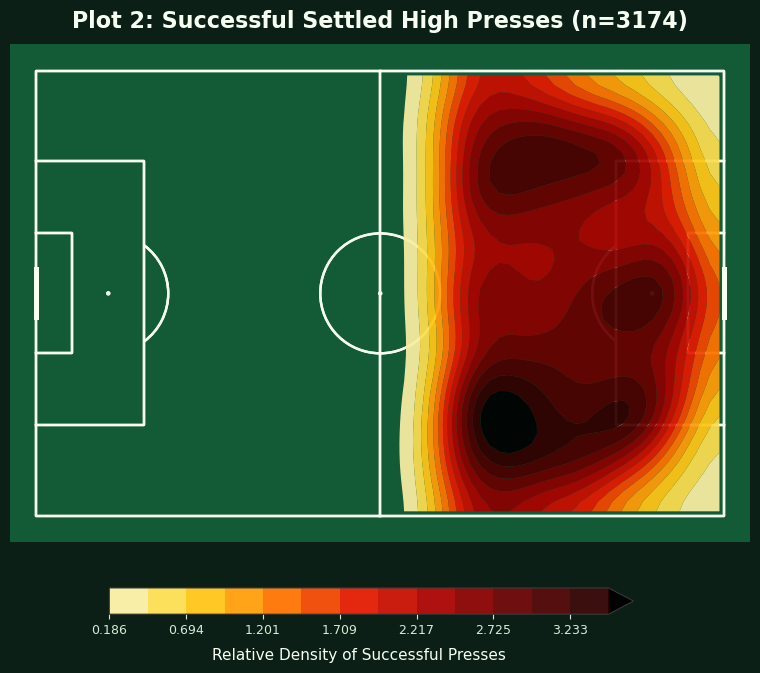

,plot,outcome,episodes,raw_count_total,output_path
0,Plot 2,Successes,3174,3174,/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SE...


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2: SMOOTH HEATMAP OF SUCCESSFUL SETTLED HIGH PRESSES
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11.5, 7.4))
fig.patch.set_facecolor("#0b1f16")
ax.set_facecolor("#135a37")

pitch.draw(ax=ax)
heat = ax.contourf(
    success_grid_x,
    success_grid_y,
    success_density,
    levels=success_contour_levels,
    cmap=football_heat_cmap.reversed(),
    alpha=0.94,
    antialiased=True,
    extend="max",
)
pitch.draw(ax=ax)

ax.set_title(
    f"Plot 2: Successful Settled High Presses (n={len(success_heatmap_df)})",
    fontsize=16,
    fontweight="bold",
    color="#f6fff2",
    pad=12,
)

# Add a horizontal colorbar below the plot
cbar = fig.colorbar(heat, ax=ax, orientation="horizontal", fraction=0.046, pad=0.08)
cbar.set_label("Relative Density of Successful Presses", color="#f6fff2", labelpad=8, fontsize=11)

# Adjust the color of the ticks and outline to match your dark theme
cbar.ax.tick_params(colors="#d8ead6", labelsize=9)
cbar.outline.set_edgecolor("#3b3b3b")

fig.savefig(PRESS_SUCCESS_HEATMAP_PATH, dpi=240, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

pd.DataFrame(
    [
        {
            "plot": "Plot 2",
            "outcome": "Successes",
            "episodes": len(success_heatmap_df),
            "raw_count_total": int(np.nansum(success_raw_counts)),
            "output_path": str(PRESS_SUCCESS_HEATMAP_PATH),
        }
    ]
)

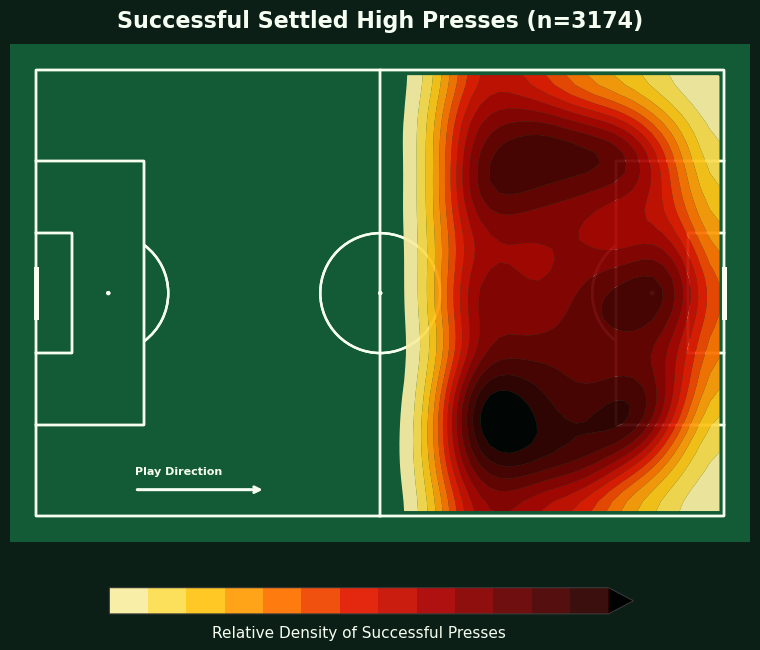

,plot,outcome,episodes,raw_count_total,output_path
0,Plot 2,Successes,3174,3174,/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SE...


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2: SMOOTH HEATMAP OF SUCCESSFUL SETTLED HIGH PRESSES
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11.5, 7.4))
fig.patch.set_facecolor("#0b1f16")
ax.set_facecolor("#135a37")

pitch.draw(ax=ax)

heat = ax.contourf(
    success_grid_x,
    success_grid_y,
    success_density,
    levels=success_contour_levels,
    cmap=football_heat_cmap.reversed(),
    alpha=0.94,
    antialiased=True,
    extend="max",
)

pitch.draw(ax=ax)

# ─────────────────────────────────────────────────────────────────────────────
# PLAY DIRECTION ARROW (LEFT → RIGHT)
# ─────────────────────────────────────────────────────────────────────────────
# Smaller arrow on left side of pitch
ax.annotate(
    "",
    xy=(35, 4),          # arrow head
    xytext=(15, 4),      # arrow start
    arrowprops=dict(
        arrowstyle="->",
        lw=2.2,
        color="#f6fff2",
    ),
)

ax.text(
    15,
    6,
    "Play Direction",
    ha="left",
    va="bottom",
    fontsize=8,
    color="#f6fff2",
    fontweight="bold",
)

# ─────────────────────────────────────────────────────────────────────────────
# TITLE
# ─────────────────────────────────────────────────────────────────────────────
ax.set_title(
    f"Successful Settled High Presses (n={len(success_heatmap_df)})",
    fontsize=16,
    fontweight="bold",
    color="#f6fff2",
    pad=12,
)

# ─────────────────────────────────────────────────────────────────────────────
# HORIZONTAL COLORBAR
# ─────────────────────────────────────────────────────────────────────────────
cbar = fig.colorbar(
    heat,
    ax=ax,
    orientation="horizontal",
    fraction=0.046,
    pad=0.08,
)

cbar.set_label(
    "Relative Density of Successful Presses",
    color="#f6fff2",
    labelpad=8,
    fontsize=11,
)

# Remove numbers/ticks from colorbar
cbar.set_ticks([])

# Match dark theme
cbar.outline.set_edgecolor("#3b3b3b")

fig.savefig(
    PRESS_SUCCESS_HEATMAP_PATH,
    dpi=240,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

pd.DataFrame(
    [
        {
            "plot": "Plot 2",
            "outcome": "Successes",
            "episodes": len(success_heatmap_df),
            "raw_count_total": int(np.nansum(success_raw_counts)),
            "output_path": str(PRESS_SUCCESS_HEATMAP_PATH),
        }
    ]
)

# Methods and Materials

### 1. Data Sources and Synchronization
The foundation of this study relies on a comprehensive dataset encompassing 193 matches from the Danish Superliga 2024-2025 season. One match was excluded from the final sample due to missing or corrupted tracking files, resulting in 192 fully processed matches. 

The raw data amalgamates two distinct but synchronous streams:
* **Event Data (Opta Sports):** We utilize three core data feeds. The *Match Results (SRML/F7)* feed provides match metadata, starting lineups, and macro-events (goals, cards, substitutions). The *Event Details (F24)* feed captures granular, on-ball actions across 1,963 events per match. Finally, the *Possessions (F73)* feed maps temporal possession sequences and pass chains with over 27,000 sub-events per match. 
* **Tracking Data (Second Spectrum):** Captured at 25 frames per second (fps), the tracking data contains absolute spatial coordinates ($x, y$) over an average of 154,000 frames per match, capturing the position of all 22 players and the ball, alongside positional derivatives such as velocity and distance traveled.

To unify the isolated feeds, the Opta event timestamps were translated into absolute seconds within the match period (`gameClock`), allowing exact synchronization with the Second Spectrum tracking frames. Pitch geometries across both feeds were normalized to absolute dimensions ($104.8 \times 67.96$ meters).

### 2. Pressing Episode Detection and Filtering
Rather than treating a match as a continuous sequence of 25 fps frames, we discretize the game into "pressing episodes." Using positional algorithms, we identify frames where the defensive team exerts coordinated physical pressure on the ball carrier, governed by proximity, closing speed, and attack angle. Consecutive frames where the ball remains live (`live: true` in tracking metadata) are grouped into runs, and simultaneous multi-player runs are aggregated into unified pressing episodes.

To isolate the specific tactical phenomenon of structured defensive work, strict filtering was applied. We excluded *counterpressing* (regaining the ball within 5 seconds of losing it) to eliminate chaotic transition states. The dataset was then constrained to *settled* defensive shapes and explicitly filtered for *high-press* scenarios (actions initiated in the attacking or upper-middle thirds). Following this filtering process, the final sample yielded exactly **6,851 settled high-press episodes**.

### 3. Target Variable
The dependent variable is a binary classification target, defined as `press_success_any`. An episode is labeled as a successful press (1) if it forces a turnover resulting in *sustained possession* for the pressing team or directly leads to a *chance created*. It is labeled as a failed press (0) if the team in possession successfully resolves the pressure—either by completing a progressive pass out of the pressing zone or retaining stable possession.

### 4. Feature Engineering Formulation
Feature extraction was executed in two distinct computational stages. 

**Stage 1: Spatial and Dynamic Derivation**
The initial ingestion and parsing pipeline were executed using the `kloppy` library (as documented in the `MASTER_THESIS_KLOPPY_COLAB.ipynb` pipeline). This phase calculates absolute distances between players, identifies the nearest pressers, calculates convex hulls, and computes raw tactical geometry frame-by-frame. 

**Stage 2: Advanced Window Aggregation**
Because pressing is a temporal event, point-in-time snapshots are insufficient. To construct the final predictive dataset, dynamic metrics were aggregated over specific temporal windows leading up to, and directly following, the initiation of the press (the "early-window"). This generated exactly **474 predictive features** encompassing the following core tactical families:
* **Pressing & Trap Intensity:** Metrics approximating the aggregate physical exertion and spatial restriction imposed on the ball carrier.
* **Compact Pressure & Surface Area:** Calculations of the defending team's convex hull, stretch indices, and team length/width.
* **Player-Level Dynamics:** `dist_nearest_1` to `dist_nearest_3` (distances of the closest pressers), alongside their respective closing speeds.
* **Spatial Context:** Absolute ball coordinates ($x, y$) and boolean checks for proximity to the sideline vs. the central pitch axis.

### 5. Experimental Design and Modeling
To prevent data leakage caused by the chronological and physical continuity of football matches, cross-validation and train/test splits were strictly **grouped by match** (`match_name`). This ensures that temporally adjacent episodes from the same match do not leak from the training set into the test set.

The modeling approach utilizes three tree-based, non-linear machine learning architectures capable of handling complex spatial interactions without strict scaling prerequisites:
1. **Random Forest (RF)**
2. **XGBoost**
3. **LightGBM**

Additionally, a deterministic baseline model was constructed. Inspired by existing tactical frameworks in academic sports literature, we formulated an ablation **"press-intensity threshold model,"** operating under the premise that a successful press can be predicted purely by the density and speed of the defenders closing down the ball carrier.

### 6. Evaluation and Interpretability
Due to the highly imbalanced nature of the target variable (successful high presses represent a minority class), accuracy is an insufficient metric. Model evaluation relies heavily on the **Precision-Recall Area Under Curve (PR-AUC)**, alongside **ROC-AUC**, **F1-score**, and the **Brier Score** for probabilistic calibration. Confusion matrices are utilized to evaluate the trade-off between false positives and false negatives based on customized probability thresholds.

Finally, to bridge the gap between black-box predictions and tactical theory, model interpretability is derived using both global **Permutation Importance** and local **Tree SHAP** (SHapley Additive exPlanations) values. This methodological choice ensures that every prediction can be attributed to specific tactical configurations recognizable to physical behaviors on the pitch.